# 2110742 Evolutionary Computation
## Final Project: Simplified 2D UAV Path Planning

This notebook studies simplified constrained UAV path planning in a 2D environment with circular obstacles. The comparison is intentionally narrow: a weighted-sum genetic algorithm (GA) and NSGA-II are evaluated under the same representation, budget, and seed protocol, and then re-evaluated with the same obstacle-aware repair operator.

The optimization evaluator is batched so it can use **CUDA on an NVIDIA T4** when available and otherwise fall back to **CPU** execution.

### Research questions
1. Under a common baseline protocol, how do weighted-sum GA and NSGA-II differ in feasible robustness, selected-path quality, and retained trade-offs?
2. When a shared geometric repair operator is added to both methods, how do the direct single-solution and retained-representative comparisons change?
3. Which conclusions remain justified once the fixed-budget setting and the later exploratory checks are interpreted cautiously?

### Notebook roadmap
1. Define the geometry, path representation, objectives, and constraints.
2. Separate tuning seeds from evaluation seeds.
3. Run a fair **baseline comparison**:
   - GA baseline
   - NSGA-II baseline
4. Run a fair **enhanced comparison**:
   - GA + repair
   - NSGA-II + repair
5. Summarize the benchmark results through two complementary views:
   - a direct **single-solution** view: GA incumbent versus NSGA-II compromise candidate
   - a **retained-representative** view: what the final feasible set preserves for shortest, safest, and compromise-style choices
6. Use exploratory analyses only as supporting evidence, not as the primary basis for the final conclusions.

External cache files for this notebook are stored under `uav/cache/uav_path_planning_gpu/`.


In [1]:
import importlib.util
import subprocess
import sys

NOTEBOOK_CACHE_OPTIONS = {
    "enabled": True,
    "refresh": False,
    "write_back": True,
    "relative_dir": "uav/cache/uav_path_planning_gpu",
}
RUNTIME_OPTIONS = {
    "prefer_gpu": True,
    "prefer_torch_cpu": False,
    "float_dtype": "float64",
}

REQUIRED_PACKAGES = ["numpy", "pandas", "matplotlib", "pymoo", "scipy", "nbformat", "nbclient"]
OPTIONAL_GPU_PACKAGES = ["torch"]

missing_required = [pkg for pkg in REQUIRED_PACKAGES if importlib.util.find_spec(pkg) is None]
missing_optional = [pkg for pkg in OPTIONAL_GPU_PACKAGES if importlib.util.find_spec(pkg) is None]
is_colab = "google.colab" in sys.modules

if is_colab:
    to_install = [*missing_required, *missing_optional]
    if to_install:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *to_install])
elif missing_required:
    print(f"Missing required packages: {missing_required}. Install them before running the notebook.")

if missing_optional and not is_colab:
    print(f"Optional GPU packages unavailable locally: {missing_optional}. The notebook will use CPU fallback.")
elif not missing_optional:
    print("Optional torch backend detected.")

print()
print("Notebook bootstrap complete.")
print(f"External cache enabled: {NOTEBOOK_CACHE_OPTIONS['enabled']}")
print(f"Force cache refresh: {NOTEBOOK_CACHE_OPTIONS['refresh']}")
print(f"Preferred accelerator: {'GPU' if RUNTIME_OPTIONS['prefer_gpu'] else 'CPU'}")
print(f"Preferred numeric dtype: {RUNTIME_OPTIONS['float_dtype']}")


Optional torch backend detected.

Notebook bootstrap complete.
External cache enabled: True
Force cache refresh: False
Preferred accelerator: GPU
Preferred numeric dtype: float64


## 1. Problem definition

The task is a simplified 2D UAV path-planning problem on a square map with circular obstacles. A candidate solution is a polyline that connects a fixed start point to a fixed goal point through a fixed number of optimized intermediate waypoints.

The problem is intentionally simplified:
- motion is planar
- obstacles are static circles
- the path is piecewise linear
- there are no vehicle dynamics, wind, sensing, or time-varying constraints

This simplification is deliberate. It keeps the geometry exact and computationally lightweight while still supporting meaningful constrained optimization experiments.


## 2. Research question

The notebook focuses on two main questions.

1. Under a fair shared protocol, how does a weighted-sum **GA** compare with **NSGA-II** on simplified constrained UAV path planning?
2. If the same obstacle-aware repair operator is added to both methods, how does that shared enhancement change feasible robustness and retained path quality?

Those questions are answered through two distinct comparison views: a direct **single-solution** view and a **retained-representative** view. The notebook does **not** try to claim a universal winner. The goal is to identify the trade-offs that appear in this simplified setting under a protocol that is easy to explain and defend.


### Reading guide

The main evidence in this notebook is organized around two comparison sections:

- **Baseline comparison results**: a common-budget comparison between weighted-sum GA and NSGA-II without repair
- **Enhanced comparison results**: the same comparison after adding the same obstacle-aware repair operator to both methods

Within each section, the evidence is read through two complementary views:

- a direct **single-solution** view: GA incumbent versus NSGA-II compromise candidate
- a **retained-representative** view: what the final feasible set preserves for shortest, safest, and compromise-style choices

Later sections on fixed-budget sensitivity, waypoint-count sensitivity, and the corridor-signature heuristic are included only as supporting context. The final conclusions should still be based primarily on the benchmark summaries from the baseline and enhanced comparisons.


## 3. Environment and path representation

The workspace is the square domain
$$
\Omega = [0, L]^2,
$$
where $L$ is the map size. The start and goal are fixed points $s, g \in \Omega$.

Each obstacle is a closed disk
$$
O_j = \{x \in \mathbb{R}^2 : \|x - c_j\|_2 \le r_j\},
$$
where $c_j$ is the obstacle center and $r_j$ is the obstacle radius.

A candidate path is encoded as
$$
P = (p_0, p_1, \ldots, p_K, p_{K+1}),
$$
where $p_0 = s$, $p_{K+1} = g$, and the $K$ interior waypoints are optimized by the evolutionary algorithms.

The experiments below fix $K = 8$ interior waypoints. Circular obstacles are kept on purpose because they allow exact distance and segment-intersection calculations, which makes the evaluator more trustworthy than sampled collision checks.


In [2]:
from __future__ import annotations

from dataclasses import asdict, dataclass, is_dataclass, replace
import hashlib
import json
import math
import pickle
from pathlib import Path
from typing import Any, Callable, Mapping, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.core.problem import ElementwiseProblem
from pymoo.core.repair import Repair
from pymoo.core.sampling import Sampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from scipy.stats import rankdata, wilcoxon

Point = Tuple[float, float]
CACHE_SCHEMA_VERSION = "uav-path-planning-cache-v3"


In [3]:
@dataclass(frozen=True)
class CircleObstacle:
    cx: float
    cy: float
    radius: float

    def __post_init__(self):
        if self.radius <= 0.0:
            raise ValueError("Obstacle radius must be positive.")

    @property
    def center(self) -> Point:
        return (self.cx, self.cy)

    def signed_distance_to_point(self, point: Point) -> float:
        return math.hypot(point[0] - self.cx, point[1] - self.cy) - self.radius

    def contains_point(self, point: Point, tol: float = 0.0) -> bool:
        return self.signed_distance_to_point(point) <= tol

    def clearance_to_segment(self, p1: Point, p2: Point) -> float:
        return segment_point_distance(p1, p2, self.center) - self.radius

    def intersects_segment(self, p1: Point, p2: Point, tol: float = 1e-9) -> bool:
        return self.clearance_to_segment(p1, p2) <= tol


@dataclass(frozen=True)
class MapConfig:
    size: float = 100.0
    start: Point = (5.0, 5.0)
    goal: Point = (95.0, 95.0)
    n_waypoints: int = 8
    danger_margin: float = 5.0
    required_clearance: float = 1.5
    obstacles: Tuple[CircleObstacle, ...] = (
        CircleObstacle(30, 30, 10),
        CircleObstacle(60, 20, 8),
        CircleObstacle(50, 50, 12),
        CircleObstacle(20, 70, 9),
        CircleObstacle(75, 60, 10),
        CircleObstacle(40, 85, 7),
        CircleObstacle(85, 35, 8),
        CircleObstacle(65, 80, 6),
        CircleObstacle(15, 45, 6),
        CircleObstacle(55, 10, 5),
        CircleObstacle(80, 80, 7),
        CircleObstacle(35, 60, 8),
    )


@dataclass(frozen=True)
class BenchmarkMapSpec:
    description: str
    obstacles: Tuple[CircleObstacle, ...]


@dataclass(frozen=True)
class CommonProtocol:
    pop_size: int = 80
    n_gen: int = 80
    crossover_prob: float = 0.9
    crossover_eta: float = 15.0
    mutation_eta: float = 20.0
    mutation_prob_factor: float = 1.0

    def mutation_prob(self, map_config: MapConfig) -> float:
        return float(self.mutation_prob_factor) / (2 * map_config.n_waypoints)


@dataclass(frozen=True)
class RepairPolicy:
    label: str
    application: str = "none"
    repair_kind: str = "none"

    def __post_init__(self):
        valid_applications = {"none", "init", "offspring"}
        valid_kinds = {"none", "waypoint", "segment"}
        if self.application not in valid_applications:
            raise ValueError(f"Unknown repair application: {self.application}")
        if self.repair_kind not in valid_kinds:
            raise ValueError(f"Unknown repair kind: {self.repair_kind}")
        if self.application == "none" and self.repair_kind != "none":
            raise ValueError("No-repair policies must use repair_kind='none'.")
        if self.application != "none" and self.repair_kind == "none":
            raise ValueError("Active repair policies must declare a concrete repair_kind.")

    @classmethod
    def none(cls, label: str = "No repair") -> "RepairPolicy":
        return cls(label=label, application="none", repair_kind="none")

    @classmethod
    def offspring(cls, repair_kind: str, label: str | None = None) -> "RepairPolicy":
        return cls(label=label or f"{repair_kind.title()} repair", application="offspring", repair_kind=repair_kind)


@dataclass(frozen=True)
class ConditionProfile:
    name: str
    comparison: str
    algorithm: str
    protocol: CommonProtocol
    repair_policy: RepairPolicy
    weights: Tuple[float, float] | None = None

    def resolved_protocol_view(self, map_config: MapConfig) -> dict[str, Any]:
        return {
            "condition": self.name,
            "comparison": self.comparison,
            "algorithm": self.algorithm,
            "repair": self.repair_policy.label,
            "pop_size": int(self.protocol.pop_size),
            "n_gen": int(self.protocol.n_gen),
            "function_evaluations": int(self.protocol.pop_size) * int(self.protocol.n_gen),
            "weights": np.nan if self.weights is None else tuple(float(w) for w in self.weights),
            "crossover_prob": float(self.protocol.crossover_prob),
            "crossover_eta": float(self.protocol.crossover_eta),
            "mutation_eta": float(self.protocol.mutation_eta),
            "mutation_prob": float(self.protocol.mutation_prob(map_config)),
            "repair_application": self.repair_policy.application,
            "repair_kind": self.repair_policy.repair_kind,
        }

    def run(self, map_config: MapConfig, seed: int):
        if self.algorithm == "GA":
            if self.weights is None:
                raise ValueError("GA profiles require explicit weights.")
            return run_ga(
                map_config,
                seed=seed,
                weights=self.weights,
                protocol=self.protocol,
                repair_policy=self.repair_policy,
            )
        if self.algorithm == "NSGA-II":
            return run_nsga2(
                map_config,
                seed=seed,
                protocol=self.protocol,
                repair_policy=self.repair_policy,
            )
        raise ValueError(f"Unknown algorithm: {self.algorithm}")


@dataclass(frozen=True)
class ExperimentConfig:
    development_map: MapConfig
    benchmark_maps: Mapping[str, BenchmarkMapSpec]
    tuning_seeds: Tuple[int, ...]
    evaluation_seeds: Tuple[int, ...]
    ga_weight_grid: Tuple[float, ...]
    common_protocol: CommonProtocol
    baseline_repair: RepairPolicy
    enhanced_repair: RepairPolicy
    compromise_rule: str
    route_checkpoints: Tuple[float, ...]
    ga_weight_selection_rule: str
    gallery_seed_rule: str


@dataclass(frozen=True)
class CachePolicy:
    enabled: bool = True
    refresh: bool = False
    write_back: bool = True
    relative_dir: str = "uav/cache/uav_path_planning"

    def cache_dir(self, repo_root: Path) -> Path:
        return repo_root / self.relative_dir


@dataclass(frozen=True)
class ResolvedExperimentProfile:
    selected_ga_weight: float
    ga_weight_source: str
    condition_profiles: Mapping[str, ConditionProfile]
    tuning_fingerprint: str
    benchmark_fingerprint: str


def point_inside_any_obstacle(point: Point, obstacles: Sequence[CircleObstacle]) -> bool:
    return any(obs.contains_point(point) for obs in obstacles)


def default_benchmark_map_specs() -> dict[str, BenchmarkMapSpec]:
    return {
        "Three corridors": BenchmarkMapSpec(
            description="Separated low, middle, and high corridor options.",
            obstacles=(
                CircleObstacle(22, 22, 8),
                CircleObstacle(24, 52, 10),
                CircleObstacle(22, 80, 8),
                CircleObstacle(45, 35, 10),
                CircleObstacle(48, 65, 10),
                CircleObstacle(68, 22, 8),
                CircleObstacle(70, 50, 11),
                CircleObstacle(68, 80, 8),
                CircleObstacle(84, 35, 8),
                CircleObstacle(84, 68, 8),
            ),
        ),
        "Deceptive funnel": BenchmarkMapSpec(
            description="A central funnel that looks attractive early and constricts late.",
            obstacles=(
                CircleObstacle(22, 18, 7),
                CircleObstacle(33, 30, 8),
                CircleObstacle(44, 42, 8),
                CircleObstacle(57, 56, 8),
                CircleObstacle(70, 69, 7),
                CircleObstacle(58, 37, 6),
                CircleObstacle(71, 51, 6),
                CircleObstacle(37, 58, 6),
                CircleObstacle(78, 82, 6),
            ),
        ),
        "Goal wall split": BenchmarkMapSpec(
            description="A late barrier near the goal creates a delayed route split.",
            obstacles=(
                CircleObstacle(24, 24, 8),
                CircleObstacle(36, 46, 8),
                CircleObstacle(48, 24, 8),
                CircleObstacle(50, 74, 8),
                CircleObstacle(68, 50, 10),
                CircleObstacle(80, 22, 8),
                CircleObstacle(80, 78, 8),
                CircleObstacle(88, 50, 6),
            ),
        ),
        "Offset slalom": BenchmarkMapSpec(
            description="Alternating gaps with offset centerlines and no single obvious lane.",
            obstacles=(
                CircleObstacle(18, 18, 7),
                CircleObstacle(18, 52, 7),
                CircleObstacle(18, 84, 6),
                CircleObstacle(40, 30, 8),
                CircleObstacle(40, 68, 8),
                CircleObstacle(62, 16, 7),
                CircleObstacle(62, 50, 7),
                CircleObstacle(62, 82, 7),
                CircleObstacle(84, 34, 8),
                CircleObstacle(84, 70, 7),
            ),
        ),
    }


EXPERIMENT_CONFIG = ExperimentConfig(
    development_map=MapConfig(),
    benchmark_maps=default_benchmark_map_specs(),
    tuning_seeds=tuple(range(6)),
    evaluation_seeds=tuple(range(100, 120)),
    ga_weight_grid=(80.0, 120.0, 160.0),
    common_protocol=CommonProtocol(),
    baseline_repair=RepairPolicy.none(),
    enhanced_repair=RepairPolicy.offspring("segment", label="SegmentAwareRepair"),
    compromise_rule="Feasible point closest to the normalized ideal point",
    route_checkpoints=(20.0, 40.0, 60.0, 80.0),
    ga_weight_selection_rule=(
        "Sort by feasible_run_rate desc, median_shortest_feasible_length asc, "
        "median_safest_clearance desc, w_risk asc"
    ),
    gallery_seed_rule=(
        "Within each condition choose the feasible run nearest the condition median shortest-feasible length; "
        "break ties by feasible_count desc, safest_feasible_min_clearance desc, seed asc"
    ),
)
CACHE_POLICY = CachePolicy(**NOTEBOOK_CACHE_OPTIONS)
config = EXPERIMENT_CONFIG.development_map

assert 0.0 < config.required_clearance < config.danger_margin
assert not point_inside_any_obstacle(config.start, config.obstacles)
assert not point_inside_any_obstacle(config.goal, config.obstacles)
assert set(EXPERIMENT_CONFIG.tuning_seeds).isdisjoint(EXPERIMENT_CONFIG.evaluation_seeds)
assert all(weight > 0.0 for weight in EXPERIMENT_CONFIG.ga_weight_grid)
assert len(set(EXPERIMENT_CONFIG.ga_weight_grid)) == len(EXPERIMENT_CONFIG.ga_weight_grid)
config


MapConfig(size=100.0, start=(5.0, 5.0), goal=(95.0, 95.0), n_waypoints=8, danger_margin=5.0, required_clearance=1.5, obstacles=(CircleObstacle(cx=30, cy=30, radius=10), CircleObstacle(cx=60, cy=20, radius=8), CircleObstacle(cx=50, cy=50, radius=12), CircleObstacle(cx=20, cy=70, radius=9), CircleObstacle(cx=75, cy=60, radius=10), CircleObstacle(cx=40, cy=85, radius=7), CircleObstacle(cx=85, cy=35, radius=8), CircleObstacle(cx=65, cy=80, radius=6), CircleObstacle(cx=15, cy=45, radius=6), CircleObstacle(cx=55, cy=10, radius=5), CircleObstacle(cx=80, cy=80, radius=7), CircleObstacle(cx=35, cy=60, radius=8)))

In [4]:
try:
    import torch
except ImportError:
    torch = None

from dataclasses import dataclass
from pymoo.core.problem import Problem


@dataclass(frozen=True)
class RuntimeConfig:
    prefer_gpu: bool = True
    prefer_torch_cpu: bool = False
    float_dtype: str = "float64"

    def __post_init__(self):
        if self.float_dtype not in {"float32", "float64"}:
            raise ValueError("Runtime float_dtype must be 'float32' or 'float64'.")


@dataclass(frozen=True)
class RuntimeContext:
    backend: str
    accelerator: str
    torch_available: bool
    torch_device: str | None
    float_dtype: str

    @property
    def label(self) -> str:
        return f"{self.backend}-{self.accelerator}"


def resolve_runtime_context(runtime_config: RuntimeConfig) -> RuntimeContext:
    torch_available = torch is not None
    if runtime_config.prefer_gpu and torch_available and torch.cuda.is_available():
        return RuntimeContext("torch", "cuda", True, "cuda", runtime_config.float_dtype)
    if runtime_config.prefer_torch_cpu and torch_available:
        return RuntimeContext("torch", "cpu", True, "cpu", runtime_config.float_dtype)
    return RuntimeContext("numpy", "cpu", torch_available, None, runtime_config.float_dtype)


def torch_dtype_from_name(dtype_name: str):
    if torch is None:
        raise ImportError("torch is not available.")
    try:
        return getattr(torch, dtype_name)
    except AttributeError as exc:
        raise ValueError(f"Unsupported torch dtype: {dtype_name}") from exc


RUNTIME_CONFIG = RuntimeConfig(**RUNTIME_OPTIONS)
RUNTIME_CONTEXT = resolve_runtime_context(RUNTIME_CONFIG)


## 4. Objectives and constraints

For the polyline path $P$, let segment $i$ be $e_i = (p_i, p_{i+1})$, and let $c_i$ denote the signed clearance from segment $e_i$ to the nearest obstacle boundary.

The path-length objective is
$$
L(P) = \sum_{i=0}^{K} \|p_{i+1} - p_i\|_2.
$$

The soft danger penalty uses the danger margin $d_{\mathrm{margin}}$:
$$
\phi(c_i) = \max\left(0, \frac{d_{\mathrm{margin}} - c_i}{d_{\mathrm{margin}}}\right)^2,
$$
and the path-level penalty is
$$
R(P) = \frac{1}{K + 1}\sum_{i=0}^{K}\phi(c_i) + \max_{0 \le i \le K}\phi(c_i).
$$

The feasibility constraints are made more informative than a simple collision count:

- collision violation
  $$
  v_{\mathrm{coll}}(P) = \sum_{i=0}^{K} \max(0, -c_i)
  $$
- clearance violation relative to the required clearance $c_{\mathrm{req}}$
  $$
  v_{\mathrm{clr}}(P) = \sum_{i=0}^{K} \max(0, c_{\mathrm{req}} - c_i)
  $$
- out-of-bounds violation for the interior waypoints
  $$
  v_{\mathrm{box}}(P) = \sum_{k=1}^{K}\left[\max(0, -x_k) + \max(0, x_k - L) + \max(0, -y_k) + \max(0, y_k - L)\right]
  $$

A path is treated as feasible only if all three violations are zero. The box constraint is already enforced directly by the decision-variable bounds, but it is included as an explicit audit quantity in the evaluator.

The optimization formulations are:

- **GA**: minimize the scalarized objective $F_{\mathrm{GA}}(P) = w_L L(P) + w_R R(P)$
- **NSGA-II**: minimize the objective vector $(L(P), R(P))$


In [5]:
@dataclass(frozen=True)
class PathMetrics:
    length: float
    danger_penalty: float
    min_clearance: float
    collision_segments: int
    collision_violation: float
    clearance_violation: float
    out_of_bounds_violation: float
    in_bounds: bool
    geometric_feasible: bool
    clearance_feasible: bool
    feasible: bool
    segment_clearances: Tuple[float, ...]
    segment_penalties: Tuple[float, ...]
    segment_clearance_shortfalls: Tuple[float, ...]
    segment_penetrations: Tuple[float, ...]

    def to_record(self) -> dict:
        return {
            "length": self.length,
            "danger_penalty": self.danger_penalty,
            "min_clearance": self.min_clearance,
            "collision_segments": self.collision_segments,
            "collision_violation": self.collision_violation,
            "clearance_violation": self.clearance_violation,
            "out_of_bounds_violation": self.out_of_bounds_violation,
            "in_bounds": self.in_bounds,
            "geometric_feasible": self.geometric_feasible,
            "clearance_feasible": self.clearance_feasible,
            "feasible": self.feasible,
        }


def point_to_obstacle_surface_distance(x: float, y: float, obstacle: CircleObstacle) -> float:
    return obstacle.signed_distance_to_point((x, y))


def closest_point_on_segment(p1: Point, p2: Point, point: Point) -> tuple[Point, float]:
    x1, y1 = p1
    x2, y2 = p2
    px, py = point
    dx = x2 - x1
    dy = y2 - y1
    seg_len_sq = dx * dx + dy * dy
    if seg_len_sq < 1e-12:
        return (x1, y1), 0.0

    t = ((px - x1) * dx + (py - y1) * dy) / seg_len_sq
    t = min(1.0, max(0.0, t))
    closest_x = x1 + t * dx
    closest_y = y1 + t * dy
    return (closest_x, closest_y), float(t)


def segment_point_distance(p1: Point, p2: Point, point: Point) -> float:
    closest_point, _ = closest_point_on_segment(p1, p2, point)
    return math.hypot(point[0] - closest_point[0], point[1] - closest_point[1])


def segment_clearance_to_obstacle(p1: Point, p2: Point, obstacle: CircleObstacle) -> float:
    return obstacle.clearance_to_segment(p1, p2)


def segment_intersects_circle(p1: Point, p2: Point, obstacle: CircleObstacle, tol: float = 1e-9) -> bool:
    return obstacle.intersects_segment(p1, p2, tol=tol)


def segment_min_clearance(p1: Point, p2: Point, obstacles: Sequence[CircleObstacle]) -> float:
    return min(obs.clearance_to_segment(p1, p2) for obs in obstacles)


def segment_danger_penalty_from_clearance(clearance: float, danger_margin: float) -> float:
    if clearance >= danger_margin:
        return 0.0
    gap = (danger_margin - clearance) / danger_margin
    return gap ** 2


def decode_solution(x: np.ndarray, config: MapConfig) -> List[Point]:
    pts = [config.start]
    for i in range(config.n_waypoints):
        pts.append((float(x[2 * i]), float(x[2 * i + 1])))
    pts.append(config.goal)
    return pts


def path_segments(path: Sequence[Point]) -> List[Tuple[Point, Point]]:
    return list(zip(path[:-1], path[1:]))


def path_length(path: Sequence[Point]) -> float:
    return sum(math.hypot(path[i + 1][0] - path[i][0], path[i + 1][1] - path[i][1]) for i in range(len(path) - 1))


def point_out_of_bounds_violation(point: Point, size: float) -> float:
    x, y = point
    return max(0.0, -x) + max(0.0, x - size) + max(0.0, -y) + max(0.0, y - size)


def path_out_of_bounds_violation(path: Sequence[Point], size: float) -> float:
    return float(sum(point_out_of_bounds_violation(point, size) for point in path[1:-1]))


def evaluate_path(path: Sequence[Point], config: MapConfig) -> PathMetrics:
    segments = path_segments(path)
    segment_clearances = tuple(segment_min_clearance(p1, p2, config.obstacles) for p1, p2 in segments)
    segment_penalties = tuple(segment_danger_penalty_from_clearance(clearance, config.danger_margin) for clearance in segment_clearances)
    segment_penetrations = tuple(max(0.0, -clearance) for clearance in segment_clearances)
    segment_clearance_shortfalls = tuple(max(0.0, config.required_clearance - clearance) for clearance in segment_clearances)

    min_clearance = min(segment_clearances)
    collision_segments = int(sum(clearance <= 0.0 for clearance in segment_clearances))
    collision_violation = float(sum(segment_penetrations))
    clearance_violation = float(sum(segment_clearance_shortfalls))
    out_of_bounds_violation = path_out_of_bounds_violation(path, config.size)

    in_bounds = out_of_bounds_violation <= 1e-9
    geometric_feasible = collision_violation <= 1e-9 and in_bounds
    clearance_feasible = clearance_violation <= 1e-9
    feasible = geometric_feasible and clearance_feasible

    danger_penalty = float(np.mean(segment_penalties) + max(segment_penalties))
    return PathMetrics(
        path_length(path),
        danger_penalty,
        min_clearance,
        collision_segments,
        collision_violation,
        clearance_violation,
        out_of_bounds_violation,
        in_bounds,
        geometric_feasible,
        clearance_feasible,
        feasible,
        segment_clearances,
        segment_penalties,
        segment_clearance_shortfalls,
        segment_penetrations,
    )


def evaluate_decision_vector(x: np.ndarray, config: MapConfig) -> PathMetrics:
    return evaluate_path(decode_solution(x, config), config)


In [6]:
@dataclass(frozen=True)
class BatchPathMetrics:
    length: np.ndarray
    danger_penalty: np.ndarray
    min_clearance: np.ndarray
    collision_segments: np.ndarray
    collision_violation: np.ndarray
    clearance_violation: np.ndarray
    out_of_bounds_violation: np.ndarray
    in_bounds: np.ndarray
    geometric_feasible: np.ndarray
    clearance_feasible: np.ndarray
    feasible: np.ndarray

    def to_record(self, idx: int) -> dict[str, Any]:
        return {
            "length": float(self.length[idx]),
            "danger_penalty": float(self.danger_penalty[idx]),
            "min_clearance": float(self.min_clearance[idx]),
            "collision_segments": int(self.collision_segments[idx]),
            "collision_violation": float(self.collision_violation[idx]),
            "clearance_violation": float(self.clearance_violation[idx]),
            "out_of_bounds_violation": float(self.out_of_bounds_violation[idx]),
            "in_bounds": bool(self.in_bounds[idx]),
            "geometric_feasible": bool(self.geometric_feasible[idx]),
            "clearance_feasible": bool(self.clearance_feasible[idx]),
            "feasible": bool(self.feasible[idx]),
        }


class NumpyVectorizedPathEvaluator:
    def __init__(self, config: MapConfig):
        self.config = config
        self.start = np.asarray(config.start, dtype=float).reshape(1, 1, 2)
        self.goal = np.asarray(config.goal, dtype=float).reshape(1, 1, 2)
        self.obstacle_centers = np.asarray([obs.center for obs in config.obstacles], dtype=float)
        self.obstacle_radii = np.asarray([obs.radius for obs in config.obstacles], dtype=float)

    def evaluate(self, X: np.ndarray) -> BatchPathMetrics:
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X[None, :]
        waypoints = X.reshape(X.shape[0], self.config.n_waypoints, 2)
        points = np.concatenate([
            np.broadcast_to(self.start, (X.shape[0], 1, 2)),
            waypoints,
            np.broadcast_to(self.goal, (X.shape[0], 1, 2)),
        ], axis=1)
        seg_start = points[:, :-1, :]
        seg_end = points[:, 1:, :]
        seg_vec = seg_end - seg_start
        seg_len_sq = np.sum(seg_vec * seg_vec, axis=2)
        safe_den = np.where(seg_len_sq > 1e-12, seg_len_sq, 1.0)
        centers = self.obstacle_centers[None, None, :, :]
        radii = self.obstacle_radii[None, None, :]
        delta = centers - seg_start[:, :, None, :]
        t = np.sum(delta * seg_vec[:, :, None, :], axis=3) / safe_den[:, :, None]
        t = np.where(seg_len_sq[:, :, None] > 1e-12, np.clip(t, 0.0, 1.0), 0.0)
        closest = seg_start[:, :, None, :] + t[..., None] * seg_vec[:, :, None, :]
        clearances = (np.linalg.norm(centers - closest, axis=3) - radii).min(axis=2)
        penalties = np.where(clearances >= self.config.danger_margin, 0.0, ((self.config.danger_margin - clearances) / self.config.danger_margin) ** 2)
        penetrations = np.maximum(0.0, -clearances)
        shortfalls = np.maximum(0.0, self.config.required_clearance - clearances)
        length = np.linalg.norm(seg_vec, axis=2).sum(axis=1)
        min_clearance = clearances.min(axis=1)
        collision_segments = (clearances <= 0.0).sum(axis=1).astype(int)
        collision_violation = penetrations.sum(axis=1)
        clearance_violation = shortfalls.sum(axis=1)
        interior = points[:, 1:-1, :]
        out_of_bounds_violation = (
            np.maximum(0.0, -interior[..., 0])
            + np.maximum(0.0, interior[..., 0] - self.config.size)
            + np.maximum(0.0, -interior[..., 1])
            + np.maximum(0.0, interior[..., 1] - self.config.size)
        ).sum(axis=1)
        in_bounds = out_of_bounds_violation <= 1e-9
        geometric_feasible = (collision_violation <= 1e-9) & in_bounds
        clearance_feasible = clearance_violation <= 1e-9
        feasible = geometric_feasible & clearance_feasible
        danger_penalty = penalties.mean(axis=1) + penalties.max(axis=1)
        return BatchPathMetrics(length, danger_penalty, min_clearance, collision_segments, collision_violation, clearance_violation, out_of_bounds_violation, in_bounds, geometric_feasible, clearance_feasible, feasible)


class TorchVectorizedPathEvaluator:
    def __init__(self, config: MapConfig, runtime_context: RuntimeContext):
        self.config = config
        self.device = torch.device(runtime_context.torch_device or 'cpu')
        self.dtype = torch_dtype_from_name(runtime_context.float_dtype)
        self.start = torch.tensor(config.start, dtype=self.dtype, device=self.device).view(1, 1, 2)
        self.goal = torch.tensor(config.goal, dtype=self.dtype, device=self.device).view(1, 1, 2)
        self.centers = torch.tensor([obs.center for obs in config.obstacles], dtype=self.dtype, device=self.device)
        self.radii = torch.tensor([obs.radius for obs in config.obstacles], dtype=self.dtype, device=self.device)

    def evaluate(self, X: np.ndarray) -> BatchPathMetrics:
        arr = np.asarray(X, dtype=np.float32 if self.dtype == torch.float32 else np.float64)
        xt = torch.as_tensor(arr, dtype=self.dtype, device=self.device)
        if xt.ndim == 1:
            xt = xt.unsqueeze(0)
        pts = torch.cat([
            self.start.expand(xt.shape[0], -1, -1),
            xt.reshape(xt.shape[0], self.config.n_waypoints, 2),
            self.goal.expand(xt.shape[0], -1, -1),
        ], dim=1)
        seg_start = pts[:, :-1, :]
        seg_end = pts[:, 1:, :]
        seg_vec = seg_end - seg_start
        seg_len_sq = torch.sum(seg_vec * seg_vec, dim=2)
        safe_den = torch.where(seg_len_sq > 1e-12, seg_len_sq, torch.ones_like(seg_len_sq))
        centers = self.centers.view(1, 1, -1, 2)
        radii = self.radii.view(1, 1, -1)
        delta = centers - seg_start.unsqueeze(2)
        t = torch.sum(delta * seg_vec.unsqueeze(2), dim=3) / safe_den.unsqueeze(2)
        t = torch.where(seg_len_sq.unsqueeze(2) > 1e-12, t.clamp(0.0, 1.0), torch.zeros_like(t))
        closest = seg_start.unsqueeze(2) + t.unsqueeze(-1) * seg_vec.unsqueeze(2)
        clearances = (torch.linalg.norm(centers - closest, dim=3) - radii).amin(dim=2)
        penalties = torch.where(clearances >= self.config.danger_margin, torch.zeros_like(clearances), ((self.config.danger_margin - clearances) / self.config.danger_margin) ** 2)
        penetrations = torch.clamp(-clearances, min=0.0)
        shortfalls = torch.clamp(self.config.required_clearance - clearances, min=0.0)
        length = torch.linalg.norm(seg_vec, dim=2).sum(dim=1)
        min_clearance = clearances.amin(dim=1)
        collision_segments = (clearances <= 0.0).sum(dim=1)
        collision_violation = penetrations.sum(dim=1)
        clearance_violation = shortfalls.sum(dim=1)
        interior = pts[:, 1:-1, :]
        out_of_bounds_violation = (
            torch.clamp(-interior[..., 0], min=0.0)
            + torch.clamp(interior[..., 0] - self.config.size, min=0.0)
            + torch.clamp(-interior[..., 1], min=0.0)
            + torch.clamp(interior[..., 1] - self.config.size, min=0.0)
        ).sum(dim=1)
        in_bounds = out_of_bounds_violation <= 1e-9
        geometric_feasible = (collision_violation <= 1e-9) & in_bounds
        clearance_feasible = clearance_violation <= 1e-9
        feasible = geometric_feasible & clearance_feasible
        danger_penalty = penalties.mean(dim=1) + penalties.amax(dim=1)
        return BatchPathMetrics(length.detach().cpu().numpy(), danger_penalty.detach().cpu().numpy(), min_clearance.detach().cpu().numpy(), collision_segments.detach().cpu().numpy().astype(int), collision_violation.detach().cpu().numpy(), clearance_violation.detach().cpu().numpy(), out_of_bounds_violation.detach().cpu().numpy(), in_bounds.detach().cpu().numpy().astype(bool), geometric_feasible.detach().cpu().numpy().astype(bool), clearance_feasible.detach().cpu().numpy().astype(bool), feasible.detach().cpu().numpy().astype(bool))


def build_path_batch_evaluator(config: MapConfig, runtime_context: RuntimeContext = RUNTIME_CONTEXT):
    if runtime_context.backend == 'torch':
        return TorchVectorizedPathEvaluator(config, runtime_context)
    return NumpyVectorizedPathEvaluator(config)


In [7]:
def plot_environment(ax, config: MapConfig, path: Sequence[Point] | None = None, title: str = ""):
    ax.set_xlim(0, config.size)
    ax.set_ylim(0, config.size)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    for obs in config.obstacles:
        danger = plt.Circle(obs.center, obs.radius + config.danger_margin, color="orange", alpha=0.10)
        body = plt.Circle(obs.center, obs.radius, color="red", alpha=0.35)
        ax.add_patch(danger)
        ax.add_patch(body)
    ax.plot(config.start[0], config.start[1], marker="s", markersize=10, color="green", label="Start")
    ax.plot(config.goal[0], config.goal[1], marker="*", markersize=14, color="red", label="Goal")
    if path is not None:
        metrics = evaluate_path(path, config)
        for (p1, p2), clearance in zip(path_segments(path), metrics.segment_clearances):
            if clearance <= 0.0:
                color, linestyle = "tab:red", "--"
            elif clearance < config.required_clearance:
                color, linestyle = "tab:orange", "-."
            else:
                color, linestyle = "tab:blue", "-"
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linestyle=linestyle, linewidth=2)
        xs = [p[0] for p in path]
        ys = [p[1] for p in path]
        ax.plot(xs, ys, marker="o", linewidth=0, color="black", alpha=0.7)
        status = "safe feasible" if metrics.feasible else ("clearance violation" if metrics.geometric_feasible else "collision")
        ax.set_title(f"{title}\n{status}, min clr={metrics.min_clearance:.2f}")
    else:
        ax.set_title(title)
    ax.legend(loc="upper left")


In [8]:
class WaypointPushOutRepair(Repair):
    def __init__(self, config: MapConfig, push_eps: float = 1.5):
        super().__init__()
        self.config = config
        self.push_eps = push_eps

    def _do(self, problem, X, **kwargs):
        X = np.copy(X)

        for row in range(len(X)):
            X[row] = np.clip(X[row], 0.0, self.config.size)

            for i in range(0, len(X[row]), 2):
                px, py = float(X[row][i]), float(X[row][i + 1])

                for obs in self.config.obstacles:
                    dx = px - obs.cx
                    dy = py - obs.cy
                    dist = math.hypot(dx, dy)

                    if dist < obs.radius + self.push_eps:
                        if dist < 1e-9:
                            dx, dy = 1.0, 0.0
                            dist = 1.0

                        scale = (obs.radius + self.push_eps) / dist
                        px = obs.cx + dx * scale
                        py = obs.cy + dy * scale

                X[row][i] = np.clip(px, 0.0, self.config.size)
                X[row][i + 1] = np.clip(py, 0.0, self.config.size)

        return X


def worst_segment_against_obstacles(path: Sequence[Point], obstacles: Sequence[CircleObstacle]) -> dict:
    worst = {"segment_index": None, "clearance": math.inf, "obstacle": None, "contact_point": None, "projection": None, "segment": None}

    for segment_index, (p1, p2) in enumerate(path_segments(path)):
        clearances = [obs.clearance_to_segment(p1, p2) for obs in obstacles]
        obstacle_index = int(np.argmin(clearances))
        clearance = float(clearances[obstacle_index])
        if clearance < worst["clearance"]:
            contact_point, projection = closest_point_on_segment(p1, p2, obstacles[obstacle_index].center)
            worst = {
                "segment_index": segment_index,
                "clearance": clearance,
                "obstacle": obstacles[obstacle_index],
                "contact_point": contact_point,
                "projection": float(projection),
                "segment": (p1, p2),
            }

    return worst


def movable_segment_endpoints(path: Sequence[Point], segment_descriptor: dict, n_waypoints: int) -> list[dict]:
    segment_index = int(segment_descriptor["segment_index"])
    contact_point = segment_descriptor["contact_point"]
    projection = float(segment_descriptor["projection"])
    candidates = []

    endpoint_specs = [
        (segment_index, 1.0 - projection),
        (segment_index + 1, projection),
    ]
    for path_index, influence in endpoint_specs:
        if 1 <= path_index <= n_waypoints:
            waypoint = path[path_index]
            candidates.append(
                {
                    "path_index": path_index,
                    "waypoint": waypoint,
                    "influence": max(float(influence), 1e-3),
                    "contact_distance": math.hypot(waypoint[0] - contact_point[0], waypoint[1] - contact_point[1]),
                }
            )

    return sorted(candidates, key=lambda item: (item["contact_distance"], -item["influence"], item["path_index"]))


def outward_direction_from_segment_contact(segment_descriptor: dict) -> tuple[float, float]:
    obstacle = segment_descriptor["obstacle"]
    contact_point = segment_descriptor["contact_point"]
    p1, p2 = segment_descriptor["segment"]

    dx = contact_point[0] - obstacle.cx
    dy = contact_point[1] - obstacle.cy
    norm = math.hypot(dx, dy)
    if norm >= 1e-9:
        return dx / norm, dy / norm

    seg_dx = p2[0] - p1[0]
    seg_dy = p2[1] - p1[1]
    midpoint = (0.5 * (p1[0] + p2[0]), 0.5 * (p1[1] + p2[1]))
    normals = [(-seg_dy, seg_dx), (seg_dy, -seg_dx)]
    for cand_dx, cand_dy in normals:
        cand_norm = math.hypot(cand_dx, cand_dy)
        if cand_norm < 1e-9:
            continue
        oriented_dx = cand_dx / cand_norm
        oriented_dy = cand_dy / cand_norm
        if (midpoint[0] - obstacle.cx) * oriented_dx + (midpoint[1] - obstacle.cy) * oriented_dy >= 0.0:
            return oriented_dx, oriented_dy

    return 1.0, 0.0


class SegmentAwareRepair(Repair):
    def __init__(
        self,
        config: MapConfig,
        target_clearance: float | None = None,
        push_scale: float = 1.25,
        min_step: float = 0.35,
        max_step: float = 6.0,
        max_iter: int = 4,
        improvement_tol: float = 1e-4,
    ):
        super().__init__()
        self.config = config
        self.target_clearance = float(target_clearance or max(config.required_clearance, 1.5))
        self.push_scale = float(push_scale)
        self.min_step = float(min_step)
        self.max_step = float(max_step)
        self.max_iter = int(max_iter)
        self.improvement_tol = float(improvement_tol)
        self.base_repair = WaypointPushOutRepair(config, push_eps=self.target_clearance)

    def _candidate_step(self, shortfall: float, influence: float) -> float:
        desired_contact_shift = max(self.min_step, shortfall * self.push_scale)
        endpoint_step = desired_contact_shift / max(float(influence), 0.2)
        return min(self.max_step, endpoint_step)

    def _move_waypoint(self, row: np.ndarray, path_index: int, direction: tuple[float, float], step: float) -> np.ndarray:
        updated = np.copy(row)
        vec_index = 2 * (path_index - 1)
        updated[vec_index] = np.clip(updated[vec_index] + step * direction[0], 0.0, self.config.size)
        updated[vec_index + 1] = np.clip(updated[vec_index + 1] + step * direction[1], 0.0, self.config.size)
        return updated

    def _trial_scores(self, trial_row: np.ndarray, segment_index: int, obstacle: CircleObstacle) -> tuple[float, float]:
        trial_path = decode_solution(trial_row, self.config)
        trial_segment = path_segments(trial_path)[segment_index]
        local_clearance = float(obstacle.clearance_to_segment(*trial_segment))
        global_clearance = float(worst_segment_against_obstacles(trial_path, self.config.obstacles)["clearance"])
        return local_clearance, global_clearance

    def _do(self, problem, X, **kwargs):
        X = self.base_repair._do(problem, np.copy(X), **kwargs)

        for row_index in range(len(X)):
            for _ in range(self.max_iter):
                path = decode_solution(X[row_index], self.config)
                worst = worst_segment_against_obstacles(path, self.config.obstacles)

                if worst["segment_index"] is None or worst["clearance"] >= self.target_clearance:
                    break

                candidates = movable_segment_endpoints(path, worst, self.config.n_waypoints)
                if not candidates:
                    break

                direction = outward_direction_from_segment_contact(worst)
                shortfall = self.target_clearance - float(worst["clearance"])
                best_row = None
                best_score = (float(worst["clearance"]), float(worst["clearance"]))

                for candidate in candidates:
                    trial_row = self._move_waypoint(
                        X[row_index],
                        candidate["path_index"],
                        direction,
                        self._candidate_step(shortfall, candidate["influence"]),
                    )
                    trial_row = self.base_repair._do(problem, trial_row[None, :], **kwargs)[0]
                    trial_score = self._trial_scores(trial_row, int(worst["segment_index"]), worst["obstacle"])
                    if trial_score > best_score:
                        best_score = trial_score
                        best_row = trial_row

                if best_row is None or best_score[0] <= float(worst["clearance"]) + self.improvement_tol:
                    break

                X[row_index] = best_row

        return X


## 5. Algorithms

Two algorithms are compared under the same representation, variation operators, and fixed evaluation budget.

- **Weighted-sum GA** returns one scalarized incumbent under $F_{\mathrm{GA}}(P)$.
- **NSGA-II** returns a final candidate set that preserves trade-offs between path length and danger penalty.

The notebook therefore reports **two complementary comparison views**:

1. a direct **single-solution** view that compares the GA incumbent with one NSGA-II compromise candidate closest to the normalized ideal point
2. a **retained-representative** view that inspects three NSGA-II representatives from the final feasible set:
   - shortest feasible
   - safest feasible
   - compromise

The first view asks what one path each method would hand back at the end of the run. The second asks what trade-offs remain available after the run. These two questions should not be conflated.

The repair operator used later is the same `SegmentAwareRepair` for both algorithms. It is implemented geometrically: when a segment violates obstacle clearance, the repair uses the obstacle-to-segment closest point to move the nearest movable waypoint outward.


### Colab execution note

The experiment definition is independent of the hardware backend. On Colab with an NVIDIA T4, `torch` can execute the path-metric batch on CUDA. If CUDA is unavailable, the notebook falls back to CPU execution without changing the comparison structure, statistical protocol, or scientific interpretation.


In [9]:
class WeightedPathPlanningProblem(ElementwiseProblem):
    def __init__(self, config: MapConfig, weights: Tuple[float, float]):
        self.config = config
        self.weights = (float(weights[0]), float(weights[1]))
        super().__init__(
            n_var=2 * config.n_waypoints,
            n_obj=1,
            n_ieq_constr=3,
            xl=np.zeros(2 * config.n_waypoints),
            xu=np.full(2 * config.n_waypoints, config.size),
        )

    def _evaluate(self, x, out, *args, **kwargs):
        metrics = evaluate_decision_vector(x, self.config)
        out["F"] = [self.weights[0] * metrics.length + self.weights[1] * metrics.danger_penalty]
        out["G"] = [
            float(metrics.collision_violation),
            float(metrics.clearance_violation),
            float(metrics.out_of_bounds_violation),
        ]


class MultiObjectivePathPlanningProblem(ElementwiseProblem):
    def __init__(self, config: MapConfig):
        self.config = config
        super().__init__(
            n_var=2 * config.n_waypoints,
            n_obj=2,
            n_ieq_constr=3,
            xl=np.zeros(2 * config.n_waypoints),
            xu=np.full(2 * config.n_waypoints, config.size),
        )

    def _evaluate(self, x, out, *args, **kwargs):
        metrics = evaluate_decision_vector(x, self.config)
        out["F"] = [metrics.length, metrics.danger_penalty]
        out["G"] = [
            float(metrics.collision_violation),
            float(metrics.clearance_violation),
            float(metrics.out_of_bounds_violation),
        ]


def make_real_operators(
    n_var: int,
    *,
    sampling: Sampling | None = None,
    crossover_prob: float = 0.9,
    crossover_eta: float = 15,
    mutation_prob: float | None = None,
    mutation_eta: float = 20,
):
    if mutation_prob is None:
        mutation_prob = 1.0 / n_var
    return dict(
        sampling=sampling or FloatRandomSampling(),
        crossover=SBX(prob=crossover_prob, eta=crossover_eta),
        mutation=PM(prob=mutation_prob, eta=mutation_eta),
    )


class RepairSampling(Sampling):
    def __init__(self, repair: Repair, base_sampling: Sampling | None = None):
        super().__init__()
        self.repair = repair
        self.base_sampling = base_sampling or FloatRandomSampling()

    def _do(self, problem, n_samples, **kwargs):
        X = self.base_sampling._do(problem, n_samples, **kwargs)
        return self.repair._do(problem, X, **kwargs)


def build_repair_operator(config: MapConfig, repair_kind: str) -> Repair | None:
    if repair_kind == "none":
        return None
    if repair_kind == "waypoint":
        return WaypointPushOutRepair(config)
    if repair_kind == "segment":
        return SegmentAwareRepair(config)
    raise ValueError(f"Unknown repair kind: {repair_kind}")


def configure_repair_policy(config: MapConfig, repair_policy: RepairPolicy):
    repair = build_repair_operator(config, repair_policy.repair_kind)
    sampling: Sampling = FloatRandomSampling()

    if repair_policy.application == "none":
        return sampling, None
    if repair_policy.application == "init":
        if repair is None:
            raise ValueError("Initialization-only repair requires a concrete repair operator.")
        return RepairSampling(repair), None
    if repair_policy.application == "offspring":
        if repair is None:
            raise ValueError("Offspring repair requires a concrete repair operator.")
        return sampling, repair
    raise ValueError(f"Unknown repair application: {repair_policy.application}")


def run_ga(
    config: MapConfig,
    *,
    seed: int = 42,
    weights: Tuple[float, float],
    protocol: CommonProtocol,
    repair_policy: RepairPolicy,
):
    problem = WeightedPathPlanningProblem(config, weights=weights)
    sampling, repair = configure_repair_policy(config, repair_policy)
    algorithm = GA(
        pop_size=protocol.pop_size,
        repair=repair,
        **make_real_operators(
            problem.n_var,
            sampling=sampling,
            crossover_prob=protocol.crossover_prob,
            crossover_eta=protocol.crossover_eta,
            mutation_prob=protocol.mutation_prob(config),
            mutation_eta=protocol.mutation_eta,
        ),
    )
    return minimize(problem, algorithm, termination=("n_gen", protocol.n_gen), seed=seed, save_history=True, verbose=False)


def run_nsga2(
    config: MapConfig,
    *,
    seed: int = 42,
    protocol: CommonProtocol,
    repair_policy: RepairPolicy,
):
    problem = MultiObjectivePathPlanningProblem(config)
    sampling, repair = configure_repair_policy(config, repair_policy)
    algorithm = NSGA2(
        pop_size=protocol.pop_size,
        repair=repair,
        **make_real_operators(
            problem.n_var,
            sampling=sampling,
            crossover_prob=protocol.crossover_prob,
            crossover_eta=protocol.crossover_eta,
            mutation_prob=protocol.mutation_prob(config),
            mutation_eta=protocol.mutation_eta,
        ),
    )
    return minimize(problem, algorithm, termination=("n_gen", protocol.n_gen), seed=seed, save_history=True, verbose=False)


def get_incumbent_solution(res):
    if res.X is None or res.F is None:
        raise ValueError("This result does not store an incumbent solution.")
    return np.atleast_2d(res.X)[0], np.atleast_2d(res.F)[0]


def get_final_population(res):
    pop = getattr(res, "pop", None)
    if pop is not None:
        return np.atleast_2d(np.asarray(pop.get("X"))), np.atleast_2d(np.asarray(pop.get("F")))
    X, F = get_incumbent_solution(res)
    return np.atleast_2d(X), np.atleast_2d(F)


def weighted_score_from_metrics(metrics: PathMetrics, weights: Tuple[float, float]) -> float:
    return weights[0] * metrics.length + weights[1] * metrics.danger_penalty


def solution_set_table(
    X: np.ndarray,
    F: np.ndarray,
    config: MapConfig,
    weights: Tuple[float, float] | None = None,
) -> pd.DataFrame:
    rows = []
    X = np.atleast_2d(X)
    F = np.atleast_2d(F)
    for i, x in enumerate(X):
        metrics = evaluate_decision_vector(x, config)
        row = {
            "idx": i,
            **metrics.to_record(),
            "weighted_score": np.nan if weights is None else weighted_score_from_metrics(metrics, weights=weights),
        }
        if F.shape[1] >= 1:
            row["f1"] = float(F[i, 0])
        if F.shape[1] >= 2:
            row["f2"] = float(F[i, 1])
        rows.append(row)
    return pd.DataFrame(rows)


def normalized_distance_to_ideal(F: np.ndarray) -> np.ndarray:
    F = np.asarray(F, dtype=float)
    mins = F.min(axis=0)
    maxs = F.max(axis=0)
    spans = np.where(maxs > mins, maxs - mins, 1.0)
    return np.linalg.norm((F - mins) / spans, axis=1)


def select_shortest_feasible_idx(table: pd.DataFrame):
    feasible = table.loc[table["feasible"]]
    return None if feasible.empty else feasible.sort_values(
        ["length", "danger_penalty", "min_clearance"],
        ascending=[True, True, False],
    ).index[0]


def select_safest_feasible_idx(table: pd.DataFrame):
    feasible = table.loc[table["feasible"]]
    return None if feasible.empty else feasible.sort_values(
        ["min_clearance", "length"],
        ascending=[False, True],
    ).index[0]


def select_compromise_feasible_idx(table: pd.DataFrame):
    feasible = table.loc[table["feasible"]]
    if feasible.empty:
        return None
    distances = normalized_distance_to_ideal(feasible[["length", "danger_penalty"]].to_numpy())
    return feasible.index[int(np.argmin(distances))]


def select_least_infeasible_compromise_idx(table: pd.DataFrame):
    if table.empty:
        return None
    working = table.copy()
    working["violation_score"] = (
        working["collision_violation"]
        + working["clearance_violation"]
        + working["out_of_bounds_violation"]
    )
    min_violation = float(working["violation_score"].min())
    least_infeasible = working.loc[np.isclose(working["violation_score"], min_violation)].copy()
    distances = normalized_distance_to_ideal(least_infeasible[["length", "danger_penalty"]].to_numpy())
    return least_infeasible.index[int(np.argmin(distances))]


def select_best_weighted_feasible_idx(table: pd.DataFrame):
    feasible = table.loc[table["feasible"]]
    return None if feasible.empty else feasible.sort_values(
        ["weighted_score", "length", "min_clearance"],
        ascending=[True, True, False],
    ).index[0]


def build_solution_view(X: np.ndarray, table: pd.DataFrame, idx: int, label: str, config: MapConfig):
    x = np.asarray(X[idx])
    metrics = evaluate_decision_vector(x, config)
    return {
        "x": x,
        "path": decode_solution(x, config),
        "metrics": metrics,
        "selection_label": label,
        "table_row": table.loc[idx].to_dict(),
    }


def pick_ga_incumbent(res, config: MapConfig, weights: Tuple[float, float]):
    if res.X is not None and res.F is not None:
        x, _ = get_incumbent_solution(res)
        return x, evaluate_decision_vector(x, config), {"selection_label": "GA incumbent from weighted optimization"}

    X, F = get_final_population(res)
    table = solution_set_table(X, F, config, weights=weights)
    idx = select_best_weighted_feasible_idx(table)
    if idx is not None:
        view = build_solution_view(X, table, idx, "Best safety-feasible GA candidate in final population", config)
        return view["x"], view["metrics"], {"selection_label": view["selection_label"]}

    idx = table.sort_values(
        ["collision_segments", "clearance_violation", "weighted_score"],
        ascending=[True, True, True],
    ).index[0]
    view = build_solution_view(X, table, idx, "Least infeasible GA fallback", config)
    return view["x"], view["metrics"], {"selection_label": view["selection_label"]}


def pick_nsga2_compromise_candidate(res, config: MapConfig, compromise_rule: str):
    X, F = get_final_population(res)
    table = solution_set_table(X, F, config)
    idx = select_compromise_feasible_idx(table)
    if idx is not None:
        view = build_solution_view(X, table, idx, compromise_rule, config)
        meta = {"selection_label": compromise_rule, "selection_scope": "feasible final population"}
        return view, table, meta

    idx = select_least_infeasible_compromise_idx(table)
    view = build_solution_view(X, table, idx, "Least-infeasible compromise fallback", config)
    meta = {"selection_label": view["selection_label"], "selection_scope": "least-infeasible final population"}
    return view, table, meta


def pick_nsga2_representatives(res, config: MapConfig, compromise_rule: str):
    X, F = get_final_population(res)
    table = solution_set_table(X, F, config)
    selections = {
        "shortest": (select_shortest_feasible_idx(table), "Shortest feasible NSGA-II path"),
        "safest": (select_safest_feasible_idx(table), "Safest feasible NSGA-II path"),
        "compromise": (select_compromise_feasible_idx(table), compromise_rule),
    }
    representatives = {
        key: (None if idx is None else build_solution_view(X, table, idx, label, config))
        for key, (idx, label) in selections.items()
    }
    meta = {
        "candidate_count": len(table),
        "collision_free_count": int(table["geometric_feasible"].sum()),
        "feasible_count": int(table["feasible"].sum()),
        "feasible_share": float(table["feasible"].mean()),
    }
    return representatives, table, meta


def summarize_population_for_comparison(res, config: MapConfig):
    X, F = get_final_population(res)
    table = solution_set_table(X, F, config)
    summary = {
        "has_feasible": bool(table["feasible"].any()),
        "candidate_count": int(len(table)),
        "collision_free_count": int(table["geometric_feasible"].sum()),
        "feasible_count": int(table["feasible"].sum()),
    }
    idx_map = {
        "shortest_feasible": select_shortest_feasible_idx(table),
        "safest_feasible": select_safest_feasible_idx(table),
        "compromise": select_compromise_feasible_idx(table),
    }
    for prefix, idx in idx_map.items():
        if idx is None:
            summary[f"{prefix}_length"] = np.nan
            summary[f"{prefix}_danger_penalty"] = np.nan
            summary[f"{prefix}_min_clearance"] = np.nan
        else:
            row = table.loc[idx]
            summary[f"{prefix}_length"] = float(row["length"])
            summary[f"{prefix}_danger_penalty"] = float(row["danger_penalty"])
            summary[f"{prefix}_min_clearance"] = float(row["min_clearance"])
    return summary


def print_solution_summary(label: str, metrics: PathMetrics, extra: dict | None = None):
    print(label)
    print(f"  overall feasible    = {'yes' if metrics.feasible else 'no'}")
    print(f"  collision-free      = {'yes' if metrics.geometric_feasible else 'no'}")
    print(f"  clearance-feasible  = {'yes' if metrics.clearance_feasible else 'no'}")
    print(f"  length              = {metrics.length:.3f}")
    print(f"  clearance penalty   = {metrics.danger_penalty:.3f}")
    print(f"  min clearance       = {metrics.min_clearance:.3f}")
    print(f"  collision segments  = {metrics.collision_segments}")
    if extra:
        for key, value in extra.items():
            print(f"  {key:<19} = {value}")


In [10]:
class WeightedPathPlanningProblem(Problem):
    def __init__(self, config: MapConfig, weights: Tuple[float, float], runtime_context: RuntimeContext = RUNTIME_CONTEXT):
        self.config = config
        self.weights = (float(weights[0]), float(weights[1]))
        self.batch_evaluator = build_path_batch_evaluator(config, runtime_context)
        super().__init__(n_var=2 * config.n_waypoints, n_obj=1, n_ieq_constr=3, xl=np.zeros(2 * config.n_waypoints), xu=np.full(2 * config.n_waypoints, config.size))

    def _evaluate(self, X, out, *args, **kwargs):
        m = self.batch_evaluator.evaluate(X)
        out["F"] = (self.weights[0] * m.length + self.weights[1] * m.danger_penalty).reshape(-1, 1)
        out["G"] = np.column_stack([m.collision_violation, m.clearance_violation, m.out_of_bounds_violation])


class MultiObjectivePathPlanningProblem(Problem):
    def __init__(self, config: MapConfig, runtime_context: RuntimeContext = RUNTIME_CONTEXT):
        self.config = config
        self.batch_evaluator = build_path_batch_evaluator(config, runtime_context)
        super().__init__(n_var=2 * config.n_waypoints, n_obj=2, n_ieq_constr=3, xl=np.zeros(2 * config.n_waypoints), xu=np.full(2 * config.n_waypoints, config.size))

    def _evaluate(self, X, out, *args, **kwargs):
        m = self.batch_evaluator.evaluate(X)
        out["F"] = np.column_stack([m.length, m.danger_penalty])
        out["G"] = np.column_stack([m.collision_violation, m.clearance_violation, m.out_of_bounds_violation])


def run_ga(config: MapConfig, *, seed: int = 42, weights: Tuple[float, float], protocol: CommonProtocol, repair_policy: RepairPolicy):
    problem = WeightedPathPlanningProblem(config, weights=weights, runtime_context=RUNTIME_CONTEXT)
    sampling, repair = configure_repair_policy(config, repair_policy)
    algorithm = GA(
        pop_size=protocol.pop_size,
        repair=repair,
        **make_real_operators(
            problem.n_var,
            sampling=sampling,
            crossover_prob=protocol.crossover_prob,
            crossover_eta=protocol.crossover_eta,
            mutation_prob=protocol.mutation_prob(config),
            mutation_eta=protocol.mutation_eta,
        ),
    )
    return minimize(problem, algorithm, termination=("n_gen", protocol.n_gen), seed=seed, save_history=True, verbose=False)


def run_nsga2(config: MapConfig, *, seed: int = 42, protocol: CommonProtocol, repair_policy: RepairPolicy):
    problem = MultiObjectivePathPlanningProblem(config, runtime_context=RUNTIME_CONTEXT)
    sampling, repair = configure_repair_policy(config, repair_policy)
    algorithm = NSGA2(
        pop_size=protocol.pop_size,
        repair=repair,
        **make_real_operators(
            problem.n_var,
            sampling=sampling,
            crossover_prob=protocol.crossover_prob,
            crossover_eta=protocol.crossover_eta,
            mutation_prob=protocol.mutation_prob(config),
            mutation_eta=protocol.mutation_eta,
        ),
    )
    return minimize(problem, algorithm, termination=("n_gen", protocol.n_gen), seed=seed, save_history=True, verbose=False)


def solution_set_table(X: np.ndarray, F: np.ndarray, config: MapConfig, weights: Tuple[float, float] | None = None) -> pd.DataFrame:
    X = np.atleast_2d(X)
    F = np.atleast_2d(F)
    batch = build_path_batch_evaluator(config, RUNTIME_CONTEXT).evaluate(X)
    rows = []
    for i in range(len(X)):
        row = {
            "idx": i,
            **batch.to_record(i),
            "weighted_score": np.nan if weights is None else weights[0] * batch.length[i] + weights[1] * batch.danger_penalty[i],
        }
        if F.shape[1] >= 1:
            row["f1"] = float(F[i, 0])
        if F.shape[1] >= 2:
            row["f2"] = float(F[i, 1])
        rows.append(row)
    return pd.DataFrame(rows)


## 6. Experimental protocol

The protocol is intentionally narrow so that the main comparison stays fair and easy to defend.

**Development versus evaluation**
- The walkthrough map serves as a **development map** only.
- It is used only to choose the GA risk weight $w_R$, because GA requires a scalarization weight and NSGA-II does not.
- Final claims come from the **benchmark map suite**, not from the development map.

**Seed split**
- `tuning_seeds` are used only for the GA weight screen.
- `evaluation_seeds` are used only for the final benchmark comparisons.
- The two seed sets are disjoint.

**Fairness choices**
- same benchmark maps
- same waypoint representation
- same initialization strategy
- same population size
- same number of generations
- same total function-evaluation budget
- same crossover and mutation settings
- baseline comparison uses **no repair** for either method
- enhanced comparison uses the same **offspring repair operator** for both methods

The main evidence is therefore split into two clean comparisons, and each comparison is read through the same two views introduced earlier:

1. **Baseline**: `GA baseline` versus `NSGA-II baseline`
2. **Enhanced**: `GA + repair` versus `NSGA-II + repair`

Uncertainty is reported with paired bootstrap confidence intervals, Wilcoxon signed-rank tests where appropriate, and rank-biserial effect sizes. Because the main protocol is fixed at 80 generations, the benchmark claims are interpreted as **fixed-budget anytime evidence** rather than as asymptotic convergence claims; a compact budget-sensitivity check appears later for context.


### Reproducibility note

This GPU-oriented notebook separates four layers of state:

1. `EXPERIMENT_CONFIG` contains only the fixed experimental design: maps, seeds, the GA weight grid, the shared protocol, repair policies, and representative-selection rules.
2. `RUNTIME_CONFIG` controls execution details only: whether the notebook prefers CUDA, whether it may use `torch` on CPU, and which numeric dtype is used for the batched evaluator.
3. `CACHE_POLICY` controls optional external cache files under `uav/cache/uav_path_planning_gpu/`.
4. `RESOLVED_PROFILE` is built at runtime from the fixed config. It contains the selected GA weight and the four executable condition profiles.

Cached artifacts are treated only as disposable acceleration. In this Colab-oriented configuration, cache fingerprints include the active runtime layer so a CPU-generated artifact is not silently reused after switching to a different execution backend.


### Runtime layer

`RUNTIME_CONFIG` affects execution only. It does not change maps, seeds, objectives, repair policies, or the statistical protocol. The GPU notebook uses a separate cache directory; if you want to force a clean recomputation after changing backend preferences, set `NOTEBOOK_CACHE_OPTIONS['refresh'] = True`.


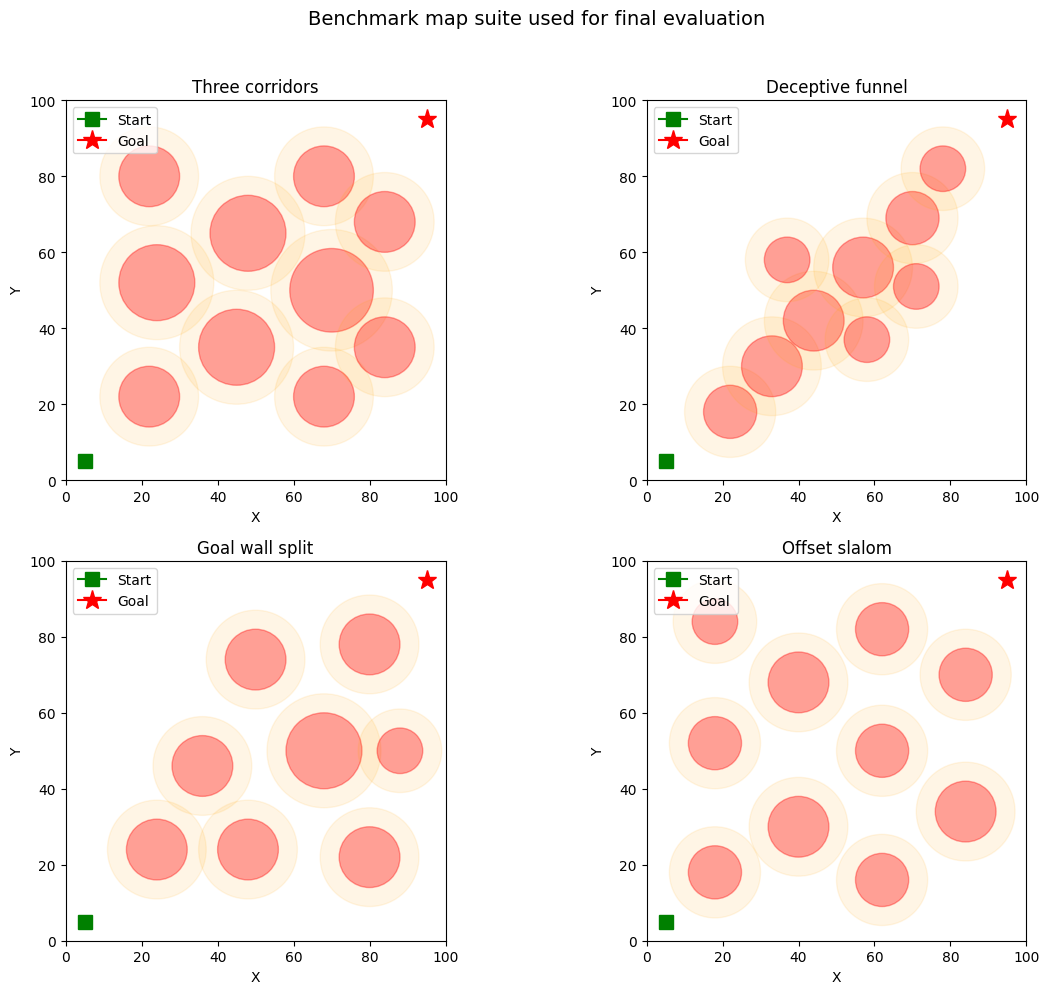

,map,note,obstacle_count,occupancy_ratio,overlap_pairs,min_pair_gap,direct_line_collisions
0,Three corridors,"Separated low, middle, and high corridor options.",10,0.252898,0,1.518285,2
1,Deceptive funnel,A central funnel that looks attractive early a...,9,0.136345,0,0.278821,6
2,Goal wall split,A late barrier near the goal creates a delayed...,8,0.163363,0,4.000000,3
3,Offset slalom,Alternating gaps with offset centerlines and n...,10,0.163991,0,10.059928,2


In [11]:
def make_map_config(
    base_map: MapConfig,
    obstacles: Sequence[CircleObstacle],
    n_waypoints: int | None = None,
    danger_margin: float | None = None,
    required_clearance: float | None = None,
) -> MapConfig:
    cfg = replace(
        base_map,
        n_waypoints=base_map.n_waypoints if n_waypoints is None else int(n_waypoints),
        obstacles=tuple(obstacles),
    )
    if danger_margin is not None or required_clearance is not None:
        cfg = replace(
            cfg,
            danger_margin=cfg.danger_margin if danger_margin is None else float(danger_margin),
            required_clearance=cfg.required_clearance if required_clearance is None else float(required_clearance),
        )
    assert not point_inside_any_obstacle(cfg.start, cfg.obstacles)
    assert not point_inside_any_obstacle(cfg.goal, cfg.obstacles)
    return cfg


def obstacle_occupancy_ratio(obstacles: Sequence[CircleObstacle], map_size: float) -> float:
    return float(sum(math.pi * obs.radius * obs.radius for obs in obstacles) / (map_size * map_size))


def pairwise_obstacle_gaps(obstacles: Sequence[CircleObstacle]) -> list[float]:
    gaps = []
    for i, obs_i in enumerate(obstacles):
        for obs_j in obstacles[i + 1 :]:
            gaps.append(math.hypot(obs_i.cx - obs_j.cx, obs_i.cy - obs_j.cy) - (obs_i.radius + obs_j.radius))
    return gaps


def direct_line_clearances(map_config: MapConfig) -> list[float]:
    return [obs.clearance_to_segment(map_config.start, map_config.goal) for obs in map_config.obstacles]


def build_map_suite(experiment_config: ExperimentConfig) -> dict[str, MapConfig]:
    base_map = experiment_config.development_map
    return {
        name: make_map_config(
            base_map,
            spec.obstacles,
            n_waypoints=base_map.n_waypoints,
            danger_margin=base_map.danger_margin,
            required_clearance=base_map.required_clearance,
        )
        for name, spec in experiment_config.benchmark_maps.items()
    }


benchmark_map_suite = build_map_suite(EXPERIMENT_CONFIG)
benchmark_map_notes = {name: spec.description for name, spec in EXPERIMENT_CONFIG.benchmark_maps.items()}

benchmark_map_summary = []
for map_name, map_config in benchmark_map_suite.items():
    gaps = pairwise_obstacle_gaps(map_config.obstacles)
    direct_clearances = direct_line_clearances(map_config)
    benchmark_map_summary.append(
        {
            "map": map_name,
            "note": benchmark_map_notes[map_name],
            "obstacle_count": len(map_config.obstacles),
            "occupancy_ratio": obstacle_occupancy_ratio(map_config.obstacles, map_config.size),
            "overlap_pairs": int(sum(gap < 0.0 for gap in gaps)),
            "min_pair_gap": float(min(gaps)) if gaps else np.nan,
            "direct_line_collisions": int(sum(clearance <= 0.0 for clearance in direct_clearances)),
        }
    )

benchmark_map_summary = pd.DataFrame(benchmark_map_summary)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (map_name, map_config) in zip(axes.flat, benchmark_map_suite.items()):
    plot_environment(ax, map_config, title=map_name)
fig.suptitle("Benchmark map suite used for final evaluation", fontsize=14, y=0.99)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

benchmark_map_summary


In [12]:
def _canonicalize(value: Any) -> Any:
    if is_dataclass(value):
        return _canonicalize(asdict(value))
    if isinstance(value, Path):
        return value.as_posix()
    if isinstance(value, Mapping):
        return {str(key): _canonicalize(value[key]) for key in sorted(value)}
    if isinstance(value, np.ndarray):
        return [_canonicalize(item) for item in value.tolist()]
    if isinstance(value, (list, tuple)):
        return [_canonicalize(item) for item in value]
    if isinstance(value, np.generic):
        return value.item()
    return value


def stable_fingerprint(payload: Mapping[str, Any]) -> str:
    encoded = json.dumps(_canonicalize(payload), sort_keys=True, separators=(",", ":")).encode("utf-8")
    return hashlib.sha256(encoded).hexdigest()


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate
    return current


def format_path_for_display(path: Path | None, repo_root: Path) -> str:
    if path is None:
        return "not written"
    try:
        return path.relative_to(repo_root).as_posix()
    except ValueError:
        return str(path)


def experiment_definition_payload(experiment_config: ExperimentConfig) -> dict[str, Any]:
    return {
        "development_map": _canonicalize(experiment_config.development_map),
        "benchmark_maps": _canonicalize(experiment_config.benchmark_maps),
        "tuning_seeds": list(experiment_config.tuning_seeds),
        "evaluation_seeds": list(experiment_config.evaluation_seeds),
        "ga_weight_grid": list(experiment_config.ga_weight_grid),
        "common_protocol": _canonicalize(experiment_config.common_protocol),
        "baseline_repair": _canonicalize(experiment_config.baseline_repair),
        "enhanced_repair": _canonicalize(experiment_config.enhanced_repair),
        "compromise_rule": experiment_config.compromise_rule,
        "route_checkpoints": list(experiment_config.route_checkpoints),
        "ga_weight_selection_rule": experiment_config.ga_weight_selection_rule,
        "gallery_seed_rule": experiment_config.gallery_seed_rule,
    }


def tuning_definition_payload(experiment_config: ExperimentConfig) -> dict[str, Any]:
    return {
        "artifact": "ga_weight_tuning",
        "experiment_definition": experiment_definition_payload(experiment_config),
    }


def condition_profile_payload(profile: ConditionProfile) -> dict[str, Any]:
    return {
        "name": profile.name,
        "comparison": profile.comparison,
        "algorithm": profile.algorithm,
        "protocol": _canonicalize(profile.protocol),
        "repair_policy": _canonicalize(profile.repair_policy),
        "weights": None if profile.weights is None else [float(w) for w in profile.weights],
    }


def cache_artifact_path(cache_dir: Path, artifact_name: str, fingerprint: str) -> Path:
    return cache_dir / f"{artifact_name}-{fingerprint[:16]}.pkl"


def write_cache_artifact(
    cache_dir: Path,
    artifact_name: str,
    fingerprint: str,
    definition: Mapping[str, Any],
    data: Any,
) -> Path:
    cache_dir.mkdir(parents=True, exist_ok=True)
    path = cache_artifact_path(cache_dir, artifact_name, fingerprint)
    artifact = {
        "meta": {
            "schema_version": CACHE_SCHEMA_VERSION,
            "artifact_name": artifact_name,
            "fingerprint": fingerprint,
            "definition": _canonicalize(definition),
        },
        "data": data,
    }
    with path.open("wb") as handle:
        pickle.dump(artifact, handle)
    return path


def read_cache_artifact(
    path: Path,
    artifact_name: str,
    fingerprint: str,
    definition: Mapping[str, Any],
) -> Any:
    with path.open("rb") as handle:
        artifact = pickle.load(handle)

    meta = artifact.get("meta", {})
    if meta.get("schema_version") != CACHE_SCHEMA_VERSION:
        raise ValueError(
            f"schema mismatch: expected {CACHE_SCHEMA_VERSION}, found {meta.get('schema_version')}"
        )
    if meta.get("artifact_name") != artifact_name:
        raise ValueError(
            f"artifact mismatch: expected {artifact_name}, found {meta.get('artifact_name')}"
        )
    if meta.get("fingerprint") != fingerprint:
        raise ValueError("fingerprint mismatch")
    if meta.get("definition") != _canonicalize(definition):
        raise ValueError("definition payload mismatch")
    return artifact["data"]


def load_or_compute_cached_artifact(
    *,
    cache_policy: CachePolicy,
    repo_root: Path,
    artifact_name: str,
    definition: Mapping[str, Any],
    fingerprint: str,
    compute_fn: Callable[[], Any],
) -> tuple[Any, dict[str, Any]]:
    cache_dir = cache_policy.cache_dir(repo_root)
    cache_path = cache_artifact_path(cache_dir, artifact_name, fingerprint)

    if cache_policy.enabled and not cache_policy.refresh and cache_path.exists():
        try:
            data = read_cache_artifact(cache_path, artifact_name, fingerprint, definition)
            return data, {"status": "cache-hit", "path": cache_path}
        except Exception as exc:
            print(f"Discarding stale {artifact_name} cache at {cache_path}: {exc}")

    data = compute_fn()
    if cache_policy.enabled and cache_policy.write_back:
        written_path = write_cache_artifact(cache_dir, artifact_name, fingerprint, definition, data)
        return data, {"status": "recomputed-and-cached", "path": written_path}
    if cache_policy.enabled and not cache_policy.write_back:
        return data, {"status": "recomputed-no-write", "path": None}
    return data, {"status": "cache-disabled", "path": None}


def aggregate_algorithm_runs(run_df: pd.DataFrame) -> dict[str, float]:
    return {
        "feasible_run_rate": float(run_df["has_feasible"].mean()),
        "median_feasible_count": float(run_df["feasible_count"].median()),
        "median_shortest_feasible_length": float(run_df["shortest_feasible_length"].median()),
        "median_safest_clearance": float(run_df["safest_feasible_min_clearance"].median()),
    }


def run_single_algorithm_multi_seed(
    run_callable: Callable[[MapConfig, int], object],
    map_config: MapConfig,
    seeds: Sequence[int],
) -> pd.DataFrame:
    rows = []
    for seed in seeds:
        res = run_callable(map_config, int(seed))
        rows.append({"seed": int(seed), **summarize_population_for_comparison(res, map_config)})
    return pd.DataFrame(rows)


def rank_ga_weight_results(summary_df: pd.DataFrame) -> pd.DataFrame:
    return summary_df.sort_values(
        ["feasible_run_rate", "median_shortest_feasible_length", "median_safest_clearance", "w_risk"],
        ascending=[False, True, False, True],
    ).reset_index(drop=True)


def compute_ga_tuning_summary(experiment_config: ExperimentConfig) -> pd.DataFrame:
    tuning_rows = []
    for w_risk in experiment_config.ga_weight_grid:
        tuning_profile = ConditionProfile(
            name=f"GA tuning w_R={float(w_risk):.1f}",
            comparison="Tuning",
            algorithm="GA",
            protocol=experiment_config.common_protocol,
            repair_policy=experiment_config.baseline_repair,
            weights=(1.0, float(w_risk)),
        )
        tuning_df = run_single_algorithm_multi_seed(
            tuning_profile.run,
            experiment_config.development_map,
            experiment_config.tuning_seeds,
        )
        tuning_rows.append({"w_risk": float(w_risk), **aggregate_algorithm_runs(tuning_df)})
    return rank_ga_weight_results(pd.DataFrame(tuning_rows))


def build_condition_profiles(
    experiment_config: ExperimentConfig,
    selected_ga_weight: float,
) -> dict[str, ConditionProfile]:
    return {
        "GA baseline": ConditionProfile(
            name="GA baseline",
            comparison="Baseline",
            algorithm="GA",
            protocol=experiment_config.common_protocol,
            repair_policy=experiment_config.baseline_repair,
            weights=(1.0, float(selected_ga_weight)),
        ),
        "NSGA-II baseline": ConditionProfile(
            name="NSGA-II baseline",
            comparison="Baseline",
            algorithm="NSGA-II",
            protocol=experiment_config.common_protocol,
            repair_policy=experiment_config.baseline_repair,
        ),
        "GA + repair": ConditionProfile(
            name="GA + repair",
            comparison="Enhanced",
            algorithm="GA",
            protocol=experiment_config.common_protocol,
            repair_policy=experiment_config.enhanced_repair,
            weights=(1.0, float(selected_ga_weight)),
        ),
        "NSGA-II + repair": ConditionProfile(
            name="NSGA-II + repair",
            comparison="Enhanced",
            algorithm="NSGA-II",
            protocol=experiment_config.common_protocol,
            repair_policy=experiment_config.enhanced_repair,
        ),
    }


def resolve_experiment_profile(
    experiment_config: ExperimentConfig,
    cache_policy: CachePolicy,
    repo_root: Path,
) -> tuple[ResolvedExperimentProfile, pd.DataFrame, dict[str, Any], dict[str, Any]]:
    tuning_definition = tuning_definition_payload(experiment_config)
    tuning_fingerprint = stable_fingerprint(tuning_definition)

    def compute_tuning_artifact() -> dict[str, Any]:
        tuning_summary = compute_ga_tuning_summary(experiment_config)
        selected_weight = float(tuning_summary.iloc[0]["w_risk"])
        return {
            "ga_tuning_summary": tuning_summary,
            "selected_ga_weight": selected_weight,
            "selection_rule": experiment_config.ga_weight_selection_rule,
        }

    tuning_artifact, tuning_cache_info = load_or_compute_cached_artifact(
        cache_policy=cache_policy,
        repo_root=repo_root,
        artifact_name="ga_weight_tuning",
        definition=tuning_definition,
        fingerprint=tuning_fingerprint,
        compute_fn=compute_tuning_artifact,
    )

    selected_ga_weight = float(tuning_artifact["selected_ga_weight"])
    condition_profiles = build_condition_profiles(experiment_config, selected_ga_weight)
    resolved_payload = {
        "experiment_definition": experiment_definition_payload(experiment_config),
        "selected_ga_weight": selected_ga_weight,
        "condition_profiles": {
            name: condition_profile_payload(profile)
            for name, profile in condition_profiles.items()
        },
    }
    benchmark_fingerprint = stable_fingerprint(
        {
            "artifact": "benchmark_suite",
            "resolved_profile": resolved_payload,
            "collect_population": True,
        }
    )
    ga_weight_source = "external tuning cache" if tuning_cache_info["status"] == "cache-hit" else "recomputed on the development map"
    resolved_profile = ResolvedExperimentProfile(
        selected_ga_weight=selected_ga_weight,
        ga_weight_source=ga_weight_source,
        condition_profiles=condition_profiles,
        tuning_fingerprint=tuning_fingerprint,
        benchmark_fingerprint=benchmark_fingerprint,
    )
    return resolved_profile, tuning_artifact["ga_tuning_summary"], tuning_cache_info, resolved_payload


REPO_ROOT = find_repo_root()
CACHE_DIR = CACHE_POLICY.cache_dir(REPO_ROOT)
RESOLVED_PROFILE, ga_tuning_summary, tuning_cache_info, RESOLVED_PROFILE_PAYLOAD = resolve_experiment_profile(
    EXPERIMENT_CONFIG,
    CACHE_POLICY,
    REPO_ROOT,
)
selected_ga_weight = float(RESOLVED_PROFILE.selected_ga_weight)

TUNING_SEEDS = list(EXPERIMENT_CONFIG.tuning_seeds)
EVALUATION_SEEDS = list(EXPERIMENT_CONFIG.evaluation_seeds)
CONDITION_SPECS = {
    name: {
        "comparison": profile.comparison,
        "algorithm": profile.algorithm,
        "repair": profile.repair_policy.label,
        "profile": profile,
    }
    for name, profile in RESOLVED_PROFILE.condition_profiles.items()
}

assert CONDITION_SPECS["GA baseline"]["profile"].weights == (1.0, selected_ga_weight)
assert CONDITION_SPECS["GA + repair"]["profile"].weights == (1.0, selected_ga_weight)
assert CONDITION_SPECS["NSGA-II baseline"]["profile"].weights is None
assert CONDITION_SPECS["NSGA-II + repair"]["profile"].weights is None
assert CONDITION_SPECS["GA baseline"]["profile"].repair_policy == EXPERIMENT_CONFIG.baseline_repair
assert CONDITION_SPECS["GA + repair"]["profile"].repair_policy == EXPERIMENT_CONFIG.enhanced_repair

seed_table = pd.DataFrame(
    [
        {"role": "tuning", "n_seeds": len(TUNING_SEEDS), "seeds": tuple(TUNING_SEEDS)},
        {"role": "evaluation", "n_seeds": len(EVALUATION_SEEDS), "seeds": tuple(EVALUATION_SEEDS)},
    ]
)
protocol_table = pd.DataFrame(
    [spec["profile"].resolved_protocol_view(config) for spec in CONDITION_SPECS.values()]
)
active_profile_table = pd.DataFrame(
    [
        {
            "cache_dir": format_path_for_display(CACHE_DIR, REPO_ROOT),
            "tuning_artifact": tuning_cache_info["status"],
            "ga_weight_source": RESOLVED_PROFILE.ga_weight_source,
            "selected_ga_weight": selected_ga_weight,
            "tuning_fingerprint": RESOLVED_PROFILE.tuning_fingerprint[:12],
            "benchmark_fingerprint": RESOLVED_PROFILE.benchmark_fingerprint[:12],
        }
    ]
)

print("Active experiment summary")
print(active_profile_table.to_string(index=False))
print()
print("Seed split")
print(seed_table.to_string(index=False))
print()
print("Resolved shared protocol and conditions")
print(protocol_table.to_string(index=False))
print()
print(
    f"Tuning artifact path: {format_path_for_display(tuning_cache_info['path'], REPO_ROOT)}"
)
print(f"Selected GA risk weight = {selected_ga_weight:.1f}")
print()
print("GA weight tuning screen")
print(ga_tuning_summary.to_string(index=False))

protocol_table


Active experiment summary
                      cache_dir       tuning_artifact                  ga_weight_source  selected_ga_weight tuning_fingerprint benchmark_fingerprint
uav/cache/uav_path_planning_gpu recomputed-and-cached recomputed on the development map                80.0       65ac00cafd24          306c106606b0

Seed split
      role  n_seeds                                                                                                seeds
    tuning        6                                                                                   (0, 1, 2, 3, 4, 5)
evaluation       20 (100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119)

Resolved shared protocol and conditions
       condition comparison algorithm             repair  pop_size  n_gen  function_evaluations     weights  crossover_prob  crossover_eta  mutation_eta  mutation_prob repair_application repair_kind
     GA baseline   Baseline        GA          No repair     

,condition,comparison,algorithm,repair,pop_size,n_gen,function_evaluations,weights,crossover_prob,crossover_eta,mutation_eta,mutation_prob,repair_application,repair_kind
0,GA baseline,Baseline,GA,No repair,80,80,6400,"(1.0, 80.0)",0.9,15.0,20.0,0.0625,none,none
1,NSGA-II baseline,Baseline,NSGA-II,No repair,80,80,6400,NaN,0.9,15.0,20.0,0.0625,none,none
2,GA + repair,Enhanced,GA,SegmentAwareRepair,80,80,6400,"(1.0, 80.0)",0.9,15.0,20.0,0.0625,offspring,segment
3,NSGA-II + repair,Enhanced,NSGA-II,SegmentAwareRepair,80,80,6400,NaN,0.9,15.0,20.0,0.0625,offspring,segment


In [13]:
runtime_summary = pd.DataFrame(
    [
        {
            "backend": RUNTIME_CONTEXT.backend,
            "accelerator": RUNTIME_CONTEXT.accelerator,
            "torch_available": RUNTIME_CONTEXT.torch_available,
            "torch_device": RUNTIME_CONTEXT.torch_device or "none",
            "float_dtype": RUNTIME_CONTEXT.float_dtype,
        }
    ]
)

print("Runtime backend summary")
print(runtime_summary.to_string(index=False))
runtime_summary


Runtime backend summary
backend accelerator  torch_available torch_device float_dtype
  torch        cuda             True         cuda     float64


,backend,accelerator,torch_available,torch_device,float_dtype
0,torch,cuda,True,cuda,float64


In [14]:
test_obstacle = CircleObstacle(5.0, 0.0, 5.0)
closest_point, projection = closest_point_on_segment((0.0, 0.0), (10.0, 0.0), test_obstacle.center)

geometry_checks = pd.DataFrame(
    [
        {"case": "outside point", "value": test_obstacle.signed_distance_to_point((11.0, 0.0)), "expected": 1.0},
        {"case": "boundary point", "value": test_obstacle.signed_distance_to_point((10.0, 0.0)), "expected": 0.0},
        {"case": "inside point", "value": test_obstacle.signed_distance_to_point((5.0, 0.0)), "expected": -5.0},
        {"case": "segment projection x", "value": closest_point[0], "expected": 5.0},
        {"case": "segment projection parameter", "value": projection, "expected": 0.5},
        {"case": "tangent segment clearance", "value": test_obstacle.clearance_to_segment((0.0, 5.0), (10.0, 5.0)), "expected": 0.0},
        {"case": "crossing segment clearance", "value": test_obstacle.clearance_to_segment((0.0, 0.0), (10.0, 0.0)), "expected": -5.0},
        {"case": "clear segment clearance", "value": test_obstacle.clearance_to_segment((0.0, 7.0), (10.0, 7.0)), "expected": 2.0},
        {"case": "zero-length boundary segment", "value": test_obstacle.clearance_to_segment((0.0, 0.0), (0.0, 0.0)), "expected": 0.0},
    ]
)

assert math.isclose(test_obstacle.signed_distance_to_point((11.0, 0.0)), 1.0, abs_tol=1e-9)
assert math.isclose(test_obstacle.signed_distance_to_point((10.0, 0.0)), 0.0, abs_tol=1e-9)
assert math.isclose(test_obstacle.signed_distance_to_point((5.0, 0.0)), -5.0, abs_tol=1e-9)
assert math.isclose(closest_point[0], 5.0, abs_tol=1e-9)
assert math.isclose(projection, 0.5, abs_tol=1e-9)
assert math.isclose(test_obstacle.clearance_to_segment((0.0, 5.0), (10.0, 5.0)), 0.0, abs_tol=1e-9)
assert test_obstacle.intersects_segment((0.0, 5.0), (10.0, 5.0))
assert math.isclose(test_obstacle.clearance_to_segment((0.0, 0.0), (10.0, 0.0)), -5.0, abs_tol=1e-9)
assert test_obstacle.intersects_segment((0.0, 0.0), (10.0, 0.0))
assert math.isclose(test_obstacle.clearance_to_segment((0.0, 7.0), (10.0, 7.0)), 2.0, abs_tol=1e-9)
assert not test_obstacle.intersects_segment((0.0, 7.0), (10.0, 7.0))
assert math.isclose(test_obstacle.clearance_to_segment((0.0, 0.0), (0.0, 0.0)), 0.0, abs_tol=1e-9)

repair_test_config = MapConfig(
    size=20.0,
    start=(2.0, 10.0),
    goal=(18.0, 10.0),
    n_waypoints=2,
    danger_margin=5.0,
    required_clearance=2.0,
    obstacles=(CircleObstacle(10.0, 10.0, 3.0),),
)
repair_input = np.array(
    [
        [7.0, 10.0, 13.0, 10.0],
        [7.0, 13.5, 13.0, 13.5],
    ],
    dtype=float,
)
repair = SegmentAwareRepair(repair_test_config, target_clearance=repair_test_config.required_clearance)
repair_before = evaluate_decision_vector(repair_input[0], repair_test_config)
repair_after_x = repair._do(None, repair_input[:1].copy())[0]
repair_after = evaluate_decision_vector(repair_after_x, repair_test_config)

assert repair_after.min_clearance > repair_before.min_clearance + 1e-6
assert repair_after.clearance_violation <= repair_before.clearance_violation + 1e-9

batch_evaluator = build_path_batch_evaluator(repair_test_config, RUNTIME_CONTEXT)
batch_metrics = batch_evaluator.evaluate(repair_input)
scalar_metrics = [evaluate_decision_vector(row, repair_test_config) for row in repair_input]

for idx, scalar in enumerate(scalar_metrics):
    assert math.isclose(batch_metrics.length[idx], scalar.length, rel_tol=1e-9, abs_tol=1e-9)
    assert math.isclose(batch_metrics.danger_penalty[idx], scalar.danger_penalty, rel_tol=1e-9, abs_tol=1e-9)
    assert math.isclose(batch_metrics.min_clearance[idx], scalar.min_clearance, rel_tol=1e-9, abs_tol=1e-9)
    assert math.isclose(batch_metrics.collision_violation[idx], scalar.collision_violation, rel_tol=1e-9, abs_tol=1e-9)
    assert math.isclose(batch_metrics.clearance_violation[idx], scalar.clearance_violation, rel_tol=1e-9, abs_tol=1e-9)
    assert bool(batch_metrics.feasible[idx]) == bool(scalar.feasible)

print(f"Runtime backend: {RUNTIME_CONTEXT.label}")
print("Geometry, vectorized evaluator, and segment-repair checks passed.")
geometry_checks


Runtime backend: torch-cuda
Geometry, vectorized evaluator, and segment-repair checks passed.


,case,value,expected
0,outside point,1.0,1.0
1,boundary point,0.0,0.0
2,inside point,-5.0,-5.0
3,segment projection x,5.0,5.0
4,segment projection parameter,0.5,0.5
5,tangent segment clearance,0.0,0.0
6,crossing segment clearance,-5.0,-5.0
7,clear segment clearance,2.0,2.0
8,zero-length boundary segment,0.0,0.0


## 7. Baseline comparison results

This section answers the first half of the research question under the strict baseline protocol:

- `GA baseline`
- `NSGA-II baseline`

Both conditions use the same benchmark maps, the same seeds, the same waypoint representation, the same initialization strategy, the same population size, and the same total function-evaluation budget. Neither method receives repair assistance here.

This section keeps two views separate:

- a direct **single-solution** comparison: GA incumbent versus NSGA-II compromise candidate
- a **retained-representative** comparison: what the final feasible set preserves for shortest, safest, and compromise-style choices

The gallery that follows is therefore a visual interpretation aid for the retained-representative view, not a substitute for the aggregated benchmark tables.


In [15]:
ROUTE_CHECKPOINTS = EXPERIMENT_CONFIG.route_checkpoints


def interpolate_y_at_x(path: Sequence[Point], x_target: float) -> float:
    hits: list[tuple[float, float]] = []

    for p1, p2 in path_segments(path):
        x1, y1 = p1
        x2, y2 = p2
        if min(x1, x2) - 1e-9 <= x_target <= max(x1, x2) + 1e-9:
            if abs(x2 - x1) < 1e-9:
                hits.append((abs(x1 - x_target), 0.5 * (y1 + y2)))
            else:
                t = (x_target - x1) / (x2 - x1)
                if -1e-9 <= t <= 1.0 + 1e-9:
                    hits.append((abs(t - 0.5), y1 + t * (y2 - y1)))

    if hits:
        hits.sort(key=lambda item: item[0])
        return float(hits[0][1])

    return float(min(path, key=lambda point: abs(point[0] - x_target))[1])


def corridor_landmark_obstacles(map_config: MapConfig, checkpoints: Sequence[float]) -> list[CircleObstacle]:
    remaining = list(map_config.obstacles)
    landmarks: list[CircleObstacle] = []
    direct_line = (map_config.start, map_config.goal)

    for checkpoint in checkpoints:
        if not remaining:
            break
        landmark = min(
            remaining,
            key=lambda obs: (
                abs(obs.cx - checkpoint),
                abs(obs.clearance_to_segment(*direct_line)),
                -obs.radius,
            ),
        )
        landmarks.append(landmark)
        remaining.remove(landmark)

    return landmarks


def obstacle_side_label(path: Sequence[Point], obstacle: CircleObstacle, map_config: MapConfig) -> str:
    y_at_obstacle = interpolate_y_at_x(path, obstacle.cx)
    signed_offset = y_at_obstacle - obstacle.cy
    side_threshold = obstacle.radius + map_config.required_clearance
    if signed_offset > side_threshold:
        return "above"
    if signed_offset < -side_threshold:
        return "below"
    return "centerline"


def route_family_signature(path: Sequence[Point], map_config: MapConfig, checkpoints: Sequence[float] = ROUTE_CHECKPOINTS) -> str:
    landmark_labels = []
    for obstacle in corridor_landmark_obstacles(map_config, checkpoints):
        landmark_labels.append(f"x{int(round(obstacle.cx))}:{obstacle_side_label(path, obstacle, map_config)}")
    return "|".join(landmark_labels)


def extract_feasible_share_history(res, config: MapConfig) -> np.ndarray:
    ratios = []
    for algo in res.history:
        X = np.asarray(algo.pop.get("X"))
        feasible = [evaluate_decision_vector(x, config).feasible for x in X]
        ratios.append(float(np.mean(feasible)))
    return np.asarray(ratios, dtype=float)


def plot_nsga_objective_space(res, config: MapConfig, title_prefix: str):
    representatives, table, _ = pick_nsga2_representatives(
        res,
        config,
        compromise_rule=EXPERIMENT_CONFIG.compromise_rule,
    )
    feasible_mask = table["feasible"].to_numpy(dtype=bool)
    all_objectives = table[["length", "danger_penalty"]].to_numpy(dtype=float)

    marker_specs = {
        "shortest": ("s", "tab:green", "Shortest feasible"),
        "safest": ("^", "tab:orange", "Safest feasible"),
        "compromise": ("*", "tab:red", "Compromise"),
    }

    def draw_panel(ax, x_values, y_values, title: str):
        if (~feasible_mask).any():
            ax.scatter(
                x_values[~feasible_mask],
                y_values[~feasible_mask],
                color="lightgray",
                edgecolors="black",
                label="Not feasible",
            )
        ax.scatter(
            x_values[feasible_mask],
            y_values[feasible_mask],
            color="tab:blue",
            edgecolors="black",
            label="Feasible candidates",
        )
        for key, (marker, color, label) in marker_specs.items():
            rep = representatives[key]
            if rep is None:
                continue
            metrics = rep["metrics"]
            ax.scatter(
                [metrics.length],
                [metrics.danger_penalty],
                marker=marker,
                s=220,
                color=color,
                edgecolors="black",
                label=label,
            )
        ax.set_title(title)
        ax.grid(alpha=0.3)

    fig, ax = plt.subplots(1, 1, figsize=(6.8, 5))
    draw_panel(ax, all_objectives[:, 0], all_objectives[:, 1], title=f"{title_prefix}: raw objective space")
    ax.set_xlabel("Path length")
    ax.set_ylabel("Danger penalty")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

    return table


def summarize_population_with_route_diversity(res, map_config: MapConfig):
    X, F = get_final_population(res)
    table = solution_set_table(X, F, map_config).copy()
    table["route_family"] = [
        route_family_signature(
            decode_solution(np.asarray(x), map_config),
            map_config,
            checkpoints=EXPERIMENT_CONFIG.route_checkpoints,
        )
        for x in np.atleast_2d(X)
    ]

    summary = summarize_population_for_comparison(res, map_config)
    feasible_table = table.loc[table["feasible"]]
    summary["feasible_route_family_count"] = int(feasible_table["route_family"].nunique()) if not feasible_table.empty else 0
    summary["dominant_feasible_route_family"] = (
        feasible_table["route_family"].mode().iat[0] if not feasible_table.empty else "none"
    )

    representative_map = {
        "shortest_feasible": select_shortest_feasible_idx(table),
        "safest_feasible": select_safest_feasible_idx(table),
        "compromise": select_compromise_feasible_idx(table),
    }
    for prefix, idx in representative_map.items():
        summary[f"{prefix}_route_family"] = "none" if idx is None else str(table.loc[idx, "route_family"])

    return summary, table


def summarize_selected_solution(res, condition_profile: ConditionProfile, map_config: MapConfig) -> dict[str, object]:
    if condition_profile.algorithm == "GA":
        x, metrics, meta = pick_ga_incumbent(res, map_config, weights=condition_profile.weights)
        path = decode_solution(x, map_config)
        solution_label = "GA incumbent"
    else:
        view, _, meta = pick_nsga2_compromise_candidate(
            res,
            map_config,
            compromise_rule=EXPERIMENT_CONFIG.compromise_rule,
        )
        metrics = view["metrics"]
        path = view["path"]
        solution_label = "NSGA-II compromise candidate"

    return {
        "selected_solution_label": solution_label,
        "selected_selection_rule": meta["selection_label"],
        "selected_feasible": bool(metrics.feasible),
        "selected_length": float(metrics.length),
        "selected_danger_penalty": float(metrics.danger_penalty),
        "selected_min_clearance": float(metrics.min_clearance),
        "selected_route_family": route_family_signature(
            path,
            map_config,
            checkpoints=EXPERIMENT_CONFIG.route_checkpoints,
        ),
    }


def run_condition_suite(
    map_suite: dict[str, MapConfig],
    seeds: Sequence[int],
    condition_specs: dict[str, dict],
    collect_population: bool = False,
):
    run_rows = []
    population_tables = []
    selected_solution_rows = []

    for map_name, map_config in map_suite.items():
        for condition_name, spec in condition_specs.items():
            condition_profile = spec["profile"]
            for seed in seeds:
                res = condition_profile.run(map_config, seed=int(seed))
                summary, table = summarize_population_with_route_diversity(res, map_config)
                base_row = {
                    "map": map_name,
                    "condition": condition_name,
                    "comparison": spec["comparison"],
                    "algorithm": spec["algorithm"],
                    "repair": spec["repair"],
                    "seed": int(seed),
                    "n_waypoints": map_config.n_waypoints,
                }
                run_rows.append({**base_row, **summary})
                selected_solution_rows.append(
                    {
                        **base_row,
                        **summarize_selected_solution(res, condition_profile, map_config),
                    }
                )
                if collect_population:
                    population_tables.append(
                        table.assign(
                            map=map_name,
                            condition=condition_name,
                            comparison=spec["comparison"],
                            algorithm=spec["algorithm"],
                            repair=spec["repair"],
                            seed=int(seed),
                            n_waypoints=map_config.n_waypoints,
                        )
                    )

    run_df = pd.DataFrame(run_rows)
    population_df = pd.concat(population_tables, ignore_index=True) if population_tables else pd.DataFrame()
    selected_solution_df = pd.DataFrame(selected_solution_rows)
    return run_df, population_df, selected_solution_df


def aggregate_condition_summary(run_df: pd.DataFrame, group_cols: Sequence[str]) -> pd.DataFrame:
    rows = []
    for keys, group in run_df.groupby(list(group_cols)):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: key for col, key in zip(group_cols, keys)}
        dominant_mode = group["dominant_feasible_route_family"].mode()
        row.update(
            {
                "feasible_run_rate": float(group["has_feasible"].mean()),
                "median_feasible_count": float(group["feasible_count"].median()),
                "q1_feasible_count": float(group["feasible_count"].quantile(0.25)),
                "q3_feasible_count": float(group["feasible_count"].quantile(0.75)),
                "median_shortest_feasible_length": float(group["shortest_feasible_length"].median()),
                "q1_shortest_feasible_length": float(group["shortest_feasible_length"].quantile(0.25)),
                "q3_shortest_feasible_length": float(group["shortest_feasible_length"].quantile(0.75)),
                "median_safest_clearance": float(group["safest_feasible_min_clearance"].median()),
                "q1_safest_clearance": float(group["safest_feasible_min_clearance"].quantile(0.25)),
                "q3_safest_clearance": float(group["safest_feasible_min_clearance"].quantile(0.75)),
                "mean_route_family_count": float(group["feasible_route_family_count"].mean()),
                "dominant_route_family": dominant_mode.iat[0] if not dominant_mode.empty else "none",
            }
        )
        rows.append(row)
    return pd.DataFrame(rows)


def select_display_seed(run_df: pd.DataFrame, map_name: str, condition_name: str) -> int:
    # Choose a representative feasible run for gallery display within one condition.
    subset = run_df.loc[(run_df["map"] == map_name) & (run_df["condition"] == condition_name)].copy()
    if subset["has_feasible"].any():
        subset = subset.loc[subset["has_feasible"]].copy()

    target_length = float(subset["shortest_feasible_length"].median(skipna=True))
    subset["length_gap"] = (subset["shortest_feasible_length"] - target_length).abs().fillna(np.inf)
    subset = subset.sort_values(
        ["length_gap", "feasible_count", "safest_feasible_min_clearance", "seed"],
        ascending=[True, False, False, True],
    )
    return int(subset.iloc[0]["seed"])


def annotate_path_panel(ax, metrics: PathMetrics, route_family: str):
    ax.text(
        0.02,
        0.02,
        f"L={metrics.length:.1f}\nclr={metrics.min_clearance:.2f}\nfamily={route_family}",
        transform=ax.transAxes,
        va="bottom",
        ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="gray", alpha=0.85),
    )


Development-map illustrative seed = 100

GA baseline incumbent
  overall feasible    = yes
  collision-free      = yes
  clearance-feasible  = yes
  length              = 329.460
  clearance penalty   = 0.400
  min clearance       = 2.369
  collision segments  = 0
  selection           = GA incumbent from weighted optimization

NSGA-II baseline final population
  candidates            = 80
  geometric-feasible    = 80
  safety-feasible       = 80


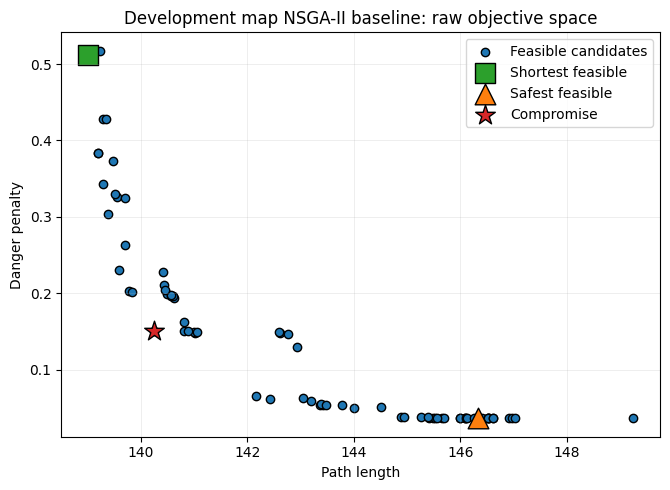

,idx,length,danger_penalty,min_clearance,collision_segments,collision_violation,clearance_violation,out_of_bounds_violation,in_bounds,geometric_feasible,clearance_feasible,feasible,weighted_score,f1,f2
0,0,145.653608,0.036784,4.118567,0,0.0,0.0,0.0,True,True,True,True,NaN,145.653608,0.036784
1,1,145.407868,0.037111,4.117466,0,0.0,0.0,0.0,True,True,True,True,NaN,145.407868,0.037111
2,2,139.189165,0.383700,2.162754,0,0.0,0.0,0.0,True,True,True,True,NaN,139.189165,0.383700
3,3,146.329461,0.036328,4.119479,0,0.0,0.0,0.0,True,True,True,True,NaN,146.329461,0.036328
4,4,145.258581,0.037241,4.117233,0,0.0,0.0,0.0,True,True,True,True,NaN,145.258581,0.037241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,75,139.558617,0.326437,2.379302,0,0.0,0.0,0.0,True,True,True,True,NaN,139.558617,0.326437
76,76,139.694947,0.324029,2.394492,0,0.0,0.0,0.0,True,True,True,True,NaN,139.694947,0.324029
77,77,139.475086,0.373033,2.190813,0,0.0,0.0,0.0,True,True,True,True,NaN,139.475086,0.373033
78,78,139.518866,0.329715,2.371818,0,0.0,0.0,0.0,True,True,True,True,NaN,139.518866,0.329715


In [16]:
demo_seed = EVALUATION_SEEDS[0]
ga_baseline_profile = CONDITION_SPECS["GA baseline"]["profile"]
nsga_baseline_profile = CONDITION_SPECS["NSGA-II baseline"]["profile"]

ga_demo_res = ga_baseline_profile.run(config, seed=demo_seed)
nsga_demo_res = nsga_baseline_profile.run(config, seed=demo_seed)

ga_demo_x, ga_demo_metrics, ga_demo_meta = pick_ga_incumbent(
    ga_demo_res,
    config,
    weights=ga_baseline_profile.weights,
)
nsga_demo_reps, nsga_demo_table, nsga_demo_meta = pick_nsga2_representatives(
    nsga_demo_res,
    config,
    compromise_rule=EXPERIMENT_CONFIG.compromise_rule,
)

print(f"Development-map illustrative seed = {demo_seed}")
print()
print_solution_summary("GA baseline incumbent", ga_demo_metrics, {"selection": ga_demo_meta["selection_label"]})
print()
print("NSGA-II baseline final population")
print(f"  candidates            = {nsga_demo_meta['candidate_count']}")
print(f"  geometric-feasible    = {nsga_demo_meta['collision_free_count']}")
print(f"  safety-feasible       = {nsga_demo_meta['feasible_count']}")

plot_nsga_objective_space(nsga_demo_res, config, title_prefix="Development map NSGA-II baseline")


In [17]:
def plot_comparison_gallery(run_df: pd.DataFrame, comparison_name: str):
    # Show one GA incumbent and three NSGA-II representatives for each benchmark map.
    ordered_maps = list(benchmark_map_suite.keys())
    ga_condition = "GA baseline" if comparison_name == "Baseline" else "GA + repair"
    nsga_condition = "NSGA-II baseline" if comparison_name == "Baseline" else "NSGA-II + repair"

    fig, axes = plt.subplots(len(ordered_maps), 4, figsize=(16.5, 4.2 * len(ordered_maps)))
    axes = np.atleast_2d(axes)
    header_positions = [0.17, 0.41, 0.64, 0.87]
    column_headers = [
        f"{ga_condition}\nWeighted incumbent",
        f"{nsga_condition}\nShortest feasible",
        f"{nsga_condition}\nSafest feasible",
        f"{nsga_condition}\nCompromise",
    ]
    for x_pos, header in zip(header_positions, column_headers):
        fig.text(x_pos, 0.965, header, ha="center", va="top", fontsize=10.5, fontweight="bold")

    for row, map_name in enumerate(ordered_maps):
        map_config = benchmark_map_suite[map_name]
        axes[row, 0].text(
            -0.34,
            0.5,
            map_name,
            transform=axes[row, 0].transAxes,
            rotation=90,
            va="center",
            ha="center",
            fontsize=11,
            fontweight="bold",
        )

        ga_seed = select_display_seed(run_df, map_name, ga_condition)
        nsga_seed = select_display_seed(run_df, map_name, nsga_condition)

        ga_spec = CONDITION_SPECS[ga_condition]
        nsga_spec = CONDITION_SPECS[nsga_condition]
        ga_profile = ga_spec["profile"]
        nsga_profile = nsga_spec["profile"]

        ga_res = ga_profile.run(map_config, seed=ga_seed)
        nsga_res = nsga_profile.run(map_config, seed=nsga_seed)

        ga_x, ga_metrics, _ = pick_ga_incumbent(ga_res, map_config, weights=ga_profile.weights)
        ga_path = decode_solution(ga_x, map_config)
        plot_environment(axes[row, 0], map_config, ga_path, title=f"Seed {ga_seed}")
        if axes[row, 0].legend_ is not None:
            axes[row, 0].legend_.remove()
        annotate_path_panel(
            axes[row, 0],
            ga_metrics,
            route_family_signature(
                ga_path,
                map_config,
                checkpoints=EXPERIMENT_CONFIG.route_checkpoints,
            ),
        )

        nsga_reps, _, _ = pick_nsga2_representatives(
            nsga_res,
            map_config,
            compromise_rule=EXPERIMENT_CONFIG.compromise_rule,
        )
        for rep_key, col in [("shortest", 1), ("safest", 2), ("compromise", 3)]:
            rep = nsga_reps[rep_key]
            ax = axes[row, col]
            if rep is None:
                plot_environment(ax, map_config, title=f"Seed {nsga_seed}")
                if ax.legend_ is not None:
                    ax.legend_.remove()
                ax.text(0.5, 0.5, "No feasible\nrepresentative", ha="center", va="center")
                continue
            plot_environment(ax, map_config, rep["path"], title=f"Seed {nsga_seed}")
            if ax.legend_ is not None:
                ax.legend_.remove()
            annotate_path_panel(
                ax,
                rep["metrics"],
                route_family_signature(
                    rep["path"],
                    map_config,
                    checkpoints=EXPERIMENT_CONFIG.route_checkpoints,
                ),
            )

    fig.suptitle(f"{comparison_name} retained-representative path gallery", fontsize=14, y=0.995)
    plt.tight_layout(rect=(0.03, 0.0, 1.0, 0.92))
    plt.show()


SINGLE_SOLUTION_METRIC_SPECS = [
    {"column": "selected_feasible", "label": "Selected-solution feasible indicator", "better": "higher", "family": "binary"},
    {"column": "selected_length", "label": "Selected path length", "better": "lower", "family": "length"},
    {"column": "selected_danger_penalty", "label": "Selected danger penalty", "better": "lower", "family": "danger"},
    {"column": "selected_min_clearance", "label": "Selected minimum clearance", "better": "higher", "family": "clearance"},
]
REPRESENTATIVE_METRIC_SPECS = [
    {"column": "has_feasible", "label": "Feasible-run indicator", "better": "higher", "family": "binary"},
    {"column": "shortest_feasible_length", "label": "Shortest retained feasible length", "better": "lower", "family": "length"},
    {"column": "safest_feasible_min_clearance", "label": "Safest retained feasible clearance", "better": "higher", "family": "clearance"},
    {"column": "feasible_count", "label": "Feasible candidates in final population", "better": "higher", "family": "count"},
]
CONDITION_COLORS = {
    "GA baseline": "#4c78a8",
    "NSGA-II baseline": "#f58518",
    "GA + repair": "#54a24b",
    "NSGA-II + repair": "#e45756",
}
CONDITION_MARKERS = {
    "GA baseline": "o",
    "NSGA-II baseline": "D",
    "GA + repair": "s",
    "NSGA-II + repair": "^",
}


def paired_bootstrap_ci(values: Sequence[float], n_boot: int = 2000, seed: int = 2026) -> tuple[float, float, float]:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, len(values), size=(n_boot, len(values)))
    boot_means = values[indices].mean(axis=1)
    return float(values.mean()), float(np.quantile(boot_means, 0.025)), float(np.quantile(boot_means, 0.975))


def align_paired_metric(run_df: pd.DataFrame, left_condition: str, right_condition: str, metric: str) -> pd.DataFrame:
    subset = run_df.loc[
        run_df["condition"].isin([left_condition, right_condition]),
        ["map", "seed", "condition", metric],
    ]
    aligned = subset.pivot_table(index=["map", "seed"], columns="condition", values=metric, aggfunc="first")
    if left_condition not in aligned.columns or right_condition not in aligned.columns:
        return pd.DataFrame(columns=[left_condition, right_condition])
    return aligned[[left_condition, right_condition]].astype(float)


def wilcoxon_pvalue(diff: Sequence[float]) -> float:
    diff = np.asarray(diff, dtype=float)
    diff = diff[np.isfinite(diff)]
    diff = diff[~np.isclose(diff, 0.0, atol=1e-12)]
    if len(diff) == 0:
        return 1.0
    try:
        return float(wilcoxon(diff, alternative="two-sided", zero_method="wilcox").pvalue)
    except ValueError:
        return np.nan


def rank_biserial_from_differences(diff: Sequence[float]) -> float:
    diff = np.asarray(diff, dtype=float)
    diff = diff[np.isfinite(diff)]
    diff = diff[~np.isclose(diff, 0.0, atol=1e-12)]
    if len(diff) == 0:
        return 0.0
    ranks = rankdata(np.abs(diff), method="average")
    rank_sum_positive = float(ranks[diff > 0.0].sum())
    rank_sum_negative = float(ranks[diff < 0.0].sum())
    total_rank = float(ranks.sum())
    return 0.0 if total_rank <= 0.0 else (rank_sum_positive - rank_sum_negative) / total_rank


def effect_size_label(rank_biserial_value: float) -> str:
    magnitude = abs(float(rank_biserial_value))
    if magnitude < 0.10:
        return "negligible"
    if magnitude < 0.30:
        return "small"
    if magnitude < 0.50:
        return "medium"
    return "large"


def preferred_side_from_shift(rank_biserial_value: float, median_diff: float, better_direction: str) -> str:
    signed_shift = float(np.sign(median_diff))
    if math.isclose(signed_shift, 0.0, abs_tol=1e-12):
        signed_shift = float(np.sign(rank_biserial_value))
    if better_direction == "lower":
        signed_shift = -signed_shift
    if signed_shift > 1e-12:
        return "right"
    if signed_shift < -1e-12:
        return "left"
    return "none"


def operational_gap_label(metric_family: str, median_diff: float) -> str:
    if not np.isfinite(median_diff):
        return "Insufficient paired data for an operational reading."

    magnitude = abs(float(median_diff))
    map_size = float(EXPERIMENT_CONFIG.development_map.size)
    required_clearance = float(EXPERIMENT_CONFIG.development_map.required_clearance)

    if metric_family == "binary":
        if magnitude < 0.05:
            return "Practically small on this map-by-seed suite."
        if magnitude < 0.15:
            return "Noticeable but still modest in repeated runs."
        return "Large enough to matter in repeated runs."

    if metric_family == "length":
        if magnitude < 0.02 * map_size:
            return "Small at the 100x100 map scale."
        if magnitude < 0.05 * map_size:
            return "Visible but still modest at map scale."
        return "Large enough to change the route materially on this map scale."

    if metric_family == "clearance":
        if magnitude < 0.25 * required_clearance:
            return "Small relative to the clearance requirement."
        if magnitude < 0.75 * required_clearance:
            return "Meaningful relative to the clearance requirement."
        return "Large relative to the clearance requirement."

    if metric_family == "danger":
        if magnitude < 0.05:
            return "Small on the danger-penalty scale used here."
        if magnitude < 0.15:
            return "Noticeable on the danger-penalty scale used here."
        return "Material on the danger-penalty scale used here."

    if metric_family == "count":
        if magnitude < 1.0:
            return "Small in terms of retained feasible alternatives."
        if magnitude < 3.0:
            return "Noticeable in retained feasible alternatives."
        return "Large in retained feasible alternatives."

    return "Descriptive only."


def paired_shift_note(
    rank_biserial_value: float,
    median_diff: float,
    better_direction: str,
    left_condition: str,
    right_condition: str,
) -> str:
    favored_side = preferred_side_from_shift(rank_biserial_value, median_diff, better_direction)
    magnitude_label = effect_size_label(rank_biserial_value)
    if favored_side == "right":
        return f"{magnitude_label} paired shift toward {right_condition}"
    if favored_side == "left":
        return f"{magnitude_label} paired shift toward {left_condition}"
    return "no consistent paired shift"


def paired_comparison_table(
    run_df: pd.DataFrame,
    left_condition: str,
    right_condition: str,
    metric_specs: Sequence[Mapping[str, str]],
) -> pd.DataFrame:
    rows = []
    for spec in metric_specs:
        aligned = align_paired_metric(run_df, left_condition, right_condition, spec["column"])
        if aligned.empty:
            diff = np.array([], dtype=float)
        else:
            diff = (aligned[right_condition] - aligned[left_condition]).to_numpy(dtype=float)
        finite_diff = diff[np.isfinite(diff)]
        mean_diff, ci_low, ci_high = paired_bootstrap_ci(finite_diff)
        median_diff = float(np.nanmedian(finite_diff)) if len(finite_diff) else np.nan
        p_value = wilcoxon_pvalue(finite_diff)
        rank_biserial_value = rank_biserial_from_differences(finite_diff)
        rows.append(
            {
                "comparison": f"{right_condition} minus {left_condition}",
                "left_condition": left_condition,
                "right_condition": right_condition,
                "metric": spec["label"],
                "better_direction": spec["better"],
                "metric_family": spec["family"],
                "n_pairs": int(np.isfinite(diff).sum()),
                "mean_difference": mean_diff,
                "ci_low": ci_low,
                "ci_high": ci_high,
                "median_difference": median_diff,
                "wilcoxon_p": p_value,
                "rank_biserial": rank_biserial_value,
                "effect_note": paired_shift_note(
                    rank_biserial_value,
                    median_diff,
                    spec["better"],
                    left_condition,
                    right_condition,
                ),
                "operational_note": operational_gap_label(spec["family"], median_diff),
            }
        )
    return pd.DataFrame(rows)


def comparison_sentences(effect_table: pd.DataFrame) -> list[str]:
    sentences = []
    for _, row in effect_table.iterrows():
        median_diff = float(row["median_difference"])
        if not np.isfinite(median_diff):
            sentences.append(f"{row['metric']}: insufficient paired data.")
            continue

        if row["better_direction"] == "lower":
            if median_diff < 0.0:
                direction_clause = f"{row['right_condition']} is lower by a median of {abs(median_diff):.3g}"
            elif median_diff > 0.0:
                direction_clause = f"{row['left_condition']} is lower by a median of {abs(median_diff):.3g}"
            else:
                direction_clause = "the paired median difference is approximately zero"
        else:
            if median_diff > 0.0:
                direction_clause = f"{row['right_condition']} is higher by a median of {abs(median_diff):.3g}"
            elif median_diff < 0.0:
                direction_clause = f"{row['left_condition']} is higher by a median of {abs(median_diff):.3g}"
            else:
                direction_clause = "the paired median difference is approximately zero"

        p_value = row["wilcoxon_p"]
        p_text = f"p={p_value:.3f}" if np.isfinite(p_value) else "p unavailable"
        sentences.append(
            f"{row['metric']}: {direction_clause}; {row['effect_note']} "
            f"(rank-biserial={row['rank_biserial']:.2f}, Wilcoxon {p_text}); {row['operational_note']}"
        )
    return sentences


def aggregate_selected_solution_summary(run_df: pd.DataFrame, group_cols: Sequence[str]) -> pd.DataFrame:
    rows = []
    for keys, group in run_df.groupby(list(group_cols)):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: key for col, key in zip(group_cols, keys)}
        dominant_mode = group["selected_route_family"].mode()
        row.update(
            {
                "selected_feasible_rate": float(group["selected_feasible"].mean()),
                "median_selected_length": float(group["selected_length"].median()),
                "q1_selected_length": float(group["selected_length"].quantile(0.25)),
                "q3_selected_length": float(group["selected_length"].quantile(0.75)),
                "median_selected_danger_penalty": float(group["selected_danger_penalty"].median()),
                "q1_selected_danger_penalty": float(group["selected_danger_penalty"].quantile(0.25)),
                "q3_selected_danger_penalty": float(group["selected_danger_penalty"].quantile(0.75)),
                "median_selected_clearance": float(group["selected_min_clearance"].median()),
                "q1_selected_clearance": float(group["selected_min_clearance"].quantile(0.25)),
                "q3_selected_clearance": float(group["selected_min_clearance"].quantile(0.75)),
                "dominant_selected_corridor_signature": (
                    dominant_mode.iat[0] if not dominant_mode.empty else "none"
                ),
            }
        )
        rows.append(row)
    return pd.DataFrame(rows)


def condition_specs_from_profiles(condition_profiles: Mapping[str, ConditionProfile]) -> dict[str, dict[str, object]]:
    return {
        name: {
            "comparison": profile.comparison,
            "algorithm": profile.algorithm,
            "repair": profile.repair_policy.label,
            "profile": profile,
        }
        for name, profile in condition_profiles.items()
    }


def condition_specs_with_generation_budget(
    condition_specs: Mapping[str, Mapping[str, object]],
    n_gen: int,
) -> dict[str, dict[str, object]]:
    updated = {}
    for name, spec in condition_specs.items():
        profile = spec["profile"]
        updated_profile = replace(profile, protocol=replace(profile.protocol, n_gen=int(n_gen)))
        updated[name] = {
            "comparison": updated_profile.comparison,
            "algorithm": updated_profile.algorithm,
            "repair": updated_profile.repair_policy.label,
            "profile": updated_profile,
        }
    return updated


def experiment_config_with_waypoint_count(experiment_config: ExperimentConfig, n_waypoints: int) -> ExperimentConfig:
    return replace(
        experiment_config,
        development_map=replace(experiment_config.development_map, n_waypoints=int(n_waypoints)),
    )


def plot_condition_dumbbell(
    ax,
    summary_df: pd.DataFrame,
    left_condition: str,
    right_condition: str,
    metric: str,
    title: str,
    xlabel: str,
    ordered_maps: Sequence[str] | None = None,
):
    ordered_maps = list(benchmark_map_suite.keys()) if ordered_maps is None else list(ordered_maps)
    y_positions = np.arange(len(ordered_maps))
    left_values = []
    right_values = []

    for y, map_name in enumerate(ordered_maps):
        subset = summary_df.loc[summary_df["map"] == map_name].set_index("condition")
        left_value = float(subset.loc[left_condition, metric])
        right_value = float(subset.loc[right_condition, metric])
        left_values.append(left_value)
        right_values.append(right_value)
        ax.plot([left_value, right_value], [y, y], color="0.70", linewidth=2, zorder=1)

    ax.scatter(left_values, y_positions, color="#4c78a8", s=60, label=left_condition, zorder=3)
    ax.scatter(right_values, y_positions, color="#f58518", marker="D", s=60, label=right_condition, zorder=3)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(ordered_maps)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(alpha=0.3, axis="x")


def plot_overall_metric_profiles(
    ax,
    summary_df: pd.DataFrame,
    x_col: str,
    metric: str,
    title: str,
    ylabel: str,
    *,
    condition_order: Sequence[str] | None = None,
):
    condition_order = list(CONDITION_COLORS.keys()) if condition_order is None else list(condition_order)
    for condition_name in condition_order:
        subset = summary_df.loc[summary_df["condition"] == condition_name].sort_values(x_col)
        if subset.empty:
            continue
        ax.plot(
            subset[x_col],
            subset[metric],
            marker=CONDITION_MARKERS.get(condition_name, "o"),
            linewidth=2,
            color=CONDITION_COLORS.get(condition_name),
            label=condition_name,
        )
    ax.set_title(title)
    ax.set_xlabel(x_col.replace("_", " ").title())
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)


def compute_benchmark_artifact() -> dict[str, pd.DataFrame]:
    run_df, population_df, selected_solution_df = run_condition_suite(
        benchmark_map_suite,
        EVALUATION_SEEDS,
        CONDITION_SPECS,
        collect_population=True,
    )
    return {
        "benchmark_runs": run_df,
        "benchmark_population": population_df,
        "selected_solution_runs": selected_solution_df,
    }


benchmark_definition = {
    "artifact": "benchmark_suite",
    "resolved_profile": RESOLVED_PROFILE_PAYLOAD,
    "collect_population": True,
}
benchmark_artifact, benchmark_cache_info = load_or_compute_cached_artifact(
    cache_policy=CACHE_POLICY,
    repo_root=REPO_ROOT,
    artifact_name="benchmark_suite",
    definition=benchmark_definition,
    fingerprint=RESOLVED_PROFILE.benchmark_fingerprint,
    compute_fn=compute_benchmark_artifact,
)
benchmark_runs = benchmark_artifact["benchmark_runs"]
benchmark_population = benchmark_artifact["benchmark_population"]
selected_solution_runs = benchmark_artifact["selected_solution_runs"]
baseline_runs = benchmark_runs.loc[benchmark_runs["comparison"] == "Baseline"].copy()
enhanced_runs = benchmark_runs.loc[benchmark_runs["comparison"] == "Enhanced"].copy()
baseline_single_solution_runs = selected_solution_runs.loc[selected_solution_runs["comparison"] == "Baseline"].copy()
enhanced_single_solution_runs = selected_solution_runs.loc[selected_solution_runs["comparison"] == "Enhanced"].copy()
overall_condition_summary = aggregate_condition_summary(
    benchmark_runs,
    ["comparison", "condition"],
).sort_values(["comparison", "condition"]).reset_index(drop=True)

print("Benchmark evaluation summary")
print(
    overall_condition_summary[
        [
            "comparison",
            "condition",
            "feasible_run_rate",
            "median_shortest_feasible_length",
            "median_safest_clearance",
        ]
    ].to_string(index=False)
)
print()
print(
    f"Benchmark artifact: {benchmark_cache_info['status']} "
    f"({format_path_for_display(benchmark_cache_info['path'], REPO_ROOT)})"
)

overall_condition_summary

Benchmark evaluation summary
comparison        condition  feasible_run_rate  median_shortest_feasible_length  median_safest_clearance
  Baseline      GA baseline             0.9875                       170.810755                 4.811108
  Baseline NSGA-II baseline             0.9125                       164.668346                 5.072031
  Enhanced      GA + repair             1.0000                       153.946649                 4.685792
  Enhanced NSGA-II + repair             1.0000                       147.398309                 5.059491

Benchmark artifact: recomputed-and-cached (uav/cache/uav_path_planning_gpu/benchmark_suite-306c106606b0d6df.pkl)


,comparison,condition,feasible_run_rate,median_feasible_count,q1_feasible_count,q3_feasible_count,median_shortest_feasible_length,q1_shortest_feasible_length,q3_shortest_feasible_length,median_safest_clearance,q1_safest_clearance,q3_safest_clearance,mean_route_family_count,dominant_route_family
0,Baseline,GA baseline,0.9875,80.0,80.0,80.0,170.810755,156.501590,196.562468,4.811108,4.427913,5.143948,1.0125,x24:above|x36:above|x68:above|x80:above
1,Baseline,NSGA-II baseline,0.9125,80.0,80.0,80.0,164.668346,154.045567,202.850426,5.072031,4.944483,5.498557,1.0125,x24:above|x36:above|x68:above|x80:above
2,Enhanced,GA + repair,1.0000,80.0,80.0,80.0,153.946649,146.795640,171.536067,4.685792,4.084234,4.917133,1.0000,x24:above|x36:above|x68:above|x80:above
3,Enhanced,NSGA-II + repair,1.0000,80.0,80.0,80.0,147.398309,141.376371,158.247581,5.059491,4.813500,5.149992,1.0875,x24:above|x36:above|x68:above|x80:above


Baseline single-solution summary by map
             map        condition  selected_feasible_rate  median_selected_length  median_selected_danger_penalty  median_selected_clearance
Deceptive funnel      GA baseline                    1.00              164.796746                        0.000009                   4.994571
Deceptive funnel NSGA-II baseline                    1.00              158.561054                        0.000000                   5.312518
 Goal wall split      GA baseline                    1.00              158.772280                        0.000000                   5.172078
 Goal wall split NSGA-II baseline                    1.00              156.120891                        0.042055                   4.141655
   Offset slalom      GA baseline                    1.00              217.180741                        0.058761                   3.902494
   Offset slalom NSGA-II baseline                    0.95              225.828729                        0.085173 

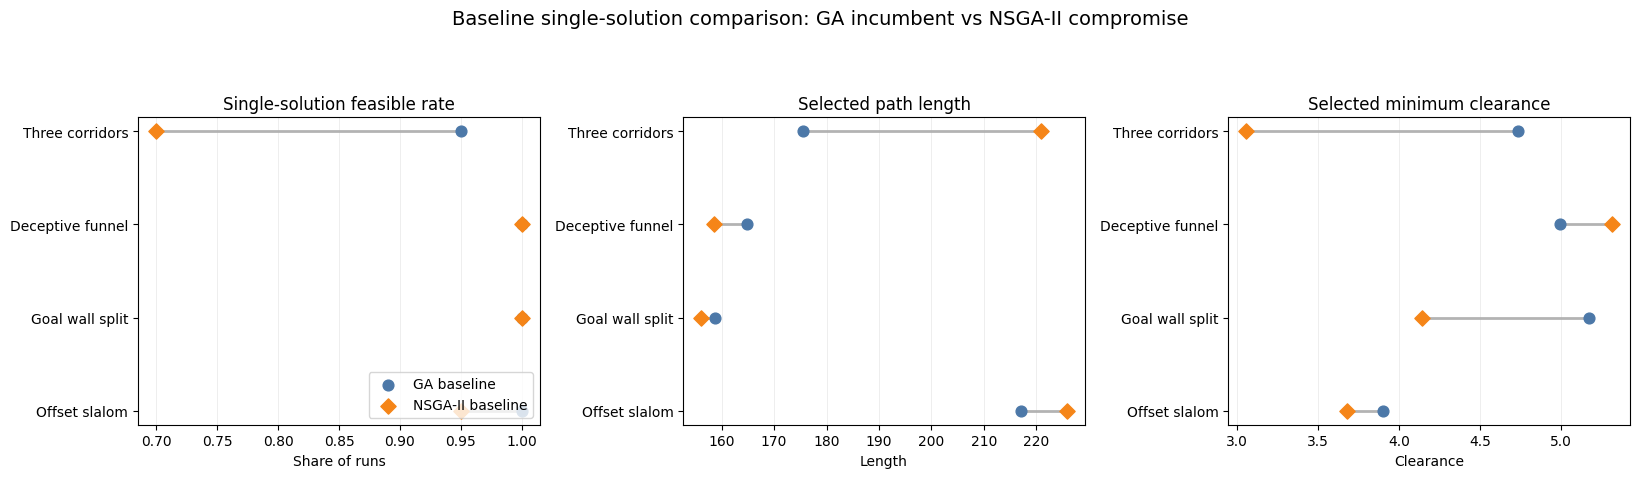

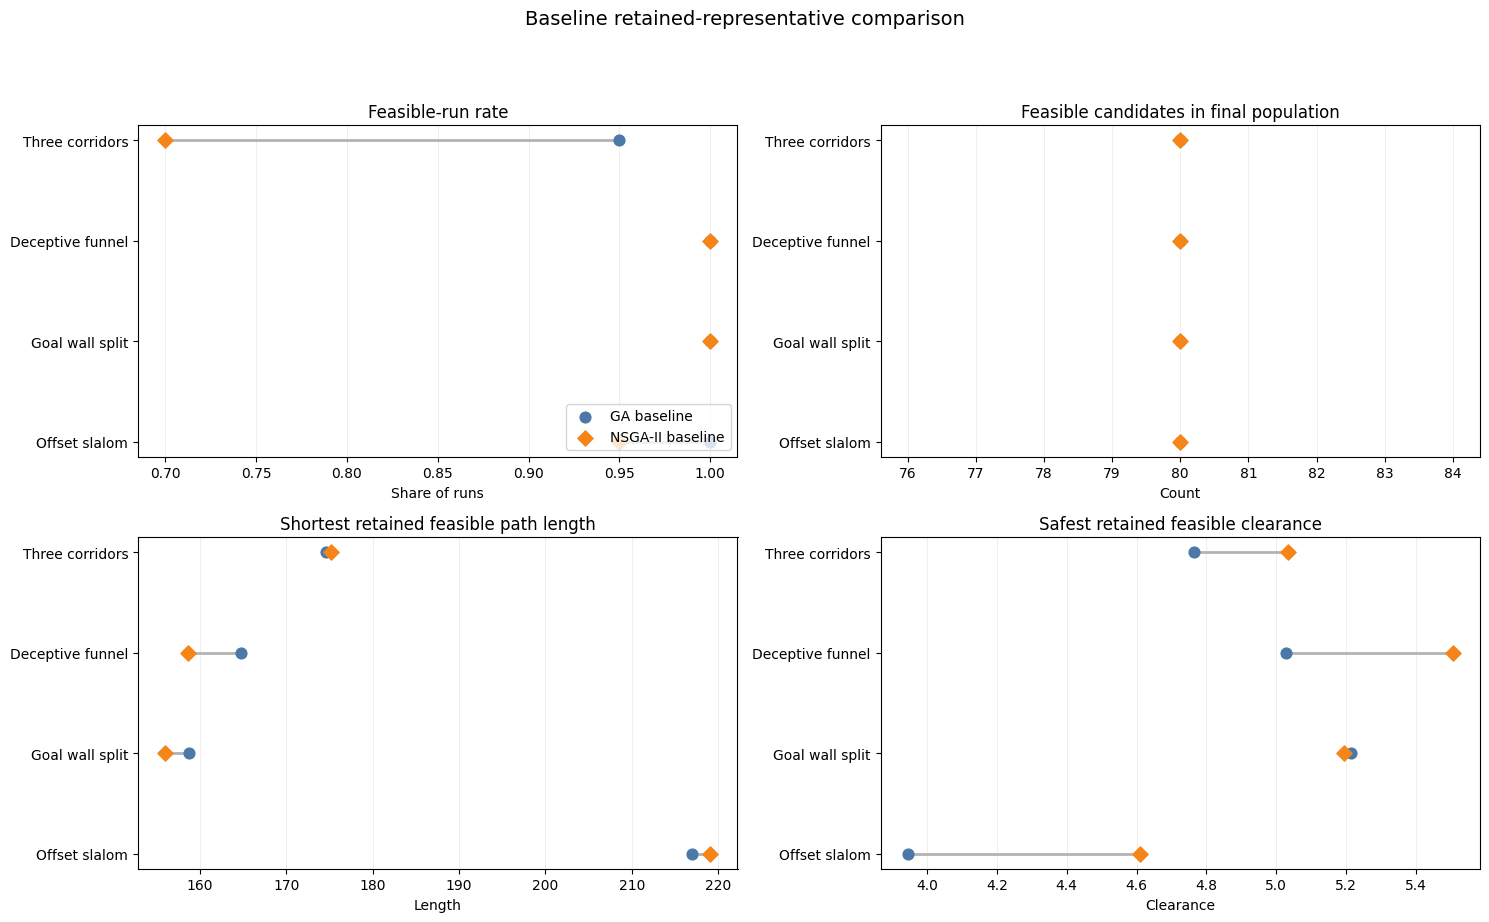

,condition,selected_feasible_rate,median_selected_length,q1_selected_length,q3_selected_length,median_selected_danger_penalty,q1_selected_danger_penalty,q3_selected_danger_penalty,median_selected_clearance,q1_selected_clearance,q3_selected_clearance,dominant_selected_corridor_signature
0,GA baseline,0.9875,171.050836,156.966102,199.952500,0.002591,0.0,0.024119,4.762013,4.312942,5.057497,x24:above|x36:above|x68:above|x80:above
1,NSGA-II baseline,0.9125,168.781818,155.868078,236.139097,0.064935,0.0,0.134359,3.859536,3.327773,5.038147,x24:above|x36:above|x68:above|x80:above


In [18]:
baseline_single_summary = aggregate_selected_solution_summary(
    baseline_single_solution_runs,
    ["map", "condition"],
).sort_values(["map", "condition"]).reset_index(drop=True)
baseline_single_overall = aggregate_selected_solution_summary(
    baseline_single_solution_runs,
    ["condition"],
).sort_values("condition").reset_index(drop=True)
baseline_single_effect_table = paired_comparison_table(
    baseline_single_solution_runs,
    "GA baseline",
    "NSGA-II baseline",
    SINGLE_SOLUTION_METRIC_SPECS,
)

baseline_representative_summary = aggregate_condition_summary(
    baseline_runs,
    ["map", "condition"],
).sort_values(["map", "condition"]).reset_index(drop=True)
baseline_representative_overall = aggregate_condition_summary(
    baseline_runs,
    ["condition"],
).sort_values("condition").reset_index(drop=True)
baseline_representative_effect_table = paired_comparison_table(
    baseline_runs,
    "GA baseline",
    "NSGA-II baseline",
    REPRESENTATIVE_METRIC_SPECS,
)

print("Baseline single-solution summary by map")
print(
    baseline_single_summary[
        [
            "map",
            "condition",
            "selected_feasible_rate",
            "median_selected_length",
            "median_selected_danger_penalty",
            "median_selected_clearance",
        ]
    ].to_string(index=False)
)
print()
print("Baseline single-solution overall")
print(
    baseline_single_overall[
        [
            "condition",
            "selected_feasible_rate",
            "median_selected_length",
            "median_selected_danger_penalty",
            "median_selected_clearance",
        ]
    ].to_string(index=False)
)
print()
print("Baseline direct paired effects: NSGA-II compromise candidate minus GA incumbent")
print(
    baseline_single_effect_table[
        [
            "metric",
            "n_pairs",
            "median_difference",
            "ci_low",
            "ci_high",
            "wilcoxon_p",
            "rank_biserial",
            "effect_note",
            "operational_note",
        ]
    ].to_string(index=False)
)
print()
print("Baseline direct comparison in plain language")
for sentence in comparison_sentences(baseline_single_effect_table):
    print(f"- {sentence}")
print()
print("Baseline retained-representative summary by map")
print(
    baseline_representative_summary[
        [
            "map",
            "condition",
            "feasible_run_rate",
            "median_feasible_count",
            "median_shortest_feasible_length",
            "median_safest_clearance",
        ]
    ].to_string(index=False)
)
print()
print("Baseline retained-representative overall")
print(
    baseline_representative_overall[
        [
            "condition",
            "feasible_run_rate",
            "median_feasible_count",
            "median_shortest_feasible_length",
            "median_safest_clearance",
        ]
    ].to_string(index=False)
)
print()
print("Baseline retained-representative paired effects")
print(
    baseline_representative_effect_table[
        [
            "metric",
            "n_pairs",
            "median_difference",
            "ci_low",
            "ci_high",
            "wilcoxon_p",
            "rank_biserial",
            "effect_note",
            "operational_note",
        ]
    ].to_string(index=False)
)
print()
print("Baseline retained-representative comparison in plain language")
for sentence in comparison_sentences(baseline_representative_effect_table):
    print(f"- {sentence}")

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
baseline_single_metric_specs = [
    ("selected_feasible_rate", "Single-solution feasible rate", "Share of runs"),
    ("median_selected_length", "Selected path length", "Length"),
    ("median_selected_clearance", "Selected minimum clearance", "Clearance"),
]
for ax, (metric, title, xlabel) in zip(axes.flat, baseline_single_metric_specs):
    plot_condition_dumbbell(ax, baseline_single_summary, "GA baseline", "NSGA-II baseline", metric, title, xlabel)
axes[0].legend(loc="lower right")
fig.suptitle("Baseline single-solution comparison: GA incumbent vs NSGA-II compromise", fontsize=14, y=1.03)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
baseline_representative_metric_specs = [
    ("feasible_run_rate", "Feasible-run rate", "Share of runs"),
    ("median_feasible_count", "Feasible candidates in final population", "Count"),
    ("median_shortest_feasible_length", "Shortest retained feasible path length", "Length"),
    ("median_safest_clearance", "Safest retained feasible clearance", "Clearance"),
]
for ax, (metric, title, xlabel) in zip(axes.flat, baseline_representative_metric_specs):
    plot_condition_dumbbell(ax, baseline_representative_summary, "GA baseline", "NSGA-II baseline", metric, title, xlabel)
axes[0, 0].legend(loc="lower right")
fig.suptitle("Baseline retained-representative comparison", fontsize=14, y=1.02)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

baseline_single_overall

### Baseline interpretation

The main apples-to-apples question in this section is the direct **single-solution** one: **GA incumbent versus NSGA-II compromise candidate**. That view asks what happens if each method must hand back one path at the end of the run.

The retained-representative tables answer a different question. They show what NSGA-II keeps available in its final feasible set, not proof that NSGA-II always discovers one universally superior path. In that retained-trade-off sense, NSGA-II can be stronger even when the direct single-solution evidence is mixed.

Accordingly, the baseline evidence should be read as follows:

- the direct single-solution baseline comparison is mixed rather than one-sided: GA can be stronger on selected feasibility and clearance, while NSGA-II can be competitive on selected length
- NSGA-II's clearer advantage appears in the retained-representative view, where it preserves stronger shortest, safest, and compromise-style alternatives
- the notebook does **not** claim that NSGA-II always yields one better single path in every sense


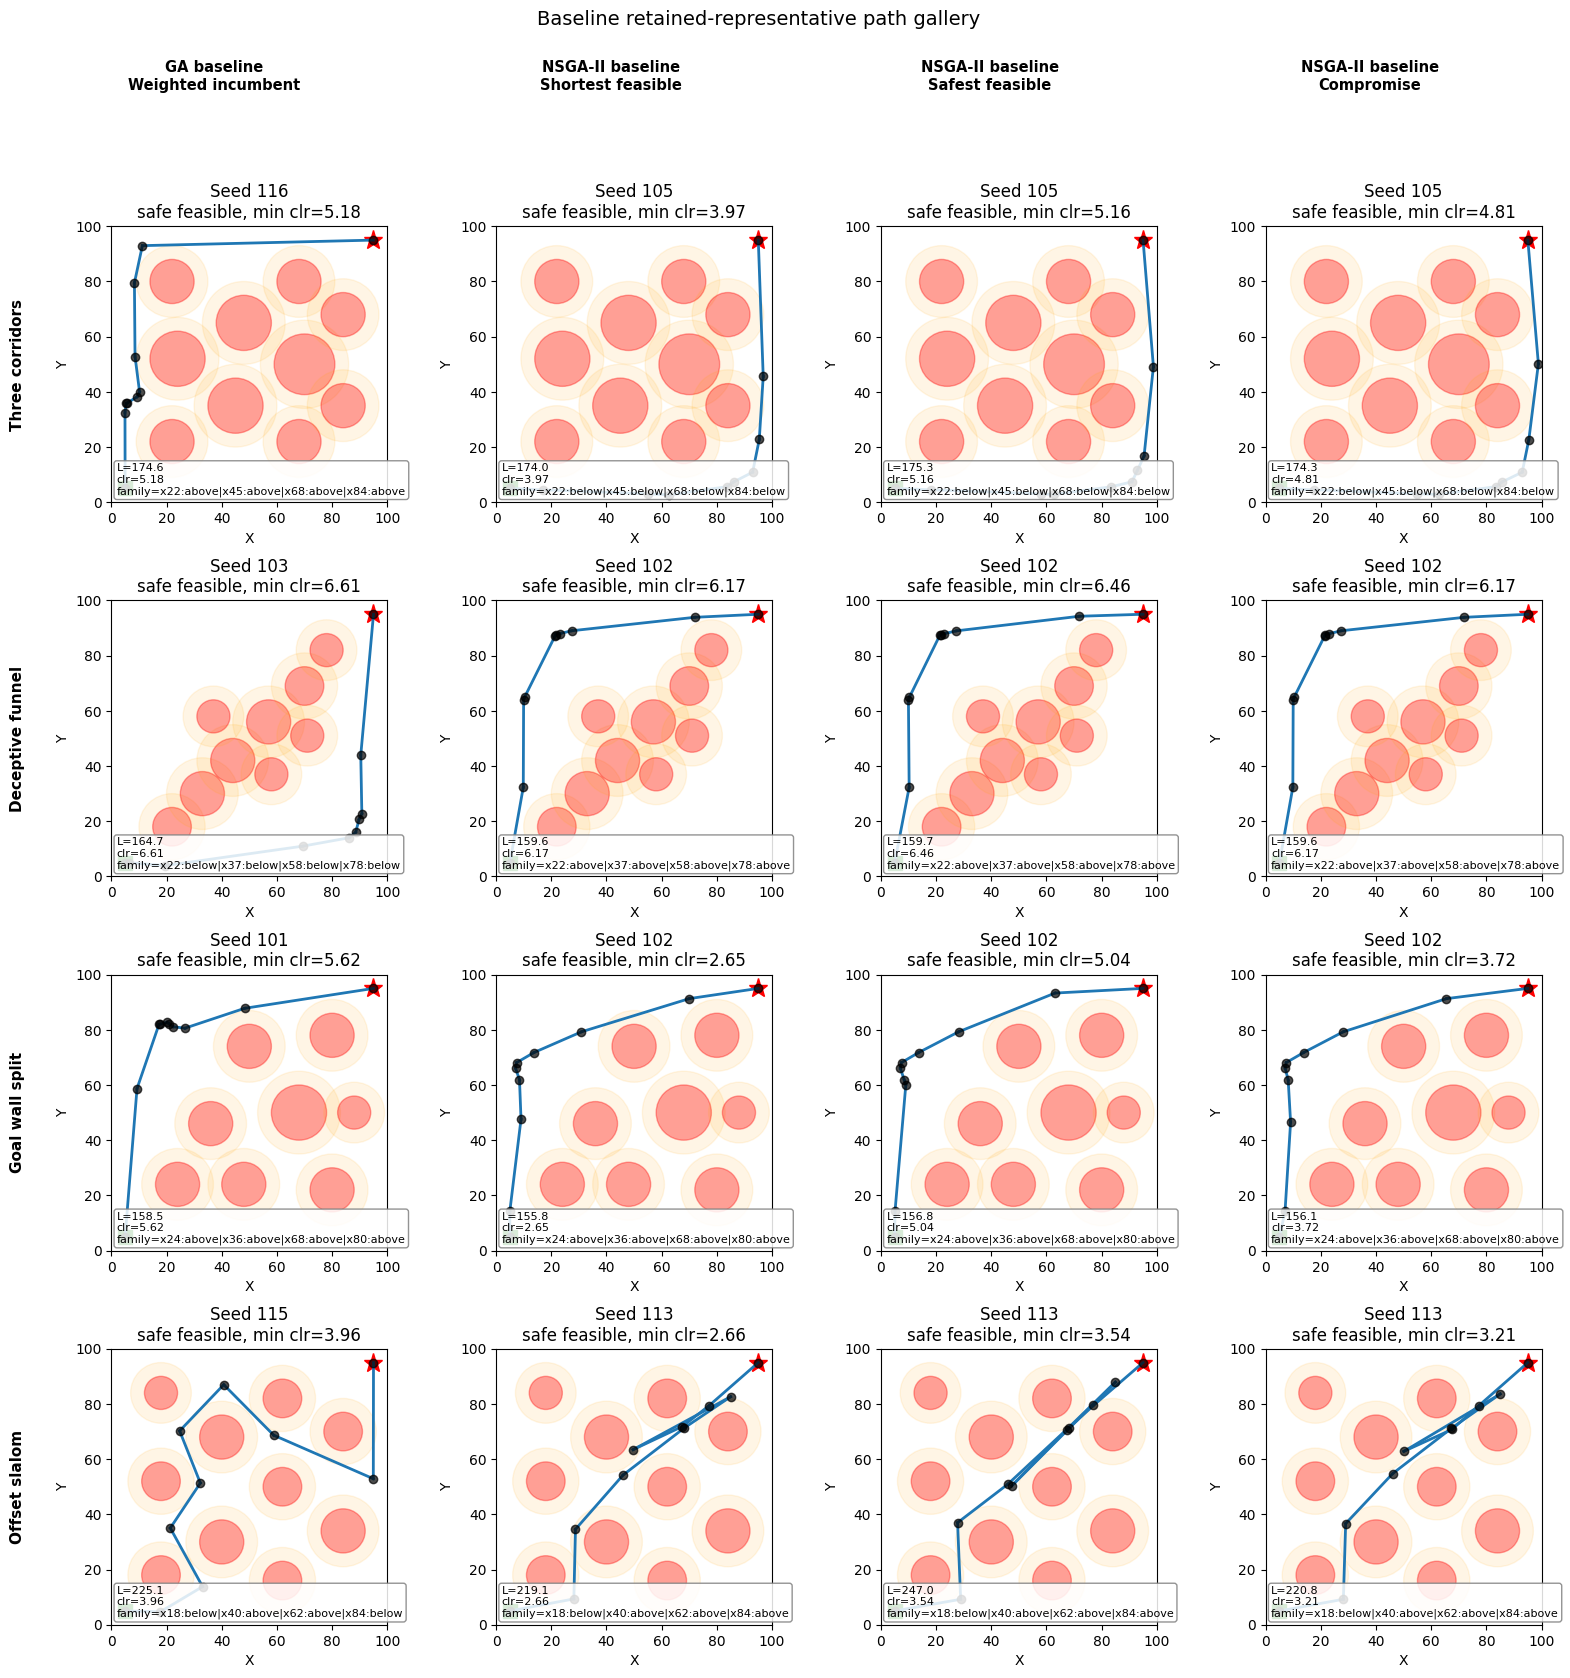

In [19]:
plot_comparison_gallery(baseline_runs, "Baseline")

**Figure note.** Baseline gallery. The left column shows the weighted-sum GA incumbent. The three NSGA-II columns show the shortest feasible, safest feasible, and compromise representatives from the final feasible set. Display seeds are chosen within each condition by proximity to that condition's median shortest feasible path, so the gallery is illustrative rather than a separate evaluation metric.


## 8. Enhanced comparison results

This section repeats the same fair comparison after adding the same obstacle-aware offspring repair operator to both algorithms:

- `GA + repair`
- `NSGA-II + repair`

The purpose is not to create a different experimental world for each algorithm. The purpose is to test whether one shared geometric enhancement changes feasible robustness or retained path quality under the same budget and seed protocol.

As in the baseline section, the results are split into two views:

- a direct **single-solution** comparison: GA incumbent versus NSGA-II compromise candidate
- a **retained-representative** comparison: what the final feasible set preserves after the shared repair operator is enabled


### Development-map feasibility diagnostic

The plot below helps explain the role of repair. It is an illustrative diagnostic on the development map, not part of the benchmark evidence used for the final baseline or enhanced comparison.


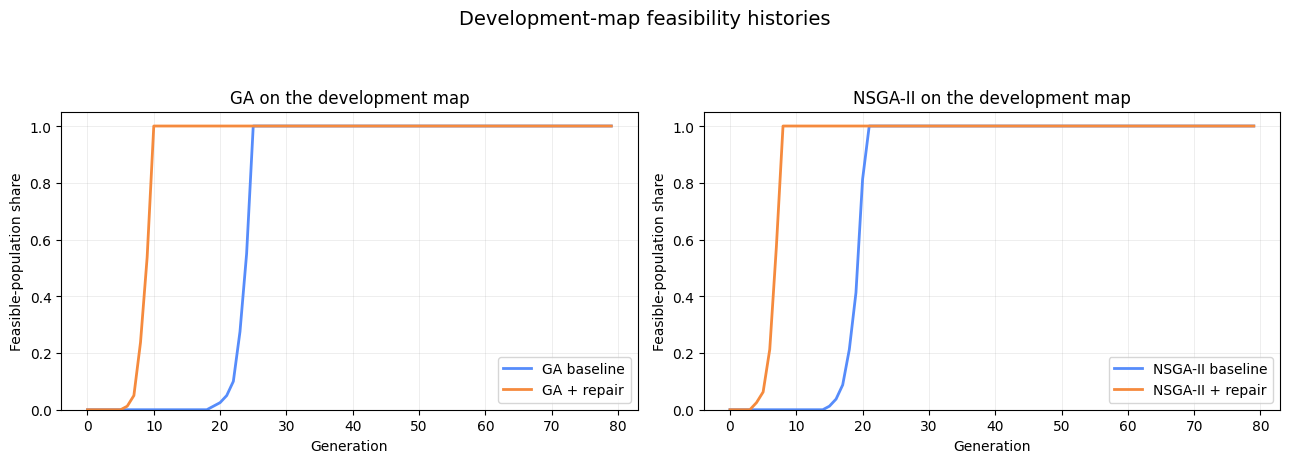

In [20]:
demo_seed = EVALUATION_SEEDS[0]
ga_base_demo = CONDITION_SPECS["GA baseline"]["profile"].run(config, seed=demo_seed)
ga_repair_demo = CONDITION_SPECS["GA + repair"]["profile"].run(config, seed=demo_seed)
nsga_base_demo = CONDITION_SPECS["NSGA-II baseline"]["profile"].run(config, seed=demo_seed)
nsga_repair_demo = CONDITION_SPECS["NSGA-II + repair"]["profile"].run(config, seed=demo_seed)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(extract_feasible_share_history(ga_base_demo, config), label="GA baseline", linewidth=2)
axes[0].plot(extract_feasible_share_history(ga_repair_demo, config), label="GA + repair", linewidth=2)
axes[0].set_title("GA on the development map")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Feasible-population share")
axes[0].set_ylim(0, 1.05)
axes[0].grid(alpha=0.3)
axes[0].legend(loc="lower right")

axes[1].plot(extract_feasible_share_history(nsga_base_demo, config), label="NSGA-II baseline", linewidth=2)
axes[1].plot(extract_feasible_share_history(nsga_repair_demo, config), label="NSGA-II + repair", linewidth=2)
axes[1].set_title("NSGA-II on the development map")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Feasible-population share")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)
axes[1].legend(loc="lower right")

fig.suptitle("Development-map feasibility histories", fontsize=14, y=1.02)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()


Enhanced single-solution summary by map
             map        condition  selected_feasible_rate  median_selected_length  median_selected_danger_penalty  median_selected_clearance
Deceptive funnel      GA + repair                     1.0              156.892036                        0.000684                   4.878416
Deceptive funnel NSGA-II + repair                     1.0              152.525994                        0.034335                   4.125551
 Goal wall split      GA + repair                     1.0              150.505960                        0.000596                   4.884238
 Goal wall split NSGA-II + repair                     1.0              146.335459                        0.101749                   3.599033
   Offset slalom      GA + repair                     1.0              147.903370                        0.015335                   4.484682
   Offset slalom NSGA-II + repair                     1.0              144.096939                        0.074892 

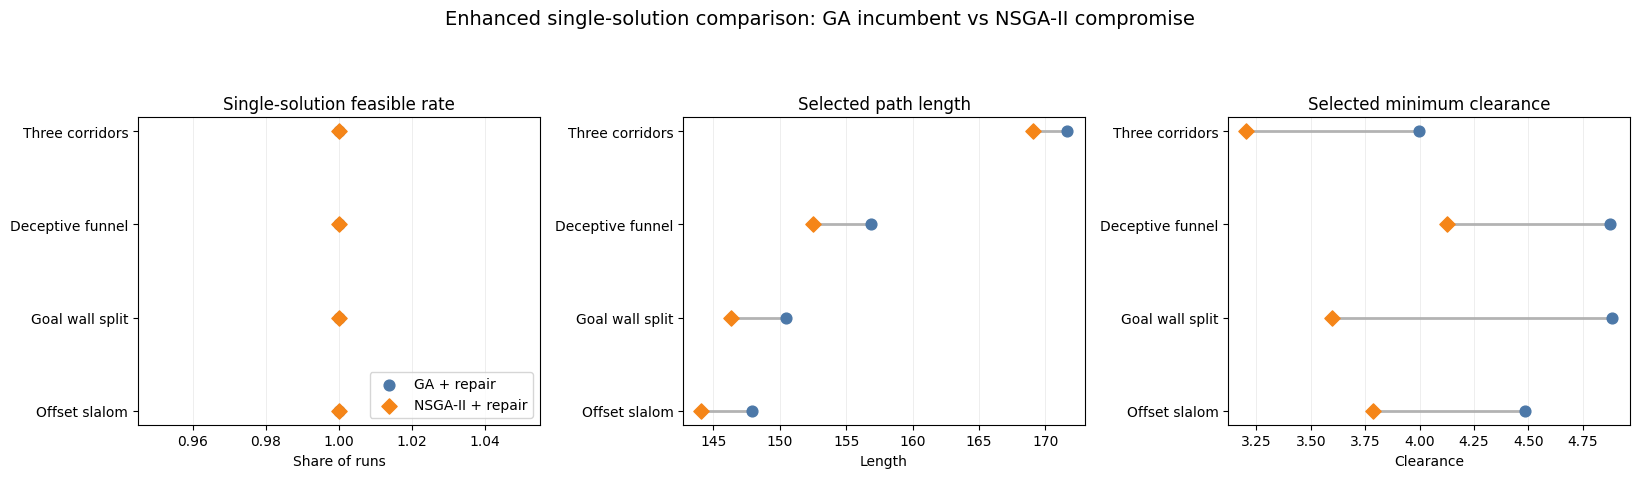

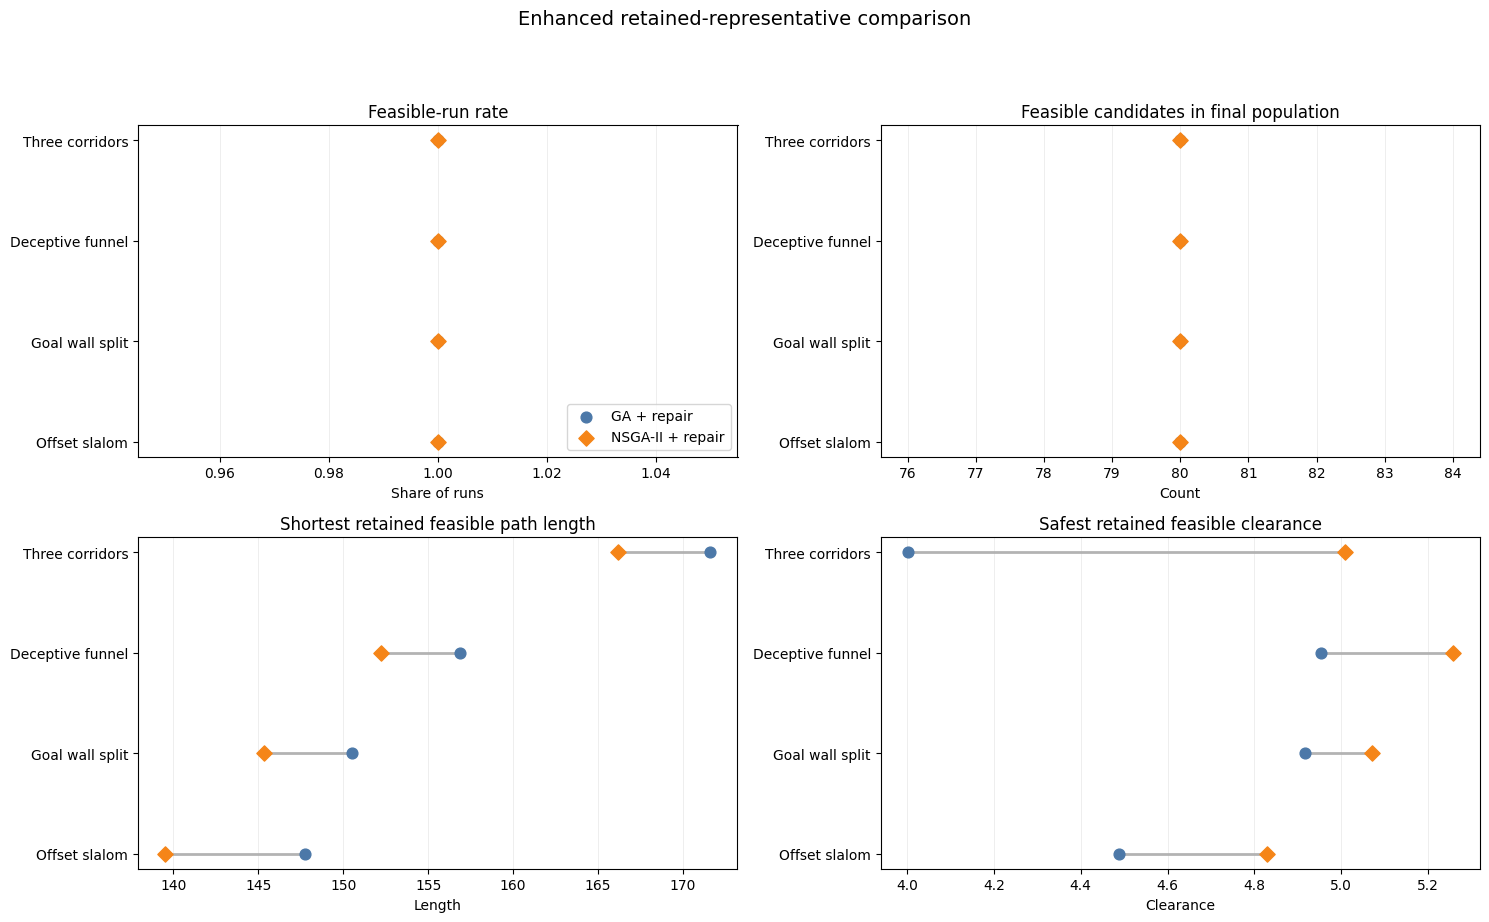

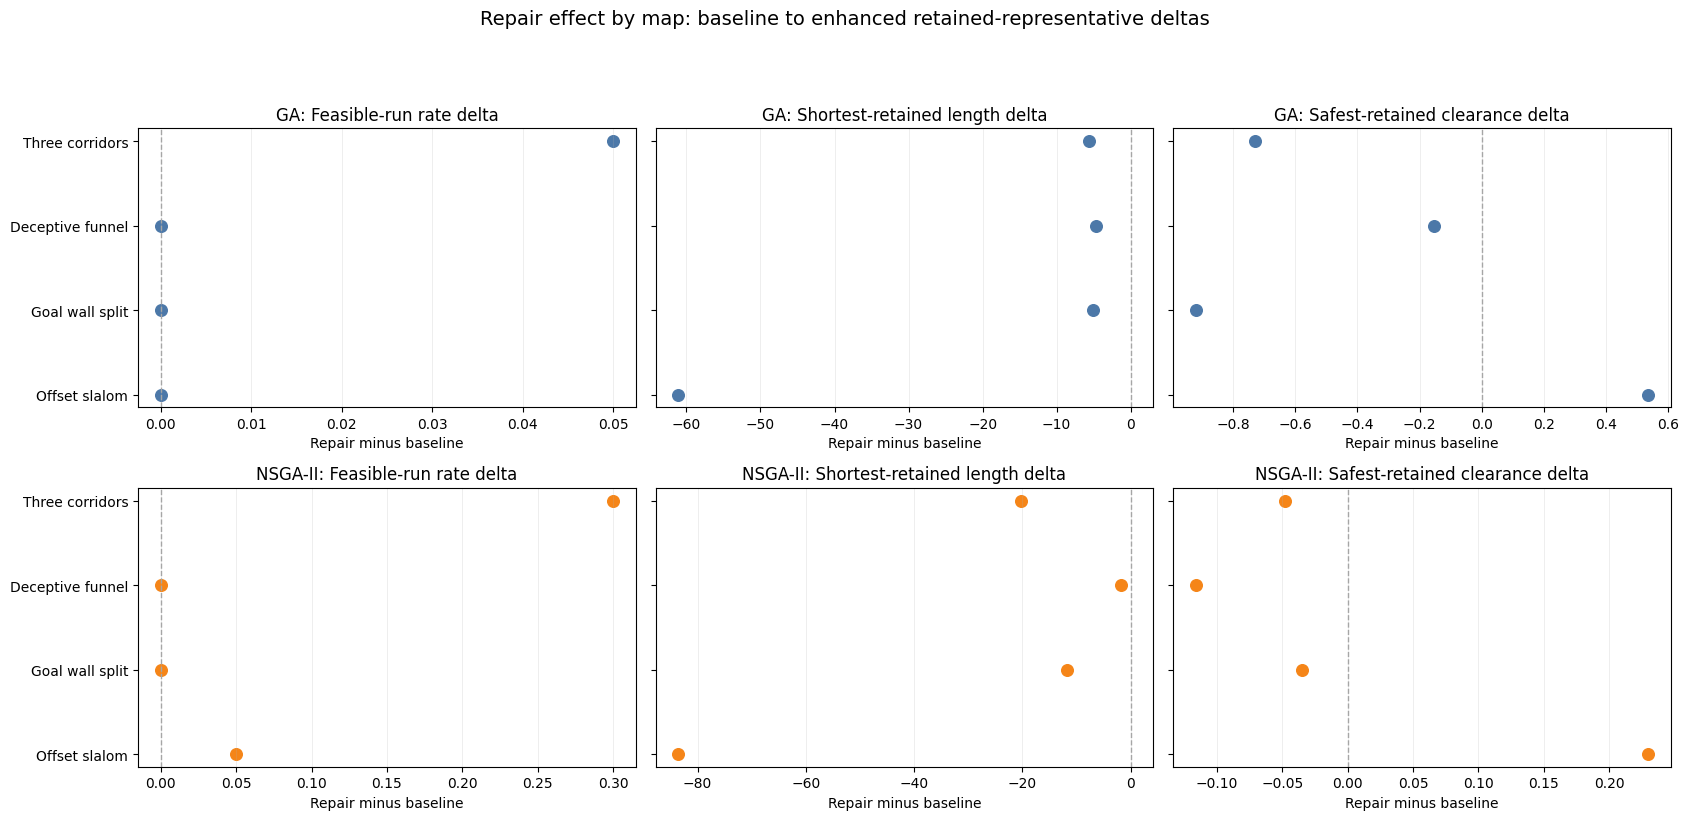

,condition,selected_feasible_rate,median_selected_length,q1_selected_length,q3_selected_length,median_selected_danger_penalty,q1_selected_danger_penalty,q3_selected_danger_penalty,median_selected_clearance,q1_selected_clearance,q3_selected_clearance,dominant_selected_corridor_signature
0,GA + repair,1.0,153.947052,146.836663,171.536067,0.006260,0.000464,0.042056,4.657542,4.083241,4.898388,x24:above|x36:above|x68:above|x80:above
1,NSGA-II + repair,1.0,149.441123,142.891641,159.205268,0.096076,0.026725,0.153198,3.566173,3.234813,4.252043,x24:above|x36:above|x68:above|x80:above


In [21]:
enhanced_single_summary = aggregate_selected_solution_summary(
    enhanced_single_solution_runs,
    ["map", "condition"],
).sort_values(["map", "condition"]).reset_index(drop=True)
enhanced_single_overall = aggregate_selected_solution_summary(
    enhanced_single_solution_runs,
    ["condition"],
).sort_values("condition").reset_index(drop=True)
enhanced_single_effect_table = paired_comparison_table(
    enhanced_single_solution_runs,
    "GA + repair",
    "NSGA-II + repair",
    SINGLE_SOLUTION_METRIC_SPECS,
)

enhanced_representative_summary = aggregate_condition_summary(
    enhanced_runs,
    ["map", "condition"],
).sort_values(["map", "condition"]).reset_index(drop=True)
enhanced_representative_overall = aggregate_condition_summary(
    enhanced_runs,
    ["condition"],
).sort_values("condition").reset_index(drop=True)
enhanced_representative_effect_table = paired_comparison_table(
    enhanced_runs,
    "GA + repair",
    "NSGA-II + repair",
    REPRESENTATIVE_METRIC_SPECS,
)

repair_effect_table = pd.concat(
    [
        paired_comparison_table(
            benchmark_runs.loc[benchmark_runs["algorithm"] == "GA"],
            "GA baseline",
            "GA + repair",
            REPRESENTATIVE_METRIC_SPECS,
        ).assign(algorithm="GA"),
        paired_comparison_table(
            benchmark_runs.loc[benchmark_runs["algorithm"] == "NSGA-II"],
            "NSGA-II baseline",
            "NSGA-II + repair",
            REPRESENTATIVE_METRIC_SPECS,
        ).assign(algorithm="NSGA-II"),
    ],
    ignore_index=True,
)


def repair_delta_by_map(run_df: pd.DataFrame, algorithm_name: str, metric: str, reducer: str) -> pd.Series:
    subset = run_df.loc[run_df["algorithm"] == algorithm_name].copy()
    aligned = subset.pivot_table(index=["map", "seed"], columns="repair", values=metric)
    delta = aligned["SegmentAwareRepair"] - aligned["No repair"]
    if reducer == "mean":
        return delta.groupby(level="map").mean()
    return delta.groupby(level="map").median()


repair_delta_summary = []
for algorithm_name in ["GA", "NSGA-II"]:
    for metric, reducer in [
        ("has_feasible", "mean"),
        ("shortest_feasible_length", "median"),
        ("safest_feasible_min_clearance", "median"),
    ]:
        delta_series = repair_delta_by_map(benchmark_runs, algorithm_name, metric, reducer)
        for map_name, value in delta_series.items():
            repair_delta_summary.append(
                {
                    "algorithm": algorithm_name,
                    "map": map_name,
                    "metric": metric,
                    "delta_repair_minus_baseline": float(value),
                }
            )
repair_delta_summary = pd.DataFrame(repair_delta_summary)

print("Enhanced single-solution summary by map")
print(
    enhanced_single_summary[
        [
            "map",
            "condition",
            "selected_feasible_rate",
            "median_selected_length",
            "median_selected_danger_penalty",
            "median_selected_clearance",
        ]
    ].to_string(index=False)
)
print()
print("Enhanced single-solution overall")
print(
    enhanced_single_overall[
        [
            "condition",
            "selected_feasible_rate",
            "median_selected_length",
            "median_selected_danger_penalty",
            "median_selected_clearance",
        ]
    ].to_string(index=False)
)
print()
print("Enhanced direct paired effects: NSGA-II compromise candidate minus GA incumbent")
print(
    enhanced_single_effect_table[
        [
            "metric",
            "n_pairs",
            "median_difference",
            "ci_low",
            "ci_high",
            "wilcoxon_p",
            "rank_biserial",
            "effect_note",
            "operational_note",
        ]
    ].to_string(index=False)
)
print()
print("Enhanced direct comparison in plain language")
for sentence in comparison_sentences(enhanced_single_effect_table):
    print(f"- {sentence}")
print()
print("Enhanced retained-representative summary by map")
print(
    enhanced_representative_summary[
        [
            "map",
            "condition",
            "feasible_run_rate",
            "median_feasible_count",
            "median_shortest_feasible_length",
            "median_safest_clearance",
        ]
    ].to_string(index=False)
)
print()
print("Enhanced retained-representative overall")
print(
    enhanced_representative_overall[
        [
            "condition",
            "feasible_run_rate",
            "median_feasible_count",
            "median_shortest_feasible_length",
            "median_safest_clearance",
        ]
    ].to_string(index=False)
)
print()
print("Enhanced retained-representative paired effects")
print(
    enhanced_representative_effect_table[
        [
            "metric",
            "n_pairs",
            "median_difference",
            "ci_low",
            "ci_high",
            "wilcoxon_p",
            "rank_biserial",
            "effect_note",
            "operational_note",
        ]
    ].to_string(index=False)
)
print()
print("Enhanced retained-representative comparison in plain language")
for sentence in comparison_sentences(enhanced_representative_effect_table):
    print(f"- {sentence}")
print()
print("Repair effects by algorithm")
print(
    repair_effect_table[
        [
            "algorithm",
            "metric",
            "median_difference",
            "ci_low",
            "ci_high",
            "wilcoxon_p",
            "rank_biserial",
            "effect_note",
            "operational_note",
        ]
    ].to_string(index=False)
)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
enhanced_single_metric_specs = [
    ("selected_feasible_rate", "Single-solution feasible rate", "Share of runs"),
    ("median_selected_length", "Selected path length", "Length"),
    ("median_selected_clearance", "Selected minimum clearance", "Clearance"),
]
for ax, (metric, title, xlabel) in zip(axes.flat, enhanced_single_metric_specs):
    plot_condition_dumbbell(ax, enhanced_single_summary, "GA + repair", "NSGA-II + repair", metric, title, xlabel)
axes[0].legend(loc="lower right")
fig.suptitle("Enhanced single-solution comparison: GA incumbent vs NSGA-II compromise", fontsize=14, y=1.03)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
enhanced_representative_metric_specs = [
    ("feasible_run_rate", "Feasible-run rate", "Share of runs"),
    ("median_feasible_count", "Feasible candidates in final population", "Count"),
    ("median_shortest_feasible_length", "Shortest retained feasible path length", "Length"),
    ("median_safest_clearance", "Safest retained feasible clearance", "Clearance"),
]
for ax, (metric, title, xlabel) in zip(axes.flat, enhanced_representative_metric_specs):
    plot_condition_dumbbell(ax, enhanced_representative_summary, "GA + repair", "NSGA-II + repair", metric, title, xlabel)
axes[0, 0].legend(loc="lower right")
fig.suptitle("Enhanced retained-representative comparison", fontsize=14, y=1.02)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(17, 8), sharey="row")
delta_metric_specs = [
    ("has_feasible", "Feasible-run rate delta", "Repair minus baseline"),
    ("shortest_feasible_length", "Shortest-retained length delta", "Repair minus baseline"),
    ("safest_feasible_min_clearance", "Safest-retained clearance delta", "Repair minus baseline"),
]
ordered_maps = list(benchmark_map_suite.keys())
for row, algorithm_name in enumerate(["GA", "NSGA-II"]):
    for col, (metric, title, xlabel) in enumerate(delta_metric_specs):
        ax = axes[row, col]
        subset = repair_delta_summary.loc[
            (repair_delta_summary["algorithm"] == algorithm_name) & (repair_delta_summary["metric"] == metric)
        ].set_index("map").reindex(ordered_maps)
        values = subset["delta_repair_minus_baseline"].to_numpy(dtype=float)
        y_positions = np.arange(len(ordered_maps))
        ax.axvline(0.0, color="0.65", linestyle="--", linewidth=1)
        ax.scatter(values, y_positions, color="#4c78a8" if algorithm_name == "GA" else "#f58518", s=70)
        ax.set_yticks(y_positions)
        ax.set_yticklabels(ordered_maps)
        ax.invert_yaxis()
        ax.set_title(f"{algorithm_name}: {title}")
        ax.set_xlabel(xlabel)
        ax.grid(alpha=0.3, axis="x")

fig.suptitle("Repair effect by map: baseline to enhanced retained-representative deltas", fontsize=14, y=1.02)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

enhanced_single_overall

### Enhanced interpretation

With the shared repair operator, the most defensible first question is the direct **single-solution** one: **GA incumbent versus NSGA-II compromise candidate under the same repaired protocol**. That is the primary apples-to-apples comparison when the user must choose one path at the end of the run.

The repaired direct comparison is mixed rather than universally one-sided. On this suite, the NSGA-II compromise can be shorter, while the GA incumbent can retain lower danger penalty or higher selected clearance. The retained-representative summaries answer a broader but different question: how strong are the trade-offs that remain available after repair?

The enhanced comparison therefore supports three careful claims:

- the shared repair operator mainly improves robustness and geometric feasibility handling for both methods
- the direct single-solution evidence is mixed rather than proving a universal winner
- NSGA-II is stronger in the retained-representative view by preserving useful trade-offs and surfacing strong representatives across objectives


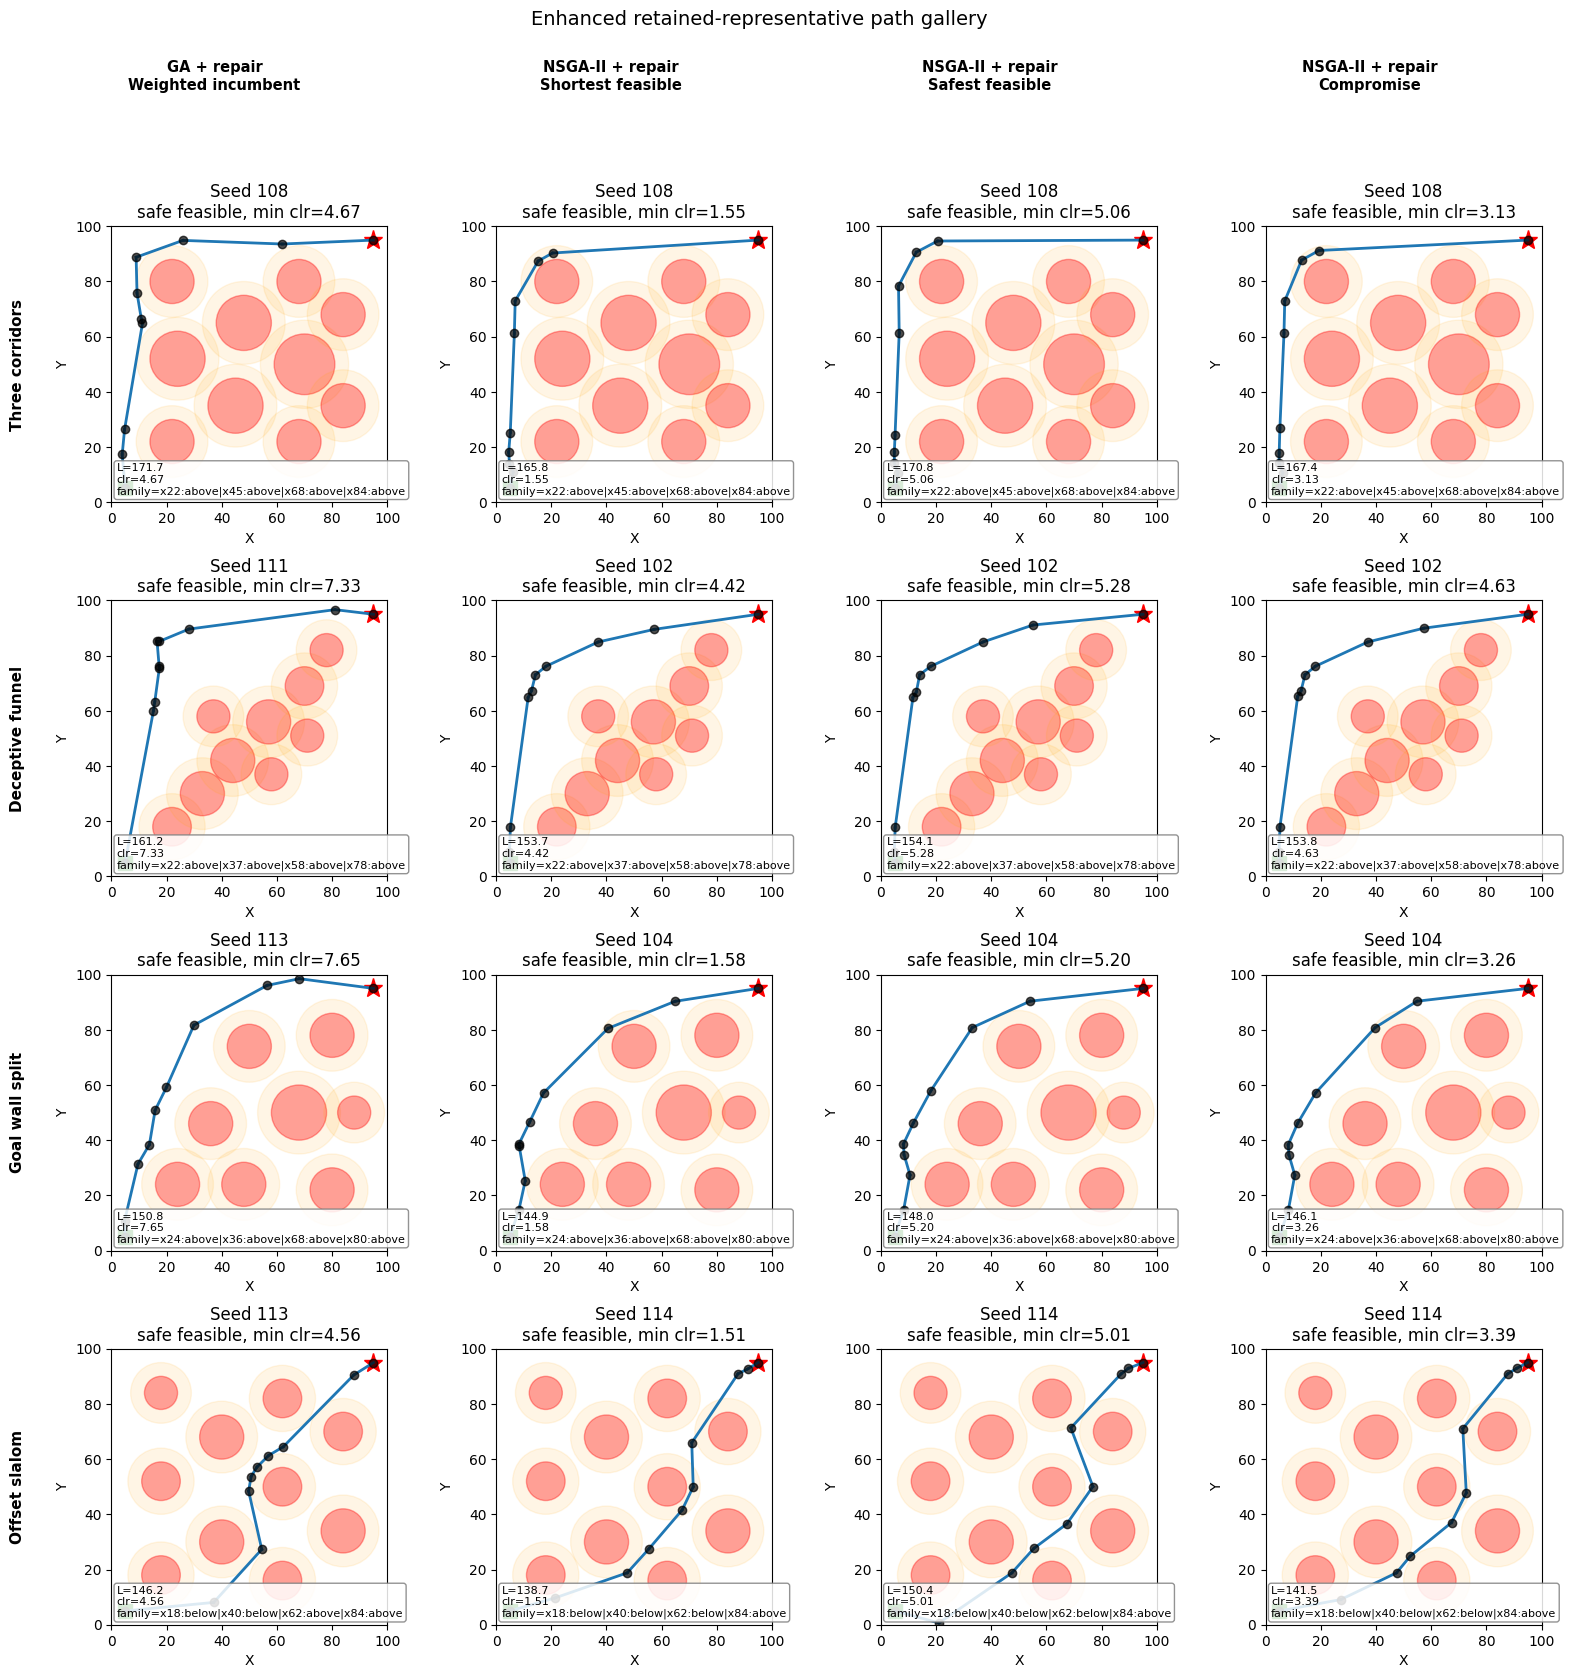

In [22]:
plot_comparison_gallery(enhanced_runs, "Enhanced")

**Figure note.** Enhanced retained-representative gallery. The layout matches the baseline gallery so that changes in representative-path behavior can be read column by column. The primary direct comparison remains the GA-incumbent-versus-NSGA-II-compromise tables above.


## 9. Optional exploratory analyses

The analyses below are deliberately secondary. They are used to calibrate the fixed-budget interpretation, test modest representation sensitivity, and provide an exploratory corridor-usage heuristic without changing the core protocol.

They are kept secondary for two reasons:

- the primary claims come from the 80-generation benchmark suite in Sections 7 and 8
- these checks use compact subsets or heuristic summaries, so they clarify scope and sensitivity but do not replace the main benchmark evidence


### Fixed-budget sensitivity check

The main benchmark remains fixed at 80 generations. The compact subset analysis below is used to judge whether that choice should be described as a **fixed-budget anytime** comparison rather than as evidence of asymptotic quality.

To keep runtime bounded, the check uses only a subset of the benchmark suite rather than a full rerun of every map and seed.


Fixed-budget sensitivity subset
                               maps  n_maps     evaluation_seeds  n_eval_seeds budget_n_gen_values
(Three corridors, Deceptive funnel)       2 (100, 101, 102, 103)             4       (40, 80, 120)

Budget sensitivity: selected-solution overall summary
 budget_n_gen        condition  selected_feasible_rate  median_selected_length  median_selected_clearance
           40      GA + repair                   1.000              172.813429                   4.941440
           40      GA baseline                   1.000              211.110383                   4.477988
           40 NSGA-II + repair                   1.000              166.935227                   3.786012
           40 NSGA-II baseline                   0.875              184.522486                   3.784409
           80      GA + repair                   1.000              165.305730                   4.740799
           80      GA baseline                   1.000              194.468864 

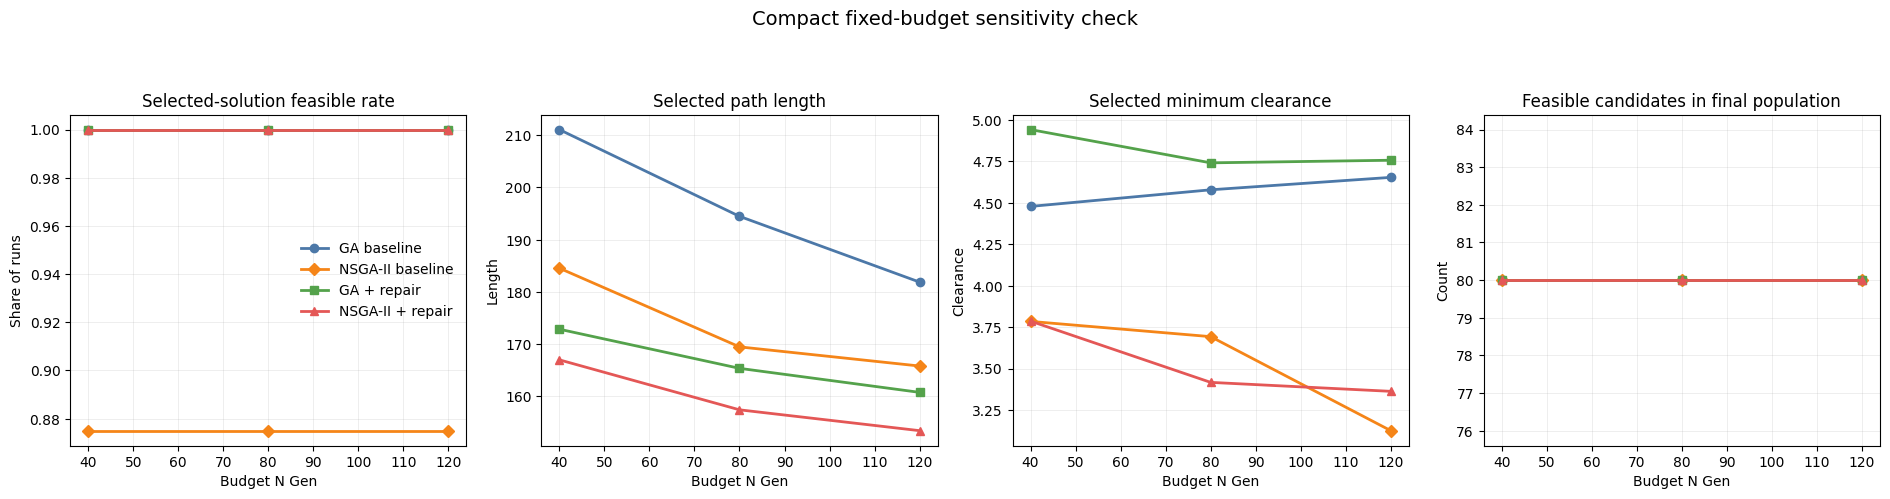

,budget_n_gen,condition,selected_feasible_rate,median_selected_length,q1_selected_length,q3_selected_length,median_selected_danger_penalty,q1_selected_danger_penalty,q3_selected_danger_penalty,median_selected_clearance,q1_selected_clearance,q3_selected_clearance,dominant_selected_corridor_signature
0,40,GA + repair,1.000,172.813429,164.754653,191.675350,0.001421,0.000000,0.006004,4.941440,4.658838,5.631634,x22:above|x37:above|x58:above|x78:above
1,40,GA baseline,1.000,211.110383,178.871238,289.323463,0.014851,0.000000,0.024929,4.477988,4.281769,5.663960,x22:above|x37:above|x58:above|x78:above
2,40,NSGA-II + repair,1.000,166.935227,155.046120,170.660085,0.065850,0.002502,0.122112,3.786012,3.498624,4.787282,x22:above|x45:above|x68:above|x84:above
3,40,NSGA-II baseline,0.875,184.522486,168.129964,248.113332,0.070575,0.003209,0.261494,3.784409,2.744873,4.777910,x22:above|x37:above|x58:above|x78:above
4,80,GA + repair,1.000,165.305730,157.533482,172.316557,0.003228,0.000712,0.005486,4.740799,4.662550,4.888408,x22:above|x37:above|x58:above|x78:above
5,80,GA baseline,1.000,194.468864,169.637481,270.189113,0.009104,0.000679,0.016988,4.578237,4.416184,4.999790,x22:above|x37:above|x58:above|x78:above
6,80,NSGA-II + repair,1.000,157.348032,147.976634,166.354018,0.116286,0.041575,0.144192,3.416598,3.282852,4.122658,x22:above|x45:above|x68:above|x84:above
7,80,NSGA-II baseline,0.875,169.426118,163.403193,237.843969,0.082419,0.001329,0.203425,3.692389,3.075959,4.966984,x22:above|x37:above|x58:above|x78:above
8,120,GA + repair,1.000,160.696258,146.342851,171.331244,0.003152,0.001739,0.005039,4.756567,4.673028,4.810323,x22:above|x37:above|x58:above|x78:above
9,120,GA baseline,1.000,181.849016,165.043458,257.373779,0.006093,0.000859,0.025259,4.653171,4.313305,4.908530,x22:above|x37:above|x58:above|x78:above


In [23]:
BUDGET_ANALYSIS_MAPS = ("Three corridors", "Deceptive funnel")
BUDGET_ANALYSIS_SEEDS = tuple(EVALUATION_SEEDS[:4])
BUDGET_ANALYSIS_BUDGETS = (40, 80, 120)


def compute_budget_sensitivity_artifact() -> dict[str, pd.DataFrame]:
    subset_maps = {name: benchmark_map_suite[name] for name in BUDGET_ANALYSIS_MAPS}
    run_frames = []
    selected_frames = []

    for budget_n_gen in BUDGET_ANALYSIS_BUDGETS:
        budget_specs = condition_specs_with_generation_budget(CONDITION_SPECS, n_gen=budget_n_gen)
        run_df, _, selected_df = run_condition_suite(
            subset_maps,
            BUDGET_ANALYSIS_SEEDS,
            budget_specs,
            collect_population=False,
        )
        function_evaluations = int(EXPERIMENT_CONFIG.common_protocol.pop_size) * int(budget_n_gen)
        run_frames.append(run_df.assign(budget_n_gen=int(budget_n_gen), function_evaluations=function_evaluations))
        selected_frames.append(selected_df.assign(budget_n_gen=int(budget_n_gen), function_evaluations=function_evaluations))

    return {
        "budget_runs": pd.concat(run_frames, ignore_index=True),
        "budget_selected_runs": pd.concat(selected_frames, ignore_index=True),
    }


budget_definition = {
    "artifact": "budget_sensitivity_subset",
    "resolved_profile": RESOLVED_PROFILE_PAYLOAD,
    "map_subset": list(BUDGET_ANALYSIS_MAPS),
    "evaluation_seeds": list(BUDGET_ANALYSIS_SEEDS),
    "budget_n_gen_values": list(BUDGET_ANALYSIS_BUDGETS),
}
budget_fingerprint = stable_fingerprint(budget_definition)
budget_artifact, budget_cache_info = load_or_compute_cached_artifact(
    cache_policy=CACHE_POLICY,
    repo_root=REPO_ROOT,
    artifact_name="budget_sensitivity_subset",
    definition=budget_definition,
    fingerprint=budget_fingerprint,
    compute_fn=compute_budget_sensitivity_artifact,
)
budget_runs = budget_artifact["budget_runs"]
budget_selected_runs = budget_artifact["budget_selected_runs"]

budget_selected_overall = aggregate_selected_solution_summary(
    budget_selected_runs,
    ["budget_n_gen", "condition"],
).sort_values(["budget_n_gen", "condition"]).reset_index(drop=True)
budget_representative_overall = aggregate_condition_summary(
    budget_runs,
    ["budget_n_gen", "condition"],
).sort_values(["budget_n_gen", "condition"]).reset_index(drop=True)

budget_effect_rows = []
for budget_n_gen in BUDGET_ANALYSIS_BUDGETS:
    subset = budget_selected_runs.loc[budget_selected_runs["budget_n_gen"] == budget_n_gen]
    budget_effect_rows.append(
        paired_comparison_table(subset, "GA baseline", "NSGA-II baseline", SINGLE_SOLUTION_METRIC_SPECS)
        .assign(comparison_view="Baseline", budget_n_gen=budget_n_gen)
    )
    budget_effect_rows.append(
        paired_comparison_table(subset, "GA + repair", "NSGA-II + repair", SINGLE_SOLUTION_METRIC_SPECS)
        .assign(comparison_view="Enhanced", budget_n_gen=budget_n_gen)
    )
budget_effect_table = pd.concat(budget_effect_rows, ignore_index=True)

print("Fixed-budget sensitivity subset")
print(
    pd.DataFrame(
        [
            {
                "maps": BUDGET_ANALYSIS_MAPS,
                "n_maps": len(BUDGET_ANALYSIS_MAPS),
                "evaluation_seeds": BUDGET_ANALYSIS_SEEDS,
                "n_eval_seeds": len(BUDGET_ANALYSIS_SEEDS),
                "budget_n_gen_values": BUDGET_ANALYSIS_BUDGETS,
            }
        ]
    ).to_string(index=False)
)
print()
print("Budget sensitivity: selected-solution overall summary")
print(
    budget_selected_overall[
        [
            "budget_n_gen",
            "condition",
            "selected_feasible_rate",
            "median_selected_length",
            "median_selected_clearance",
        ]
    ].to_string(index=False)
)
print()
print("Budget sensitivity: retained-representative overall summary")
print(
    budget_representative_overall[
        [
            "budget_n_gen",
            "condition",
            "feasible_run_rate",
            "median_feasible_count",
            "median_shortest_feasible_length",
            "median_safest_clearance",
        ]
    ].to_string(index=False)
)
print()
print("Budget sensitivity: direct single-solution effects")
print(
    budget_effect_table.loc[
        budget_effect_table["metric"].isin(["Selected path length", "Selected minimum clearance", "Selected-solution feasible indicator"]),
        [
            "comparison_view",
            "budget_n_gen",
            "metric",
            "median_difference",
            "wilcoxon_p",
            "rank_biserial",
            "effect_note",
            "operational_note",
        ],
    ].to_string(index=False)
)
print()
print(
    f"Budget artifact: {budget_cache_info['status']} "
    f"({format_path_for_display(budget_cache_info['path'], REPO_ROOT)})"
)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.8))
plot_overall_metric_profiles(
    axes[0],
    budget_selected_overall,
    "budget_n_gen",
    "selected_feasible_rate",
    "Selected-solution feasible rate",
    "Share of runs",
)
plot_overall_metric_profiles(
    axes[1],
    budget_selected_overall,
    "budget_n_gen",
    "median_selected_length",
    "Selected path length",
    "Length",
)
plot_overall_metric_profiles(
    axes[2],
    budget_selected_overall,
    "budget_n_gen",
    "median_selected_clearance",
    "Selected minimum clearance",
    "Clearance",
)
plot_overall_metric_profiles(
    axes[3],
    budget_representative_overall,
    "budget_n_gen",
    "median_feasible_count",
    "Feasible candidates in final population",
    "Count",
)
axes[0].legend(loc="best", frameon=False)
fig.suptitle("Compact fixed-budget sensitivity check", fontsize=14, y=1.03)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

budget_selected_overall

**Interpretive note.** This subset check is used to calibrate the language around the 80-generation protocol. It does not prove full convergence. The safer interpretation is therefore that the benchmark shows **fixed-budget anytime behavior** on this study design, with extra budget checks included only as supporting context.

### Waypoint-count sensitivity

The main benchmark uses `n_waypoints = 8`, but that choice should be justified rather than treated as self-evident. The compact subset analysis below repeats part of the study with `n_waypoints = 6`, `8`, and `10`.

To avoid a confound, the GA risk weight is re-tuned on the development map for each waypoint count before the subset evaluation is run.


Waypoint sensitivity subset
                               maps  n_maps tuning_seeds  n_tuning_seeds evaluation_seeds  n_eval_seeds tested_n_waypoints
(Three corridors, Deceptive funnel)       2    (0, 1, 2)               3       (100, 101)             2         (6, 8, 10)

Waypoint sensitivity: GA retuning by waypoint count
 tested_n_waypoints tuning_seeds  selected_ga_weight       tuning_artifact tuning_fingerprint benchmark_fingerprint
                  6    (0, 1, 2)               120.0 recomputed-and-cached       069933a20da6          59af3db3ce48
                  8    (0, 1, 2)                80.0 recomputed-and-cached       d59df7bbb2bd          14c9e3ad5de0
                 10    (0, 1, 2)               160.0 recomputed-and-cached       537cf6980ba1          d2515a46601b

Waypoint sensitivity: selected-solution overall summary
 tested_n_waypoints        condition  selected_feasible_rate  median_selected_length  median_selected_clearance
                  6      GA + repair    

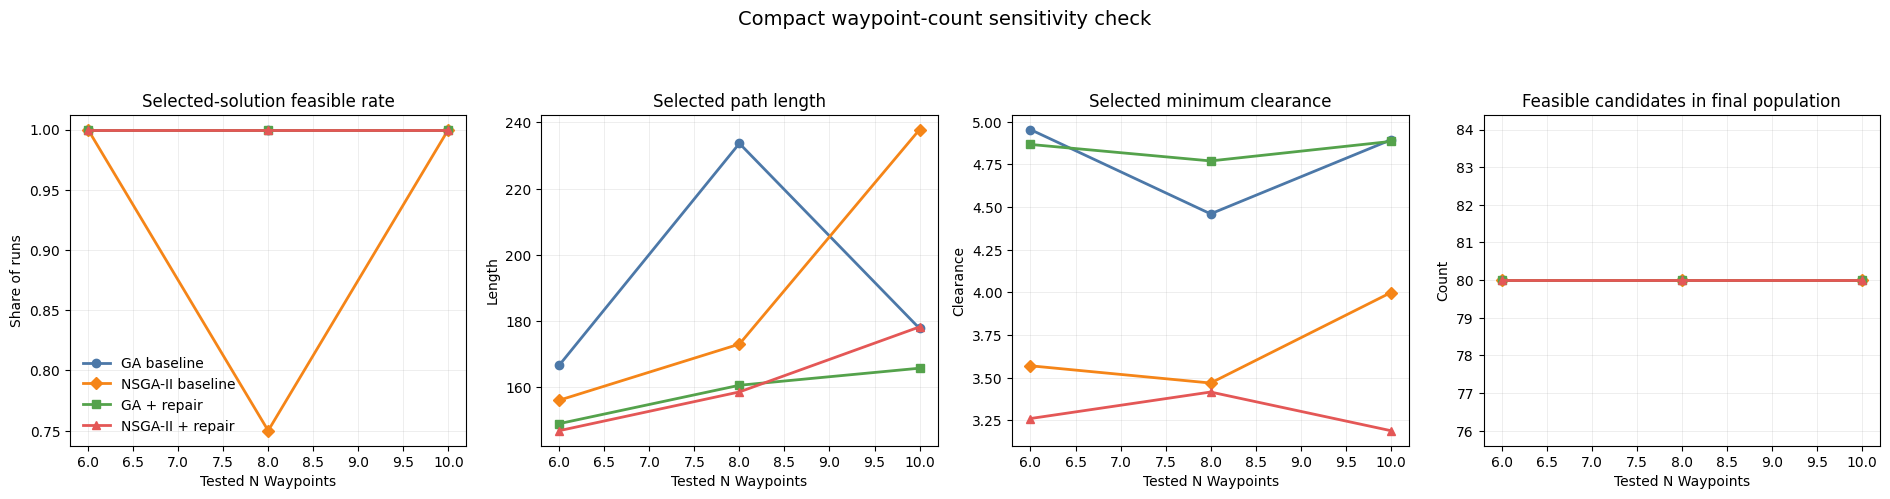

,tested_n_waypoints,condition,selected_feasible_rate,median_selected_length,q1_selected_length,q3_selected_length,median_selected_danger_penalty,q1_selected_danger_penalty,q3_selected_danger_penalty,median_selected_clearance,q1_selected_clearance,q3_selected_clearance,dominant_selected_corridor_signature
0,6,GA + repair,1.00,149.075445,141.857889,160.364717,0.000938,0.000337,0.128146,4.867042,4.096577,4.922203,x22:below|x37:below|x58:below|x78:below
1,6,GA baseline,1.00,166.728893,158.351351,182.329821,0.000937,0.000000,0.006026,4.954106,4.709007,5.386063,x22:above|x45:above|x68:above|x84:above
2,6,NSGA-II + repair,1.00,146.954802,142.698625,150.093319,0.153319,0.105337,0.200574,3.261348,2.956869,3.558326,x22:above|x45:above|x68:above|x84:above
3,6,NSGA-II baseline,1.00,156.150189,147.248702,165.447863,0.103937,0.068528,0.132281,3.570301,3.332680,4.128726,x22:above|x37:above|x58:above|x78:above
4,8,GA + repair,1.00,160.657088,145.987368,175.309027,0.002649,0.000712,0.080310,4.770512,4.155631,4.906205,x22:above|x37:above|x58:above|x78:above
5,8,GA baseline,1.00,233.644630,186.899949,274.937190,0.013867,0.009739,0.023559,4.460392,4.337577,4.706081,x22:above|x37:above|x58:above|x78:above
6,8,NSGA-II + repair,1.00,158.647618,145.063147,172.840913,0.116286,0.098102,0.124965,3.416598,3.340721,3.593710,x22:below|x37:below|x58:below|x78:below
7,8,NSGA-II baseline,0.75,173.082077,163.343141,237.843969,0.108020,0.080171,0.557770,3.469291,2.226303,3.813926,x22:above|x37:above|x58:above|x78:above
8,10,GA + repair,1.00,165.808772,159.945232,192.106897,0.000687,0.000177,0.116693,4.884693,4.105779,5.028518,x22:below|x37:below|x58:below|x78:below
9,10,GA baseline,1.00,177.794060,154.835900,220.682166,0.000674,0.000057,0.006810,4.893722,4.699696,5.158604,x22:above|x37:above|x58:above|x78:above


In [24]:
WAYPOINT_ANALYSIS_MAPS = ("Three corridors", "Deceptive funnel")
WAYPOINT_ANALYSIS_SEEDS = tuple(EVALUATION_SEEDS[:2])
WAYPOINT_TUNING_SEEDS = tuple(EXPERIMENT_CONFIG.tuning_seeds[:3])
WAYPOINT_ANALYSIS_COUNTS = (6, 8, 10)


def compute_waypoint_sensitivity_artifact() -> dict[str, pd.DataFrame]:
    tuning_rows = []
    run_frames = []
    selected_frames = []

    for tested_n_waypoints in WAYPOINT_ANALYSIS_COUNTS:
        exploratory_experiment = replace(
            experiment_config_with_waypoint_count(EXPERIMENT_CONFIG, tested_n_waypoints),
            tuning_seeds=WAYPOINT_TUNING_SEEDS,
        )
        exploratory_map_suite = build_map_suite(exploratory_experiment)
        exploratory_subset_maps = {name: exploratory_map_suite[name] for name in WAYPOINT_ANALYSIS_MAPS}
        exploratory_profile, exploratory_tuning_summary, exploratory_tuning_cache_info, exploratory_payload = resolve_experiment_profile(
            exploratory_experiment,
            CACHE_POLICY,
            REPO_ROOT,
        )
        exploratory_specs = condition_specs_from_profiles(exploratory_profile.condition_profiles)
        run_df, _, selected_df = run_condition_suite(
            exploratory_subset_maps,
            WAYPOINT_ANALYSIS_SEEDS,
            exploratory_specs,
            collect_population=False,
        )

        tuning_rows.append(
            {
                "tested_n_waypoints": int(tested_n_waypoints),
                "tuning_seeds": WAYPOINT_TUNING_SEEDS,
                "selected_ga_weight": float(exploratory_profile.selected_ga_weight),
                "tuning_artifact": exploratory_tuning_cache_info["status"],
                "tuning_fingerprint": exploratory_profile.tuning_fingerprint[:12],
                "benchmark_fingerprint": exploratory_profile.benchmark_fingerprint[:12],
            }
        )
        run_frames.append(
            run_df.assign(
                tested_n_waypoints=int(tested_n_waypoints),
                selected_ga_weight=float(exploratory_profile.selected_ga_weight),
            )
        )
        selected_frames.append(
            selected_df.assign(
                tested_n_waypoints=int(tested_n_waypoints),
                selected_ga_weight=float(exploratory_profile.selected_ga_weight),
            )
        )

    return {
        "waypoint_tuning": pd.DataFrame(tuning_rows),
        "waypoint_runs": pd.concat(run_frames, ignore_index=True),
        "waypoint_selected_runs": pd.concat(selected_frames, ignore_index=True),
    }


waypoint_definition = {
    "artifact": "waypoint_sensitivity_subset",
    "base_experiment": experiment_definition_payload(EXPERIMENT_CONFIG),
    "map_subset": list(WAYPOINT_ANALYSIS_MAPS),
    "evaluation_seeds": list(WAYPOINT_ANALYSIS_SEEDS),
    "tuning_seeds": list(WAYPOINT_TUNING_SEEDS),
    "tested_n_waypoints": list(WAYPOINT_ANALYSIS_COUNTS),
}
waypoint_fingerprint = stable_fingerprint(waypoint_definition)
waypoint_artifact, waypoint_cache_info = load_or_compute_cached_artifact(
    cache_policy=CACHE_POLICY,
    repo_root=REPO_ROOT,
    artifact_name="waypoint_sensitivity_subset",
    definition=waypoint_definition,
    fingerprint=waypoint_fingerprint,
    compute_fn=compute_waypoint_sensitivity_artifact,
)
waypoint_tuning = waypoint_artifact["waypoint_tuning"]
waypoint_runs = waypoint_artifact["waypoint_runs"]
waypoint_selected_runs = waypoint_artifact["waypoint_selected_runs"]

waypoint_selected_overall = aggregate_selected_solution_summary(
    waypoint_selected_runs,
    ["tested_n_waypoints", "condition"],
).sort_values(["tested_n_waypoints", "condition"]).reset_index(drop=True)
waypoint_representative_overall = aggregate_condition_summary(
    waypoint_runs,
    ["tested_n_waypoints", "condition"],
).sort_values(["tested_n_waypoints", "condition"]).reset_index(drop=True)

waypoint_effect_rows = []
for tested_n_waypoints in WAYPOINT_ANALYSIS_COUNTS:
    subset = waypoint_selected_runs.loc[waypoint_selected_runs["tested_n_waypoints"] == tested_n_waypoints]
    waypoint_effect_rows.append(
        paired_comparison_table(subset, "GA baseline", "NSGA-II baseline", SINGLE_SOLUTION_METRIC_SPECS)
        .assign(comparison_view="Baseline", tested_n_waypoints=tested_n_waypoints)
    )
    waypoint_effect_rows.append(
        paired_comparison_table(subset, "GA + repair", "NSGA-II + repair", SINGLE_SOLUTION_METRIC_SPECS)
        .assign(comparison_view="Enhanced", tested_n_waypoints=tested_n_waypoints)
    )
waypoint_effect_table = pd.concat(waypoint_effect_rows, ignore_index=True)

print("Waypoint sensitivity subset")
print(
    pd.DataFrame(
        [
            {
                "maps": WAYPOINT_ANALYSIS_MAPS,
                "n_maps": len(WAYPOINT_ANALYSIS_MAPS),
                "tuning_seeds": WAYPOINT_TUNING_SEEDS,
                "n_tuning_seeds": len(WAYPOINT_TUNING_SEEDS),
                "evaluation_seeds": WAYPOINT_ANALYSIS_SEEDS,
                "n_eval_seeds": len(WAYPOINT_ANALYSIS_SEEDS),
                "tested_n_waypoints": WAYPOINT_ANALYSIS_COUNTS,
            }
        ]
    ).to_string(index=False)
)
print()
print("Waypoint sensitivity: GA retuning by waypoint count")
print(waypoint_tuning.to_string(index=False))
print()
print("Waypoint sensitivity: selected-solution overall summary")
print(
    waypoint_selected_overall[
        [
            "tested_n_waypoints",
            "condition",
            "selected_feasible_rate",
            "median_selected_length",
            "median_selected_clearance",
        ]
    ].to_string(index=False)
)
print()
print("Waypoint sensitivity: retained-representative overall summary")
print(
    waypoint_representative_overall[
        [
            "tested_n_waypoints",
            "condition",
            "feasible_run_rate",
            "median_feasible_count",
            "median_shortest_feasible_length",
            "median_safest_clearance",
        ]
    ].to_string(index=False)
)
print()
print("Waypoint sensitivity: direct single-solution effects")
print(
    waypoint_effect_table.loc[
        waypoint_effect_table["metric"].isin(["Selected path length", "Selected minimum clearance", "Selected-solution feasible indicator"]),
        [
            "comparison_view",
            "tested_n_waypoints",
            "metric",
            "median_difference",
            "wilcoxon_p",
            "rank_biserial",
            "effect_note",
            "operational_note",
        ],
    ].to_string(index=False)
)
print()
print(
    f"Waypoint artifact: {waypoint_cache_info['status']} "
    f"({format_path_for_display(waypoint_cache_info['path'], REPO_ROOT)})"
)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.8))
plot_overall_metric_profiles(
    axes[0],
    waypoint_selected_overall,
    "tested_n_waypoints",
    "selected_feasible_rate",
    "Selected-solution feasible rate",
    "Share of runs",
)
plot_overall_metric_profiles(
    axes[1],
    waypoint_selected_overall,
    "tested_n_waypoints",
    "median_selected_length",
    "Selected path length",
    "Length",
)
plot_overall_metric_profiles(
    axes[2],
    waypoint_selected_overall,
    "tested_n_waypoints",
    "median_selected_clearance",
    "Selected minimum clearance",
    "Clearance",
)
plot_overall_metric_profiles(
    axes[3],
    waypoint_representative_overall,
    "tested_n_waypoints",
    "median_feasible_count",
    "Feasible candidates in final population",
    "Count",
)
axes[0].legend(loc="best", frameon=False)
fig.suptitle("Compact waypoint-count sensitivity check", fontsize=14, y=1.03)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

waypoint_selected_overall

**Interpretive note.** This subset study is meant to test whether `n_waypoints = 8` is a defensible practical setting, not to claim that one waypoint count is globally optimal. The correct reading is sensitivity-oriented: if conclusions survive modest changes in representation complexity, they are more credible; if they move, that movement should be reported openly.

### Corridor-signature heuristic

Diversity is treated cautiously here. Each feasible path receives an **obstacle-aware corridor signature**.

At several fixed $x$ checkpoints, the code identifies a nearby landmark obstacle and records whether the path passes **above**, **below**, or through the obstacle's **centerline influence zone**. This yields signatures such as `x22:above|x48:below|x70:centerline`.

Corridor signatures are heuristic summaries rather than formal homotopy or topological classes. They are used only for exploratory interpretation of corridor usage and are kept secondary to the single-solution and retained-representative comparisons.


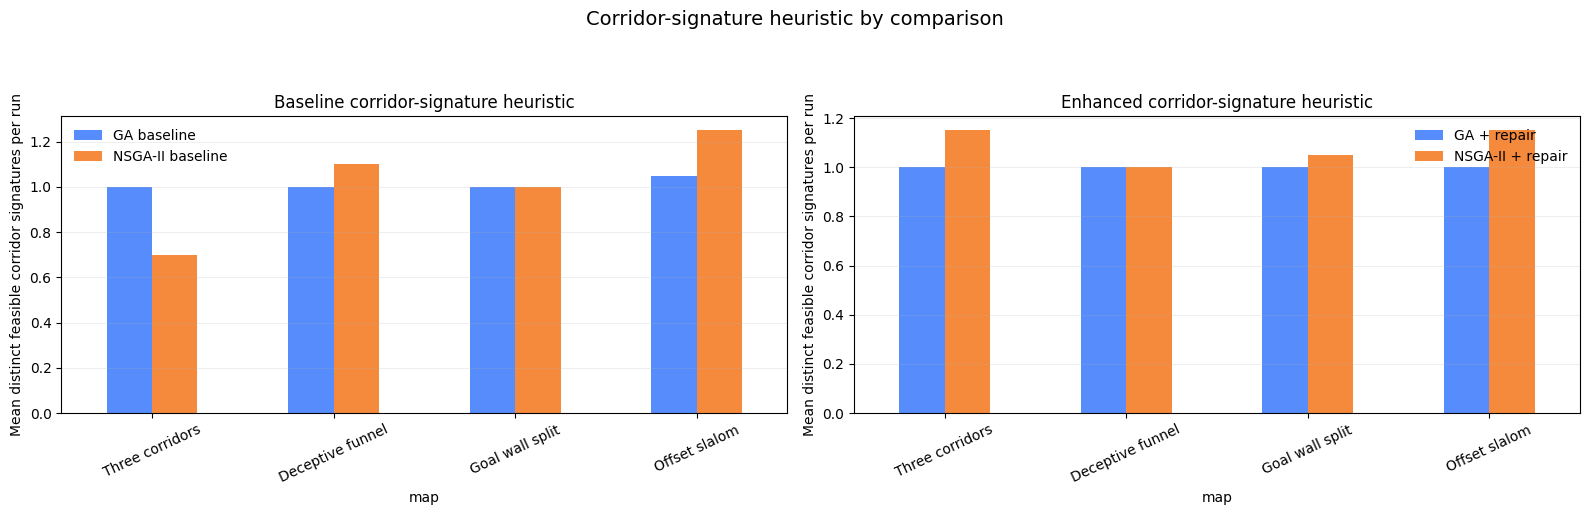

Corridor-signature summary
comparison        condition              map  mean_corridor_signature_count             dominant_shortest_signature               dominant_safest_signature
  Baseline      GA baseline Deceptive funnel                           1.00 x22:above|x37:above|x58:above|x78:above x22:above|x37:above|x58:above|x78:above
  Baseline NSGA-II baseline Deceptive funnel                           1.10 x22:above|x37:above|x58:above|x78:above x22:above|x37:above|x58:above|x78:above
  Baseline      GA baseline  Goal wall split                           1.00 x24:above|x36:above|x68:above|x80:above x24:above|x36:above|x68:above|x80:above
  Baseline NSGA-II baseline  Goal wall split                           1.00 x24:above|x36:above|x68:above|x80:above x24:above|x36:above|x68:above|x80:above
  Baseline      GA baseline    Offset slalom                           1.05 x18:above|x40:above|x62:above|x84:above x18:above|x40:above|x62:above|x84:above
  Baseline NSGA-II baseline    Offset

,comparison,condition,map,mean_corridor_signature_count,dominant_shortest_signature,dominant_safest_signature
0,Baseline,GA baseline,Deceptive funnel,1.00,x22:above|x37:above|x58:above|x78:above,x22:above|x37:above|x58:above|x78:above
1,Baseline,NSGA-II baseline,Deceptive funnel,1.10,x22:above|x37:above|x58:above|x78:above,x22:above|x37:above|x58:above|x78:above
2,Baseline,GA baseline,Goal wall split,1.00,x24:above|x36:above|x68:above|x80:above,x24:above|x36:above|x68:above|x80:above
3,Baseline,NSGA-II baseline,Goal wall split,1.00,x24:above|x36:above|x68:above|x80:above,x24:above|x36:above|x68:above|x80:above
4,Baseline,GA baseline,Offset slalom,1.05,x18:above|x40:above|x62:above|x84:above,x18:above|x40:above|x62:above|x84:above
5,Baseline,NSGA-II baseline,Offset slalom,1.25,x18:above|x40:above|x62:above|x84:above,x18:above|x40:above|x62:above|x84:above
6,Baseline,GA baseline,Three corridors,1.00,x22:above|x45:above|x68:above|x84:above,x22:above|x45:above|x68:above|x84:above
7,Baseline,NSGA-II baseline,Three corridors,0.70,none,none
8,Enhanced,GA + repair,Deceptive funnel,1.00,x22:above|x37:above|x58:above|x78:above,x22:above|x37:above|x58:above|x78:above
9,Enhanced,NSGA-II + repair,Deceptive funnel,1.00,x22:above|x37:above|x58:above|x78:above,x22:above|x37:above|x58:above|x78:above


In [25]:
corridor_summary = (
    benchmark_runs.groupby(["comparison", "condition", "map"], as_index=False)
    .agg(
        mean_corridor_signature_count=("feasible_route_family_count", "mean"),
        dominant_shortest_signature=("shortest_feasible_route_family", lambda s: s.mode().iat[0] if not s.mode().empty else "none"),
        dominant_safest_signature=("safest_feasible_route_family", lambda s: s.mode().iat[0] if not s.mode().empty else "none"),
    )
    .sort_values(["comparison", "map", "condition"])
    .reset_index(drop=True)
)

feasible_population = benchmark_population.loc[benchmark_population["feasible"]].copy()
top_corridor_signatures = (
    feasible_population.groupby(["condition", "route_family"])
    .size()
    .reset_index(name="candidate_count")
    .sort_values(["condition", "candidate_count", "route_family"], ascending=[True, False, True])
    .groupby("condition")
    .head(3)
    .reset_index(drop=True)
    .rename(columns={"route_family": "corridor_signature"})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, comparison_name in zip(axes, ["Baseline", "Enhanced"]):
    subset = corridor_summary.loc[corridor_summary["comparison"] == comparison_name]
    pivot = subset.pivot(index="map", columns="condition", values="mean_corridor_signature_count").loc[list(benchmark_map_suite.keys())]
    pivot.plot(kind="bar", ax=ax, rot=25)
    ax.set_title(f"{comparison_name} corridor-signature heuristic")
    ax.set_ylabel("Mean distinct feasible corridor signatures per run")
    ax.grid(alpha=0.3, axis="y")
    ax.legend(frameon=False)

fig.suptitle("Corridor-signature heuristic by comparison", fontsize=14, y=1.02)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

print("Corridor-signature summary")
print(corridor_summary.to_string(index=False))
print()
print("Most common feasible corridor signatures")
print(top_corridor_signatures.to_string(index=False))

corridor_summary

**Interpretive note.** These corridor-signature counts are exploratory. They are heuristic labels rather than formal topological classes. They support statements about corridor usage only as secondary evidence, not as the main basis for claiming that one algorithm is better.


## 10. Limitations and threats to validity

These conclusions remain bounded by the study design.

- The problem is 2D and ignores flight dynamics, turning limits, wind, and control effort.
- Obstacles are circles, which makes the geometry exact but also simplifies the environment.
- The path representation uses a fixed waypoint count inside any one main benchmark run.
- The waypoint-count study is a compact sensitivity check, not an exhaustive representation search.
- Only one repair operator is studied, so the repair conclusion does not generalize to every obstacle-aware heuristic.
- The benchmark map suite is hand-designed and intentionally small, so it is suitable for a compact experimental study but not for broad external claims.
- The weighted-sum GA requires a scalarization weight tuned on the development map, so part of the modeling burden still lies in choosing $w_R$. NSGA-II does not carry this burden in the same form.
- The analysis separates GA-incumbent-versus-NSGA-II-compromise comparisons from retained-representative comparisons. NSGA-II's strongest evidence in this notebook is about preserving trade-offs and surfacing strong representatives, not about proving a universally best single path.
- The budget, waypoint, and corridor-signature checks are supporting context only; they help scope the interpretation but do not replace the main benchmark evidence.
- Corridor signatures are obstacle-aware but heuristic; they are not a formal homotopy analysis.
- The budget analysis is a compact subset check, so it justifies a fixed-budget anytime reading more than an asymptotic convergence claim.
- Operational-meaning labels in the effect tables are local heuristics tied to this map scale and clearance requirement; they are not universal standards.
- The notebook reports paired uncertainty summaries, effect sizes, and Wilcoxon tests where appropriate, but it is still a modest experimental study rather than a large empirical benchmark.

Within those limits, the notebook still supports a defensible project-scale comparison as long as the claims remain local, precise, and tied to the evidence shown here.


## 11. Conclusion

Under the shared 80-generation protocol, the most defensible direct **single-solution** comparison is **weighted-sum GA incumbent versus NSGA-II compromise candidate**. On this benchmark suite, that view is mixed rather than uniformly one-sided: NSGA-II can return shorter compromise paths, whereas GA incumbents can exhibit lower danger penalty or higher selected clearance. Because the budget is fixed, those findings should be read as **fixed-budget anytime** results for this study design rather than as asymptotic guarantees.

NSGA-II is strongest in a different and more consistent sense: it retains trade-offs. Across the baseline and enhanced settings, its final feasible sets more often preserve strong shortest, safest, and compromise-style representatives. The shared segment-aware repair operator mainly improves robustness and geometric stability for both methods rather than changing the scientific question.

The practical conclusion is therefore conditional rather than absolute. Weighted-sum GA is a credible scalar baseline when one preferred trade-off must be specified in advance. NSGA-II is more compelling when the goal is to preserve multiple feasible trade-offs and inspect them after the run.


In [26]:
overall_condition_view = overall_condition_summary.set_index("condition")
overall_single_solution_summary = aggregate_selected_solution_summary(
    selected_solution_runs,
    ["comparison", "condition"],
).sort_values(["comparison", "condition"]).reset_index(drop=True)
overall_single_solution_view = overall_single_solution_summary.set_index("condition")

final_takeaways = pd.DataFrame(
    [
        {
            "question": "Baseline single-solution view",
            "answer": (
                f"The main apples-to-apples baseline comparison is GA incumbent versus NSGA-II compromise candidate. "
                f"On this suite, the NSGA-II compromise had median selected length "
                f"{overall_single_solution_view.loc['NSGA-II baseline', 'median_selected_length']:.1f} versus "
                f"{overall_single_solution_view.loc['GA baseline', 'median_selected_length']:.1f} for GA, with median selected clearance "
                f"{overall_single_solution_view.loc['NSGA-II baseline', 'median_selected_clearance']:.2f} versus "
                f"{overall_single_solution_view.loc['GA baseline', 'median_selected_clearance']:.2f}."
            ),
        },
        {
            "question": "Retained trade-offs",
            "answer": (
                f"NSGA-II's stronger claim is about retained representatives: in the baseline setting it kept the shorter median retained feasible path "
                f"({overall_condition_view.loc['NSGA-II baseline', 'median_shortest_feasible_length']:.1f} versus "
                f"{overall_condition_view.loc['GA baseline', 'median_shortest_feasible_length']:.1f}) and the higher median safest clearance "
                f"({overall_condition_view.loc['NSGA-II baseline', 'median_safest_clearance']:.2f} versus "
                f"{overall_condition_view.loc['GA baseline', 'median_safest_clearance']:.2f})."
            ),
        },
        {
            "question": "Effect of shared repair",
            "answer": (
                f"With the shared repair operator, the direct comparison still remains GA incumbent versus NSGA-II compromise candidate, while the retained-set view remains favorable to NSGA-II. "
                f"Both repaired methods reached selected-solution feasible rates of at least "
                f"{min(overall_single_solution_view.loc['GA + repair', 'selected_feasible_rate'], overall_single_solution_view.loc['NSGA-II + repair', 'selected_feasible_rate']):.2f}, "
                f"and the main repair effect is improved robustness rather than dramatic path shortening."
            ),
        },
        {
            "question": "Proper interpretation",
            "answer": "The notebook supports a conditional trade-off conclusion. Weighted-sum GA is a scalar baseline that requires a chosen preference, whereas NSGA-II is more persuasive when the goal is to retain multiple feasible trade-offs and inspect strong representatives after a fixed budget.",
        },
    ]
)

print("Overall retained-representative summary")
print(
    overall_condition_summary[
        [
            "comparison",
            "condition",
            "feasible_run_rate",
            "median_feasible_count",
            "median_shortest_feasible_length",
            "median_safest_clearance",
        ]
    ].to_string(index=False)
)
print()
print("Overall single-solution summary")
print(
    overall_single_solution_summary[
        [
            "comparison",
            "condition",
            "selected_feasible_rate",
            "median_selected_length",
            "median_selected_danger_penalty",
            "median_selected_clearance",
        ]
    ].to_string(index=False)
)
print()
print("Final summary")
print(final_takeaways.to_string(index=False))

final_takeaways

Overall retained-representative summary
comparison        condition  feasible_run_rate  median_feasible_count  median_shortest_feasible_length  median_safest_clearance
  Baseline      GA baseline             0.9875                   80.0                       170.810755                 4.811108
  Baseline NSGA-II baseline             0.9125                   80.0                       164.668346                 5.072031
  Enhanced      GA + repair             1.0000                   80.0                       153.946649                 4.685792
  Enhanced NSGA-II + repair             1.0000                   80.0                       147.398309                 5.059491

Overall single-solution summary
comparison        condition  selected_feasible_rate  median_selected_length  median_selected_danger_penalty  median_selected_clearance
  Baseline      GA baseline                  0.9875              171.050836                        0.002591                   4.762013
  Baseline NSGA-I

,question,answer
0,Baseline single-solution view,The main apples-to-apples baseline comparison ...
1,Retained trade-offs,NSGA-II's stronger claim is about retained rep...
2,Effect of shared repair,"With the shared repair operator, the direct co..."
3,Proper interpretation,The notebook supports a conditional trade-off ...
